In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import seaborn as sns
sns.set_context('talk')
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from scipy.stats import gaussian_kde, norm
import tqdm
import textwrap
import warnings
warnings.filterwarnings('ignore')

import time_normalization_helpers

# How does activity distribution change over time?

In [3]:
activities = pd.read_csv("../../../output/ChopTFs_pipeline/trebl_experiment_activities_per_barcode.csv", index_col = 0)
activities

,AD,AD_end,AD_BC,RPTR_BC,count_simple_AD,count_directional_AD,rep,time,count_simple_RT,count_directional_RT,activity_simple,activity_directional,AD_protein
0,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,177.0,175.0,2,0,11.0,11.0,-1.206581,-1.201645,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
1,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,186.0,182.0,2,2,14.0,14.0,-1.123385,-1.113943,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
2,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,166.0,164.0,2,5,10.0,8.0,-1.220108,-1.311754,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
3,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,232.0,231.0,2,10,34.0,33.0,-0.834009,-0.845098,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
4,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,243.0,241.0,2,15,70.0,65.0,-0.540508,-0.569104,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1827292,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,74.0,73.0,4,20,10.0,9.0,-0.869232,-0.909080,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827293,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,87.0,86.0,4,30,16.0,14.0,-0.735399,-0.788370,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827294,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,96.0,95.0,4,40,16.0,16.0,-0.778151,-0.773604,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827295,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,108.0,108.0,4,50,28.0,27.0,-0.586266,-0.602060,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR


In [4]:
activities_rep2 = activities[activities["rep"] == 2]
activities_rep3 = activities[activities["rep"] == 3]
activities_rep4 = activities[activities["rep"] == 4]

100%|██████████| 10/10 [00:01<00:00,  5.16it/s]


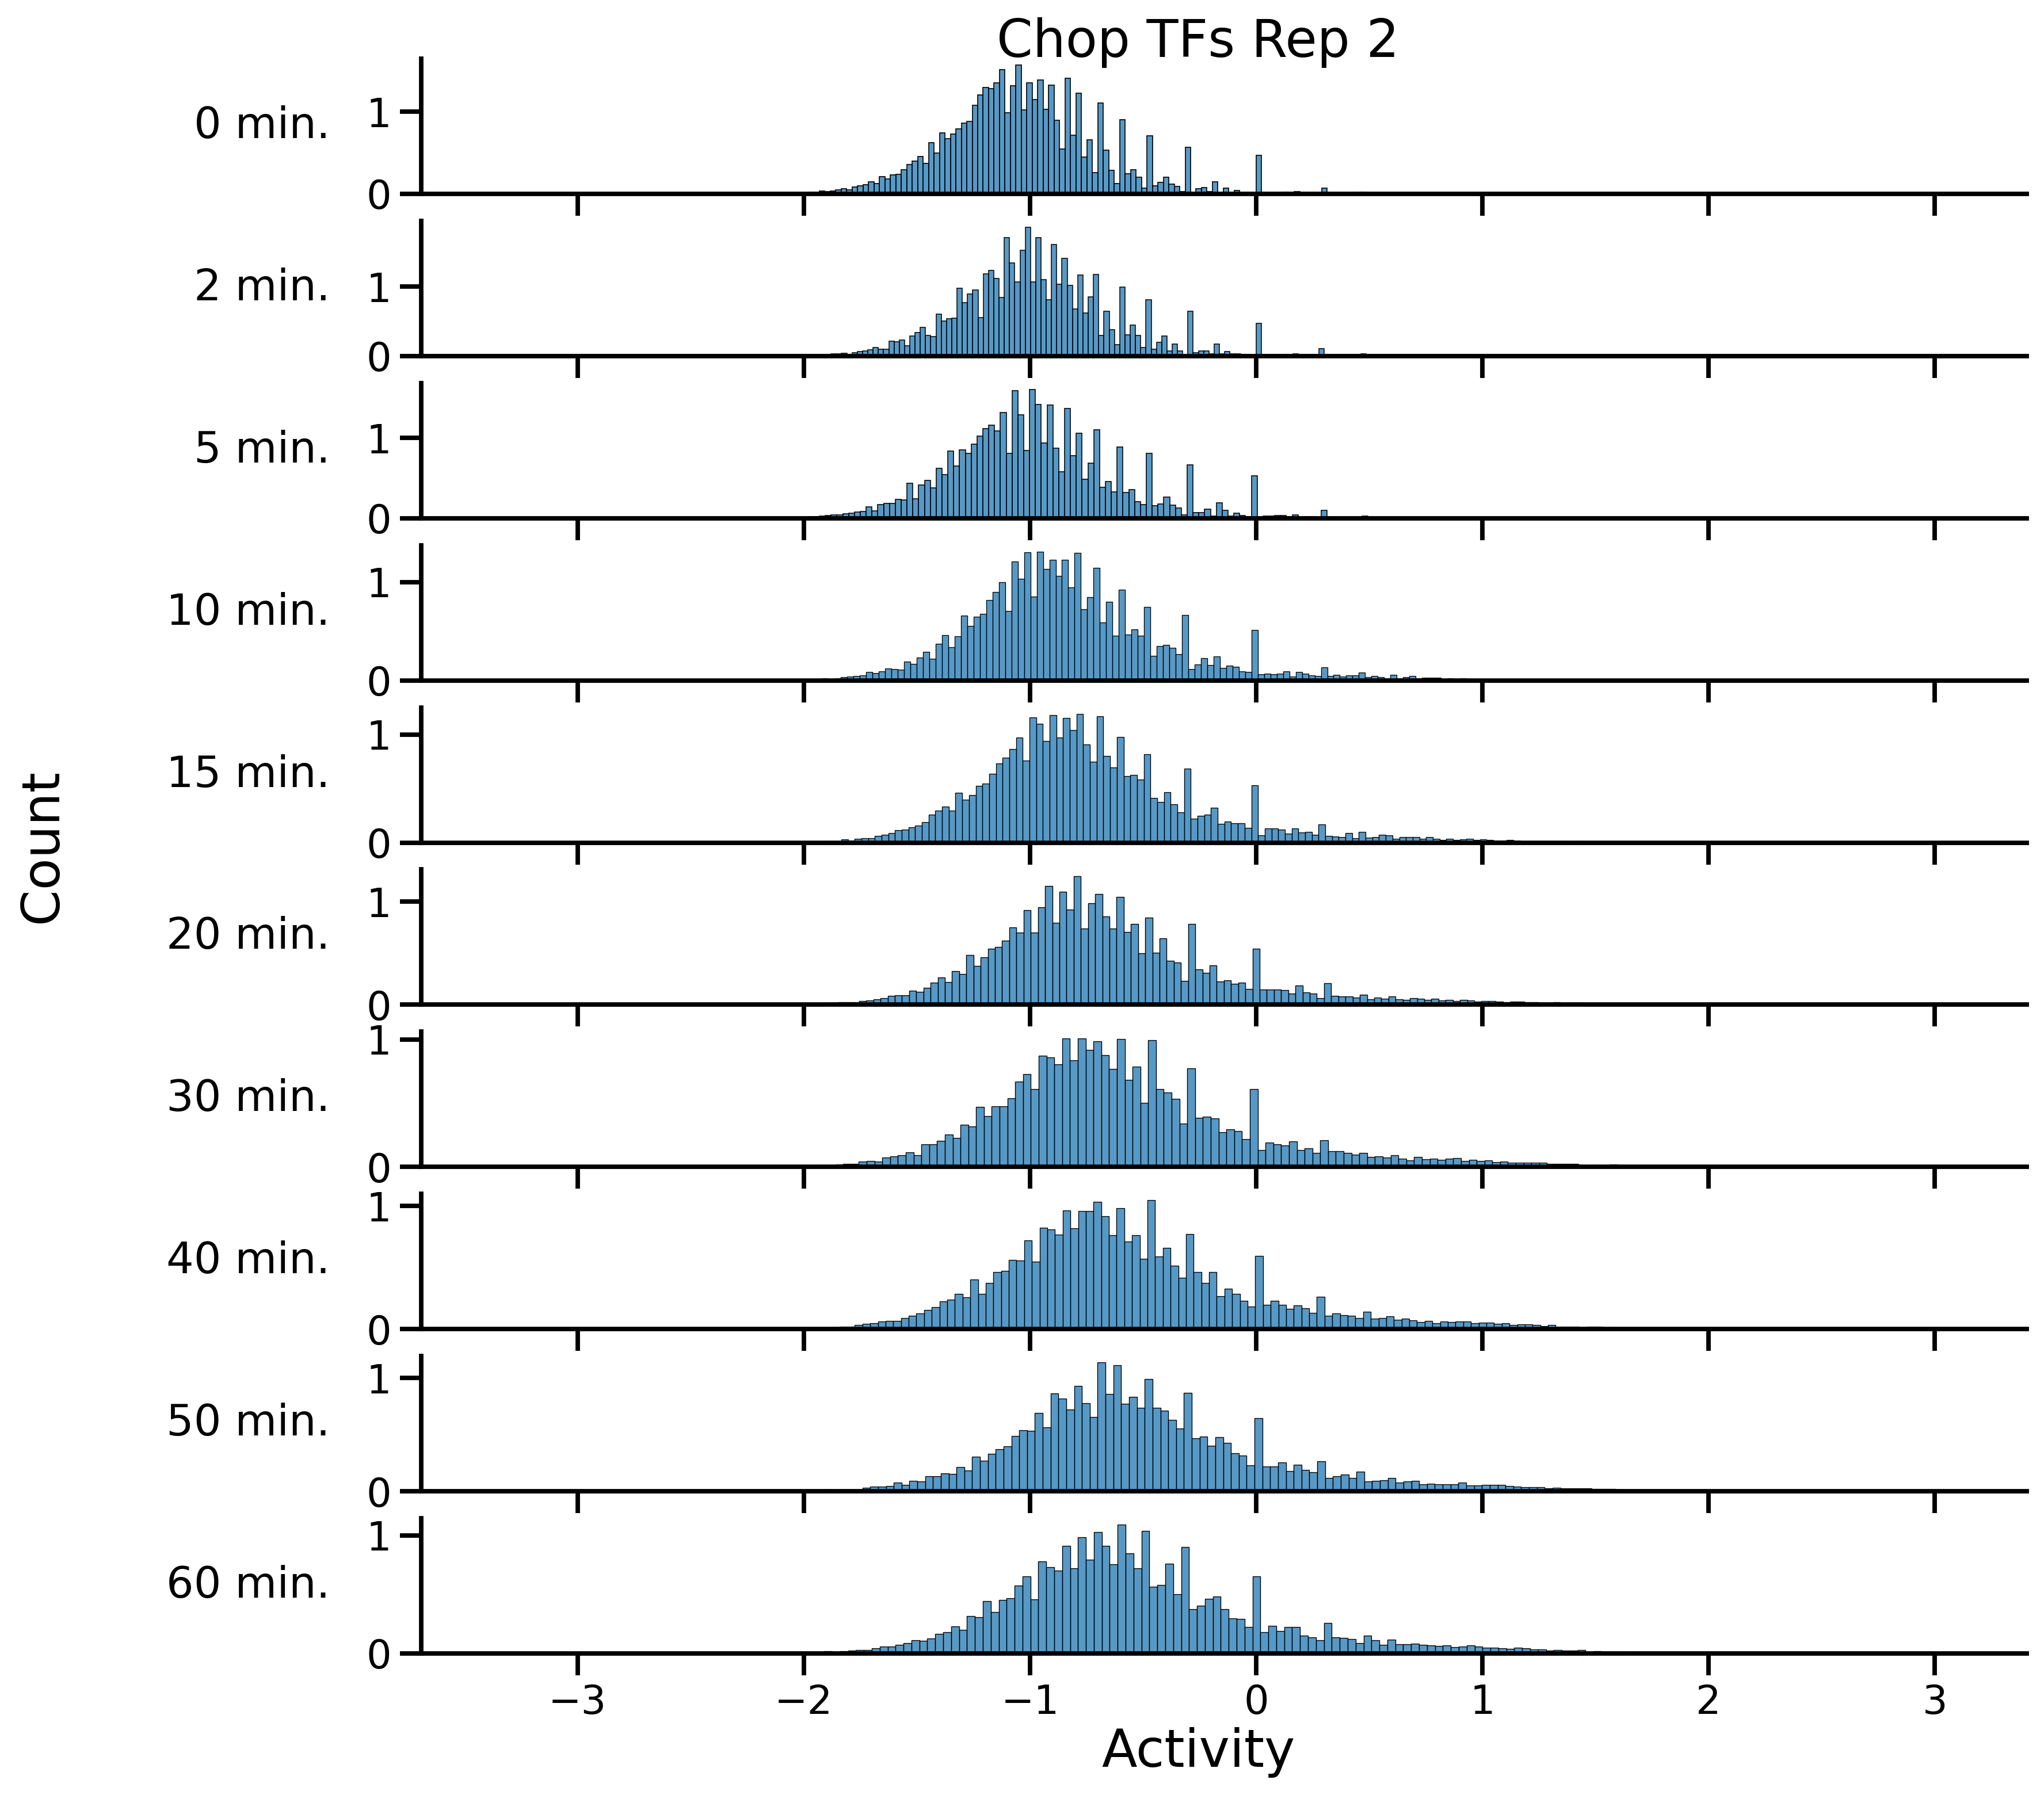

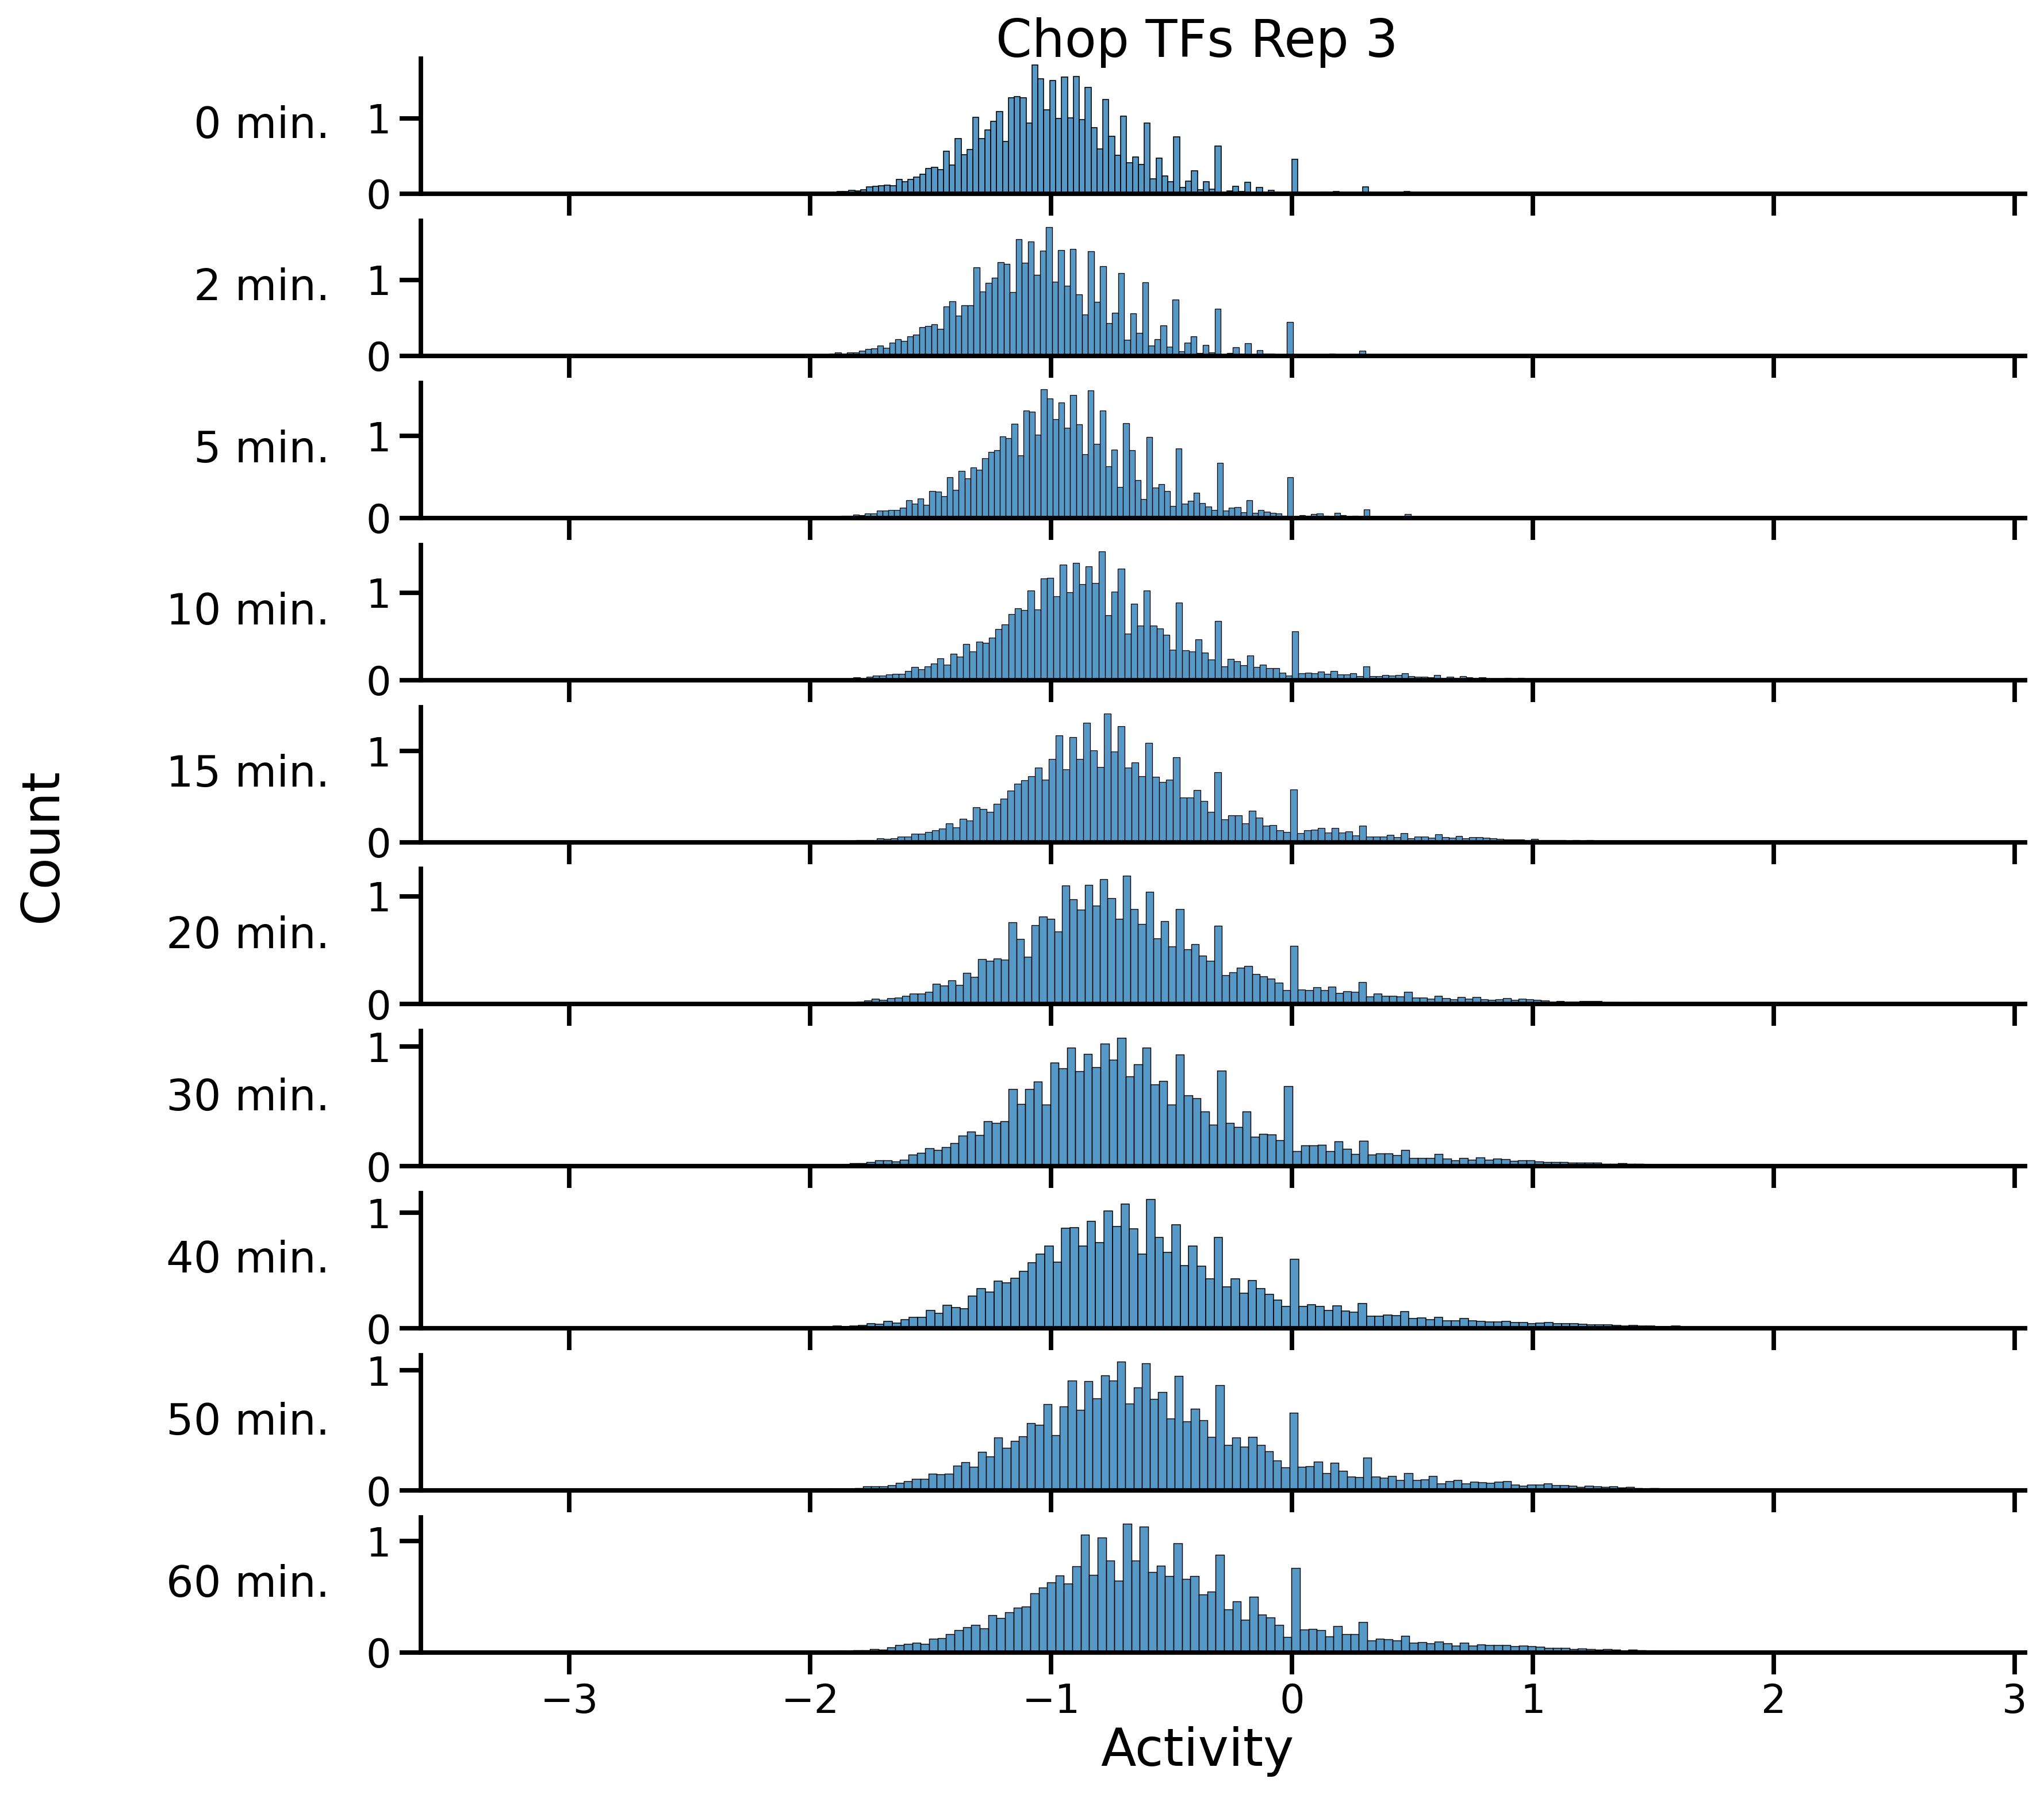

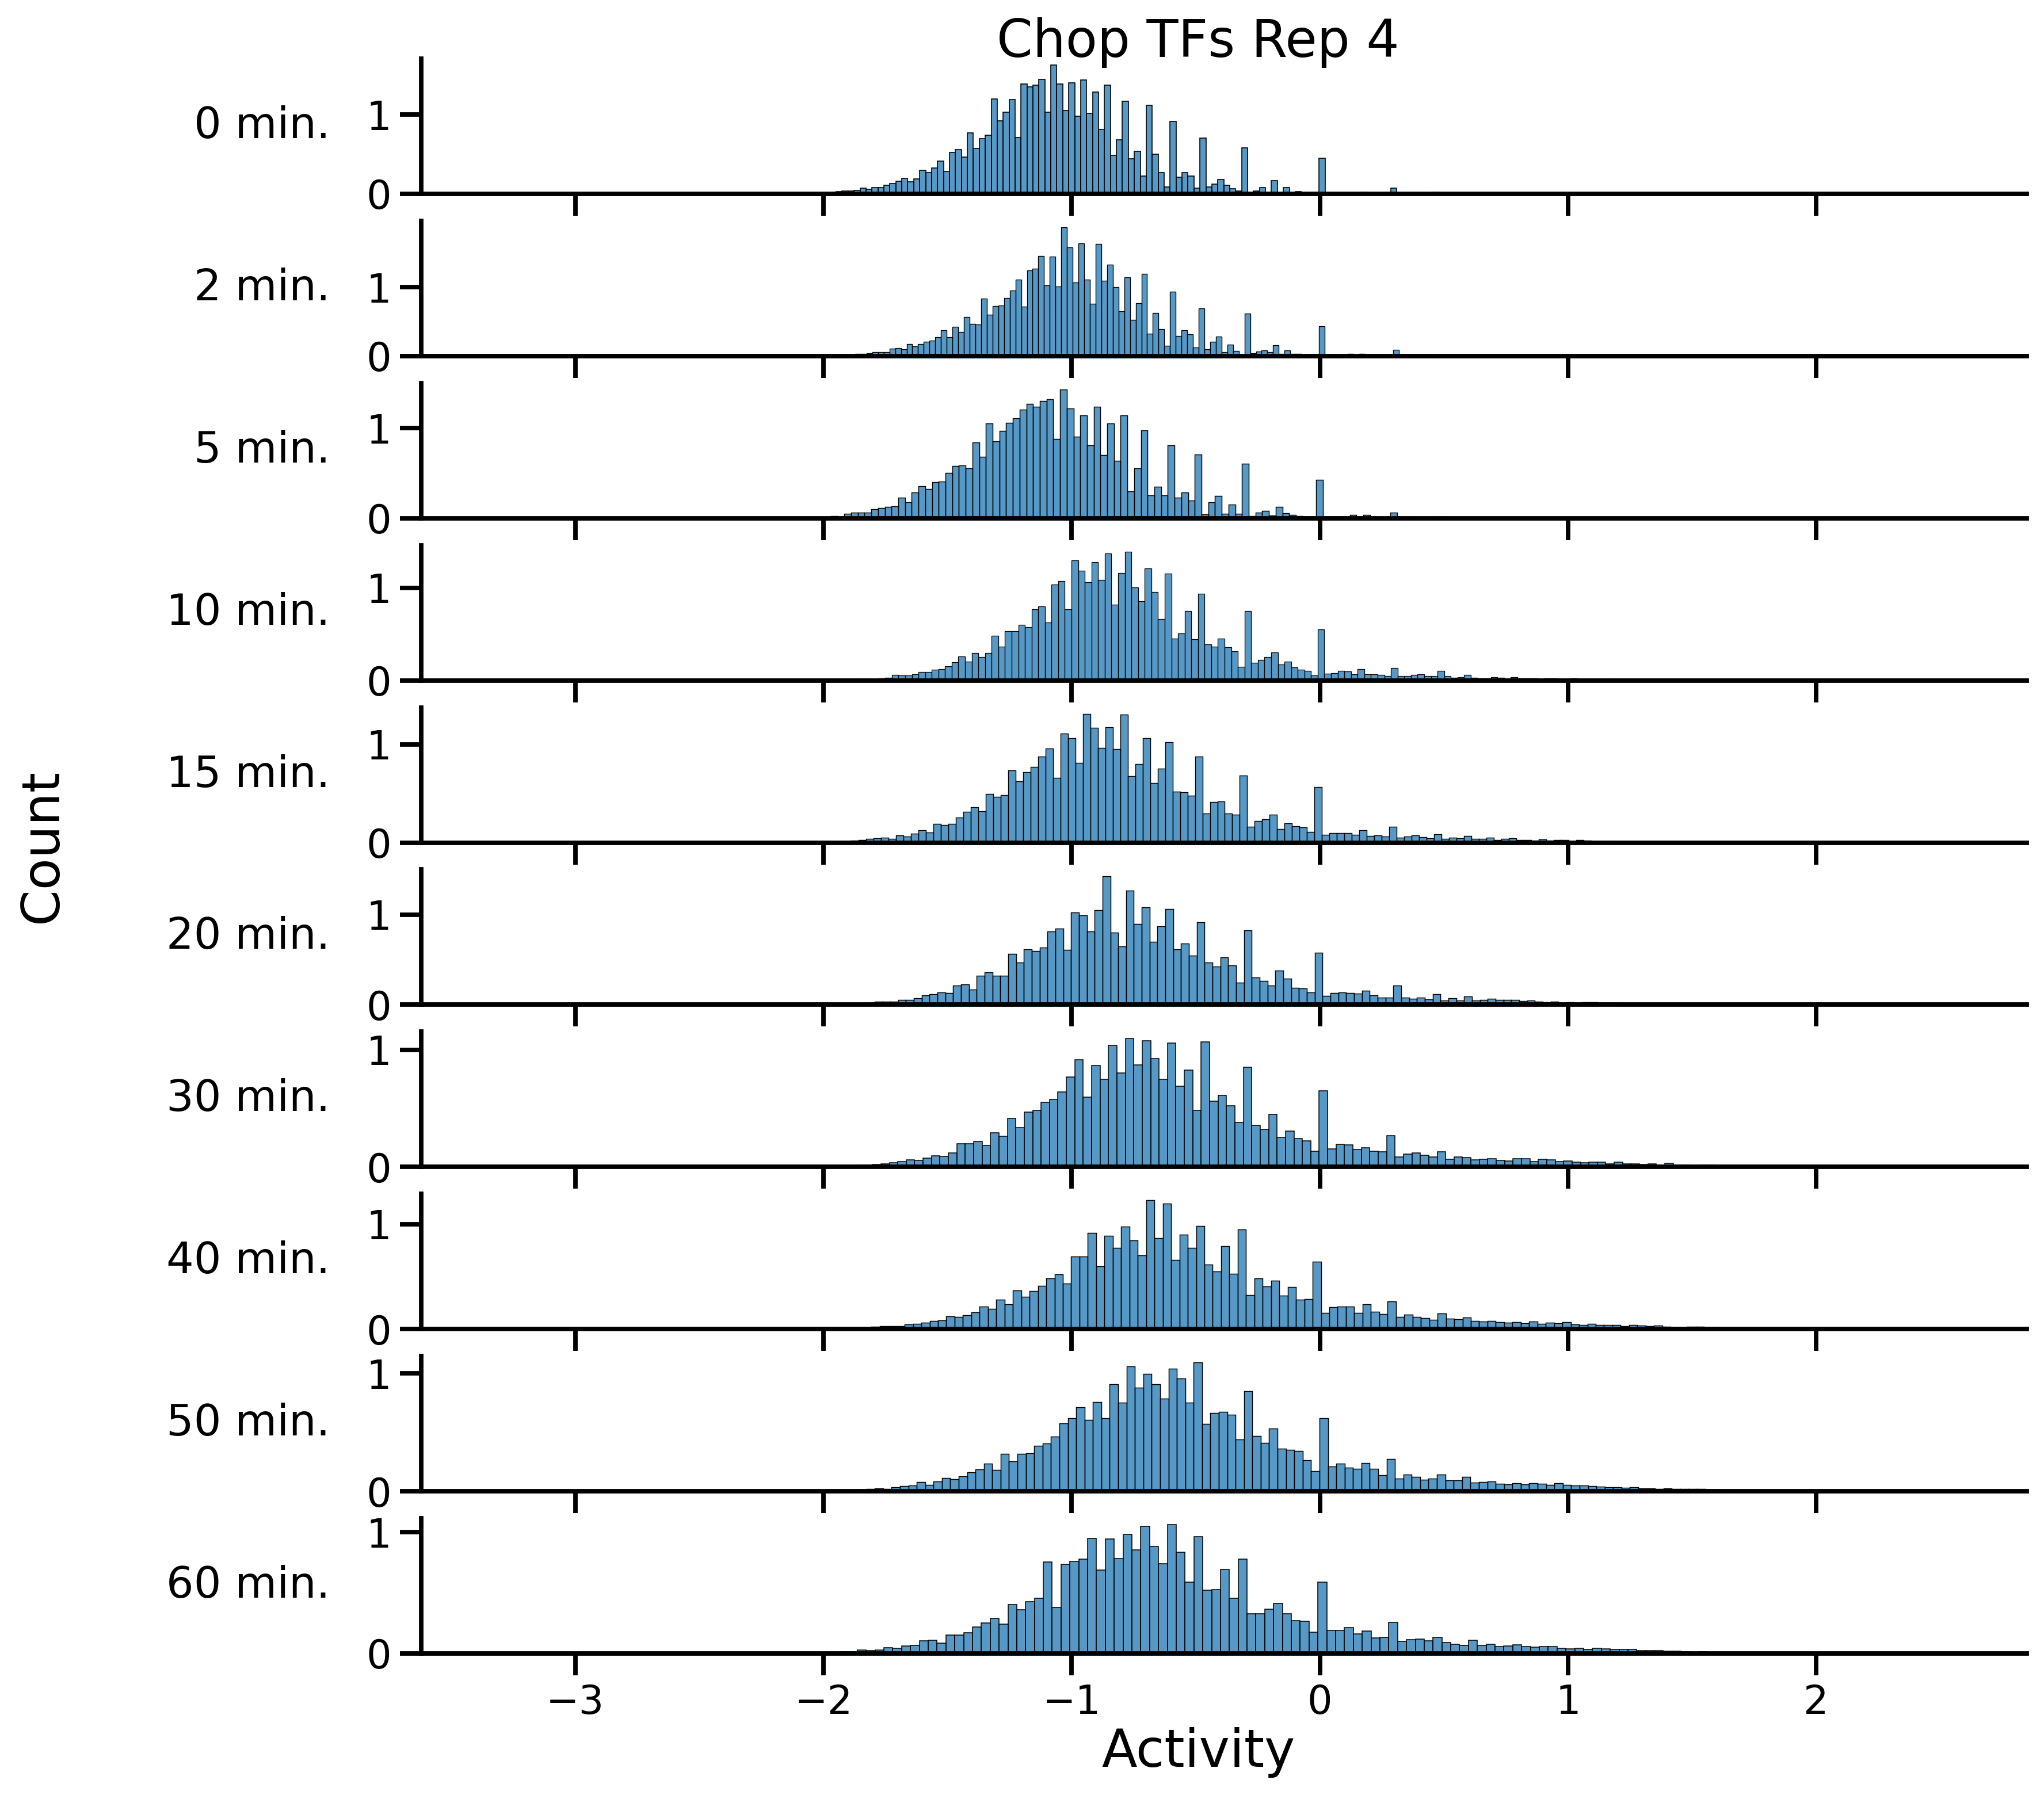

In [6]:
for rep in [2,3,4]:
    fig,axs = time_normalization_helpers.plot_hists_over_time(activities[activities["rep"] == rep])
    fig.suptitle(f"Chop TFs Rep {rep}", y = 0.9)

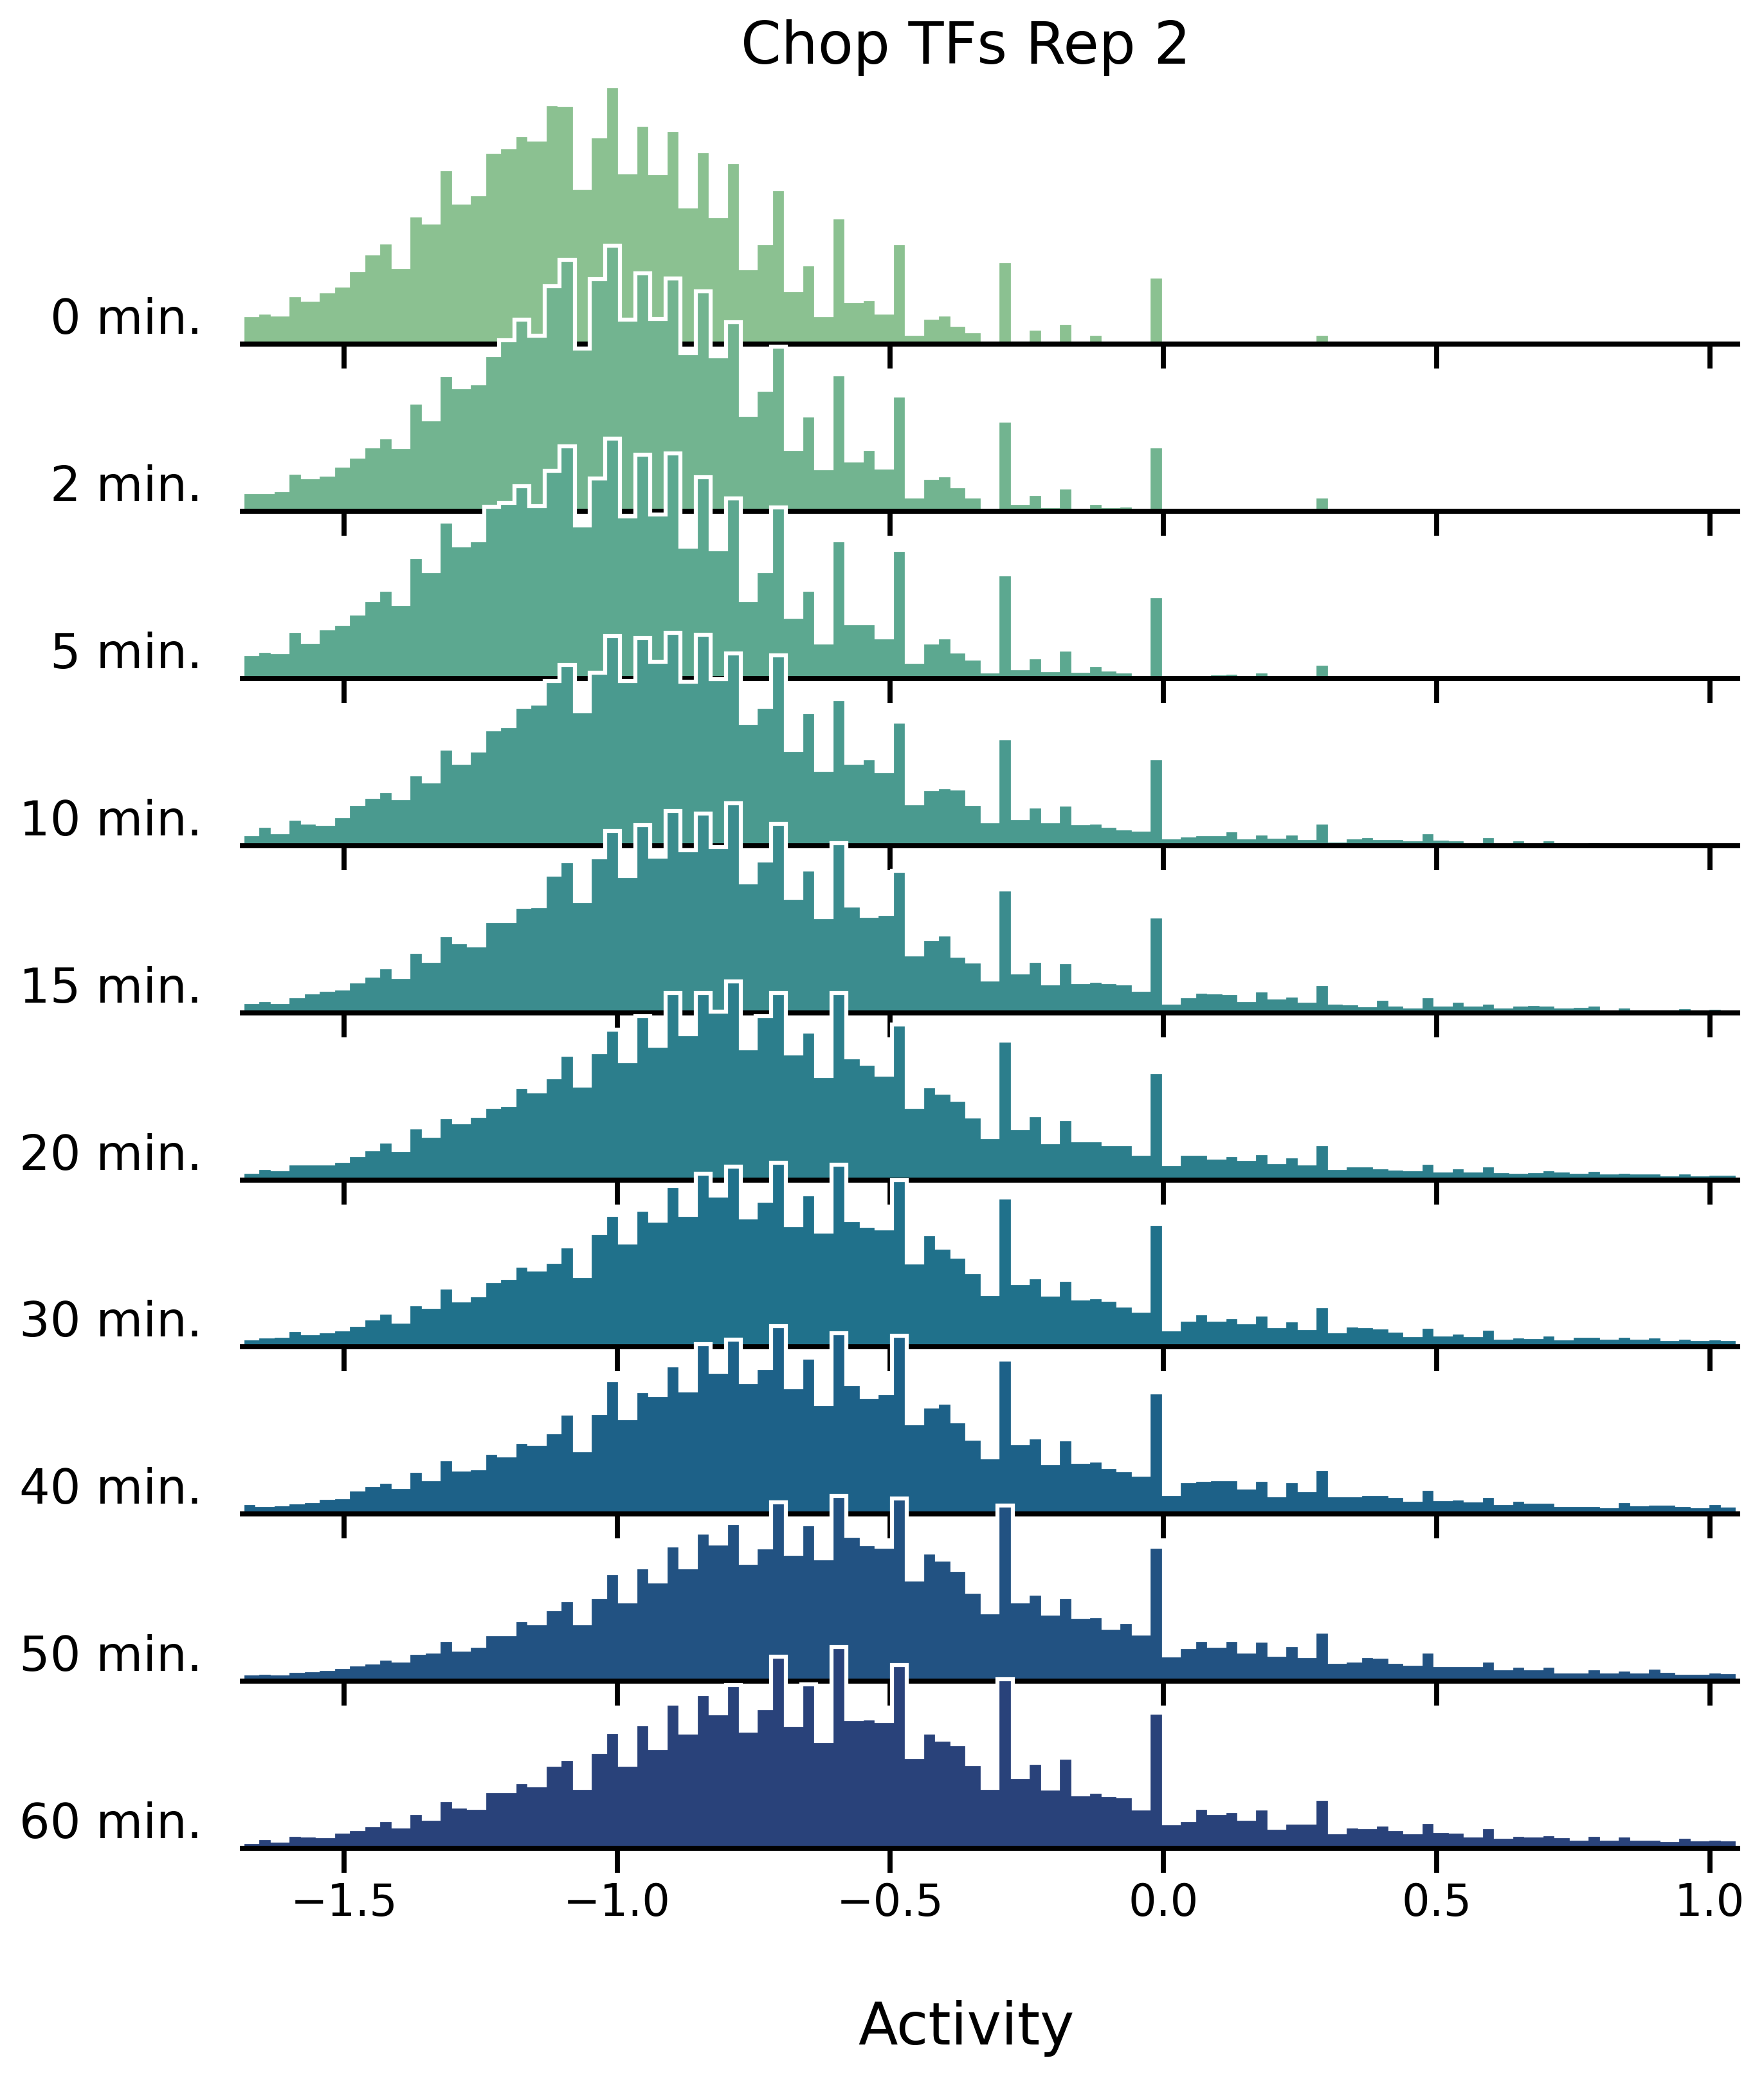

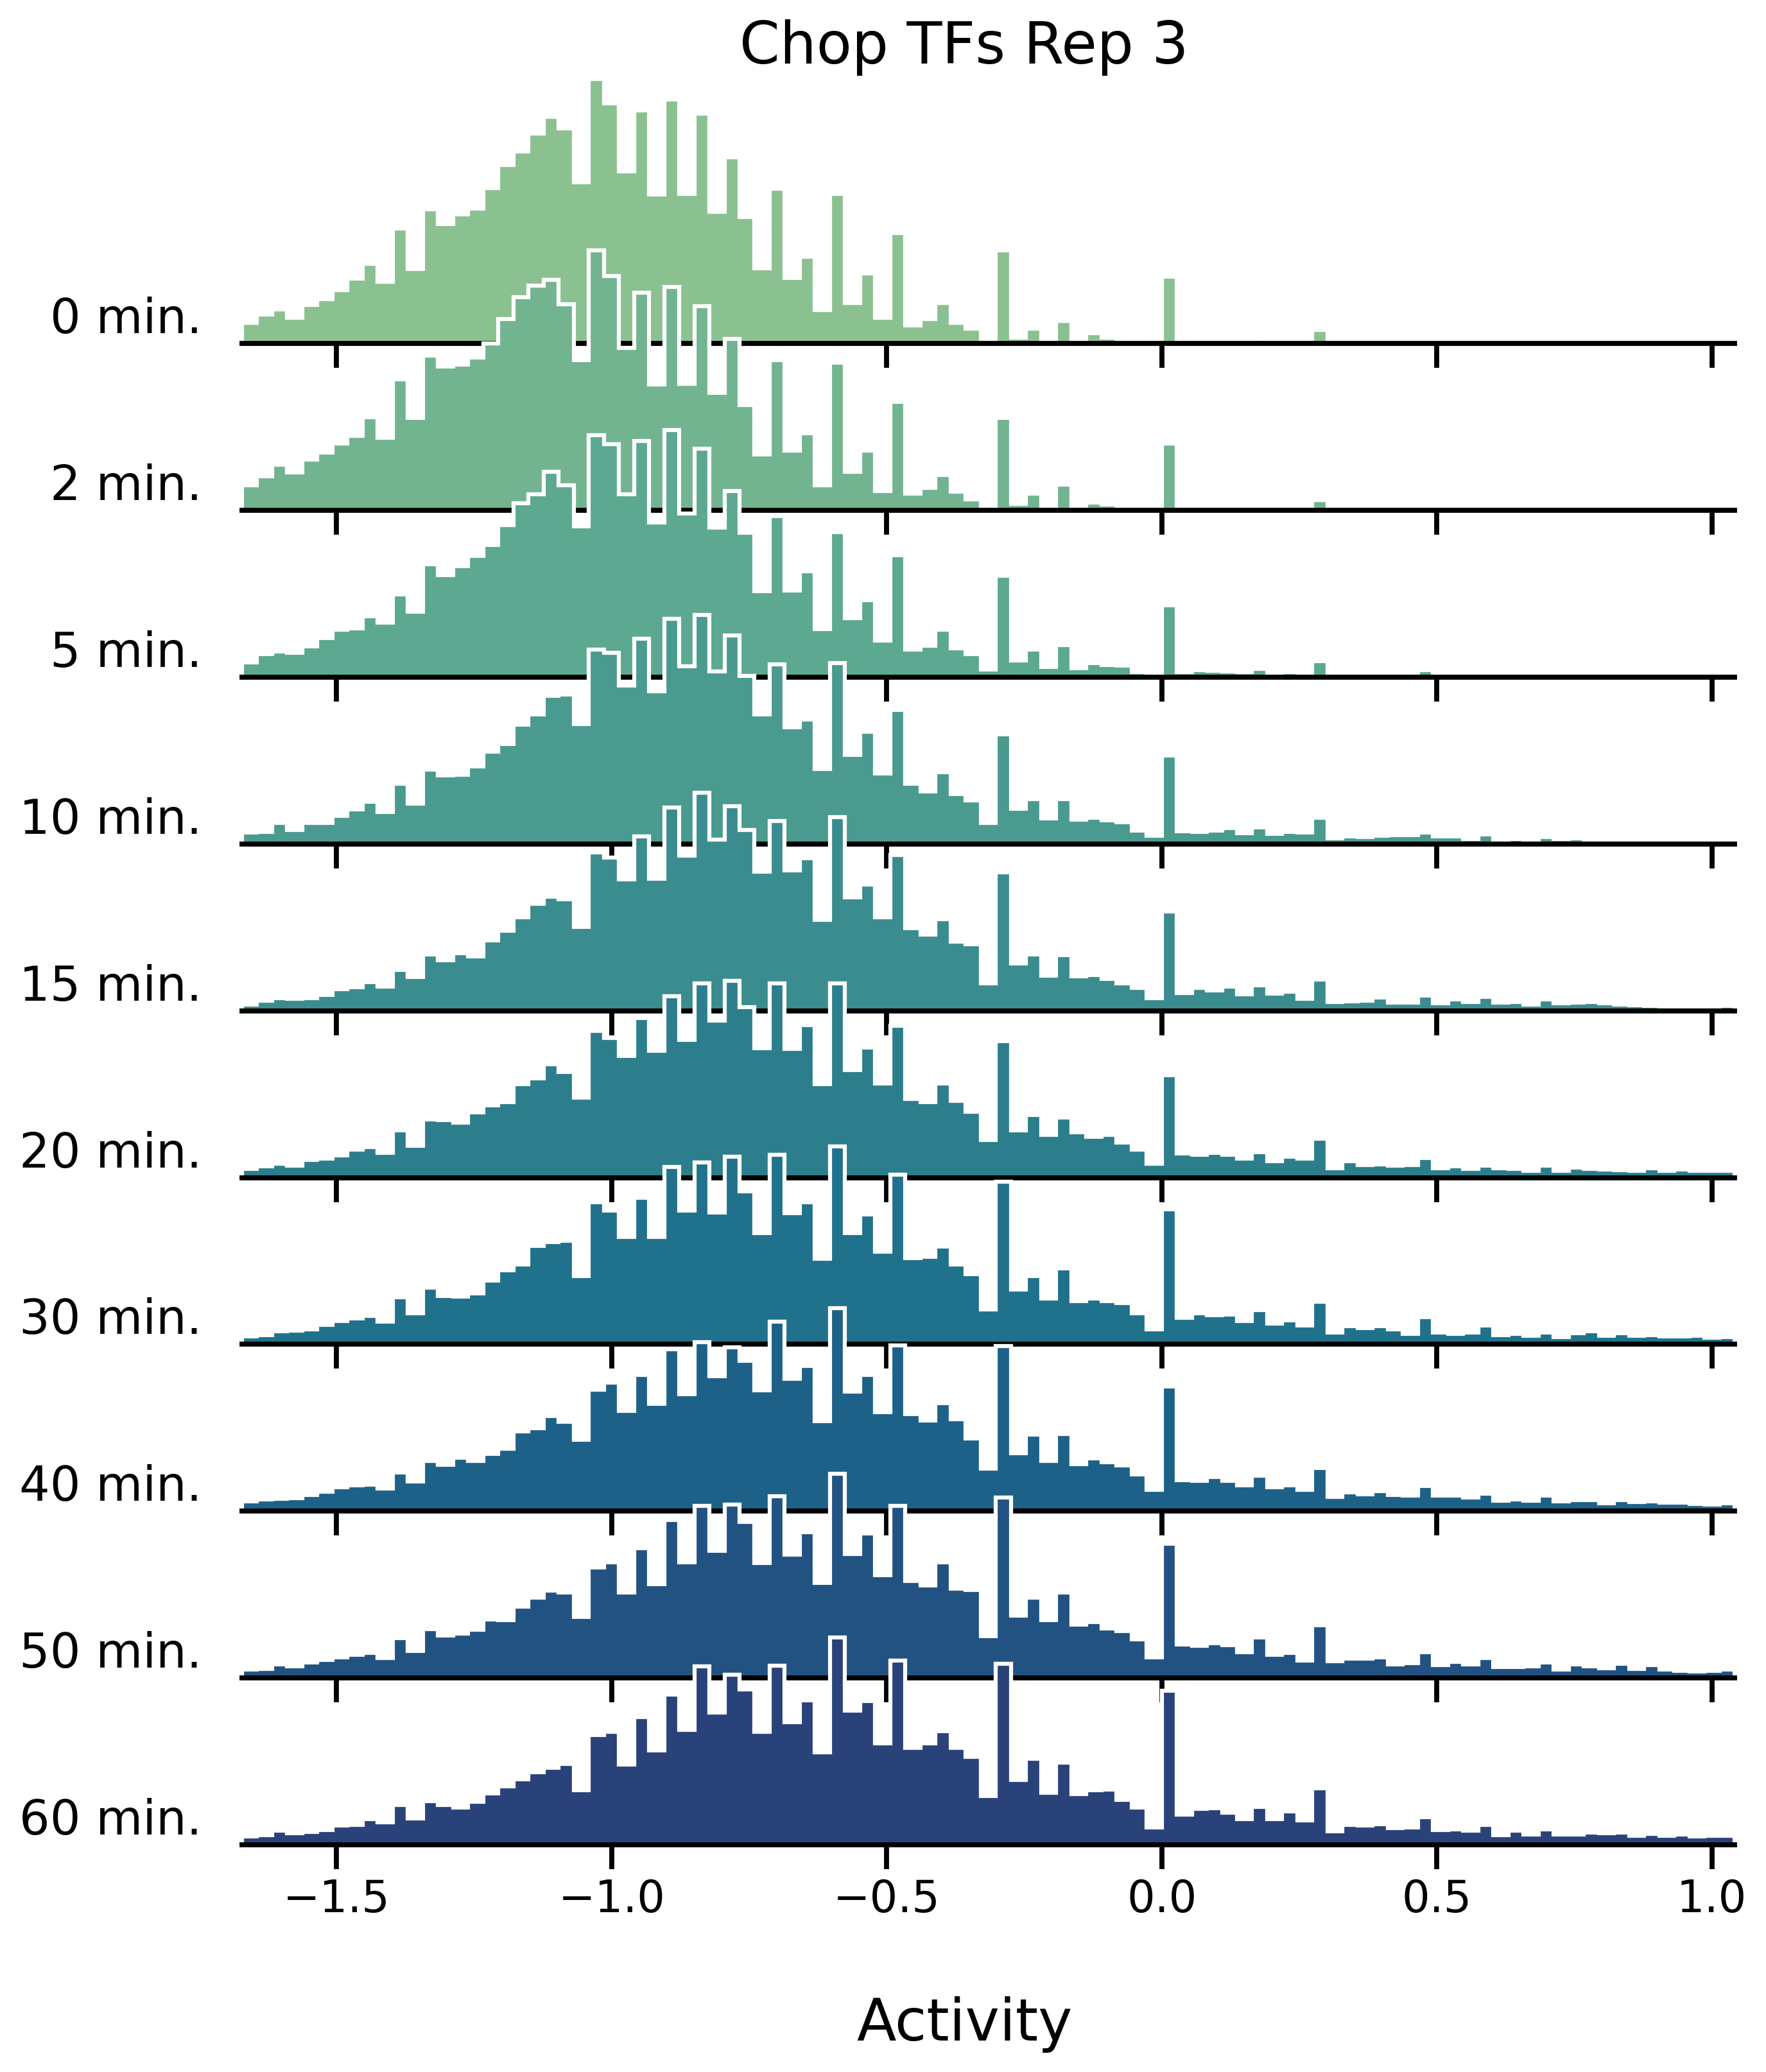

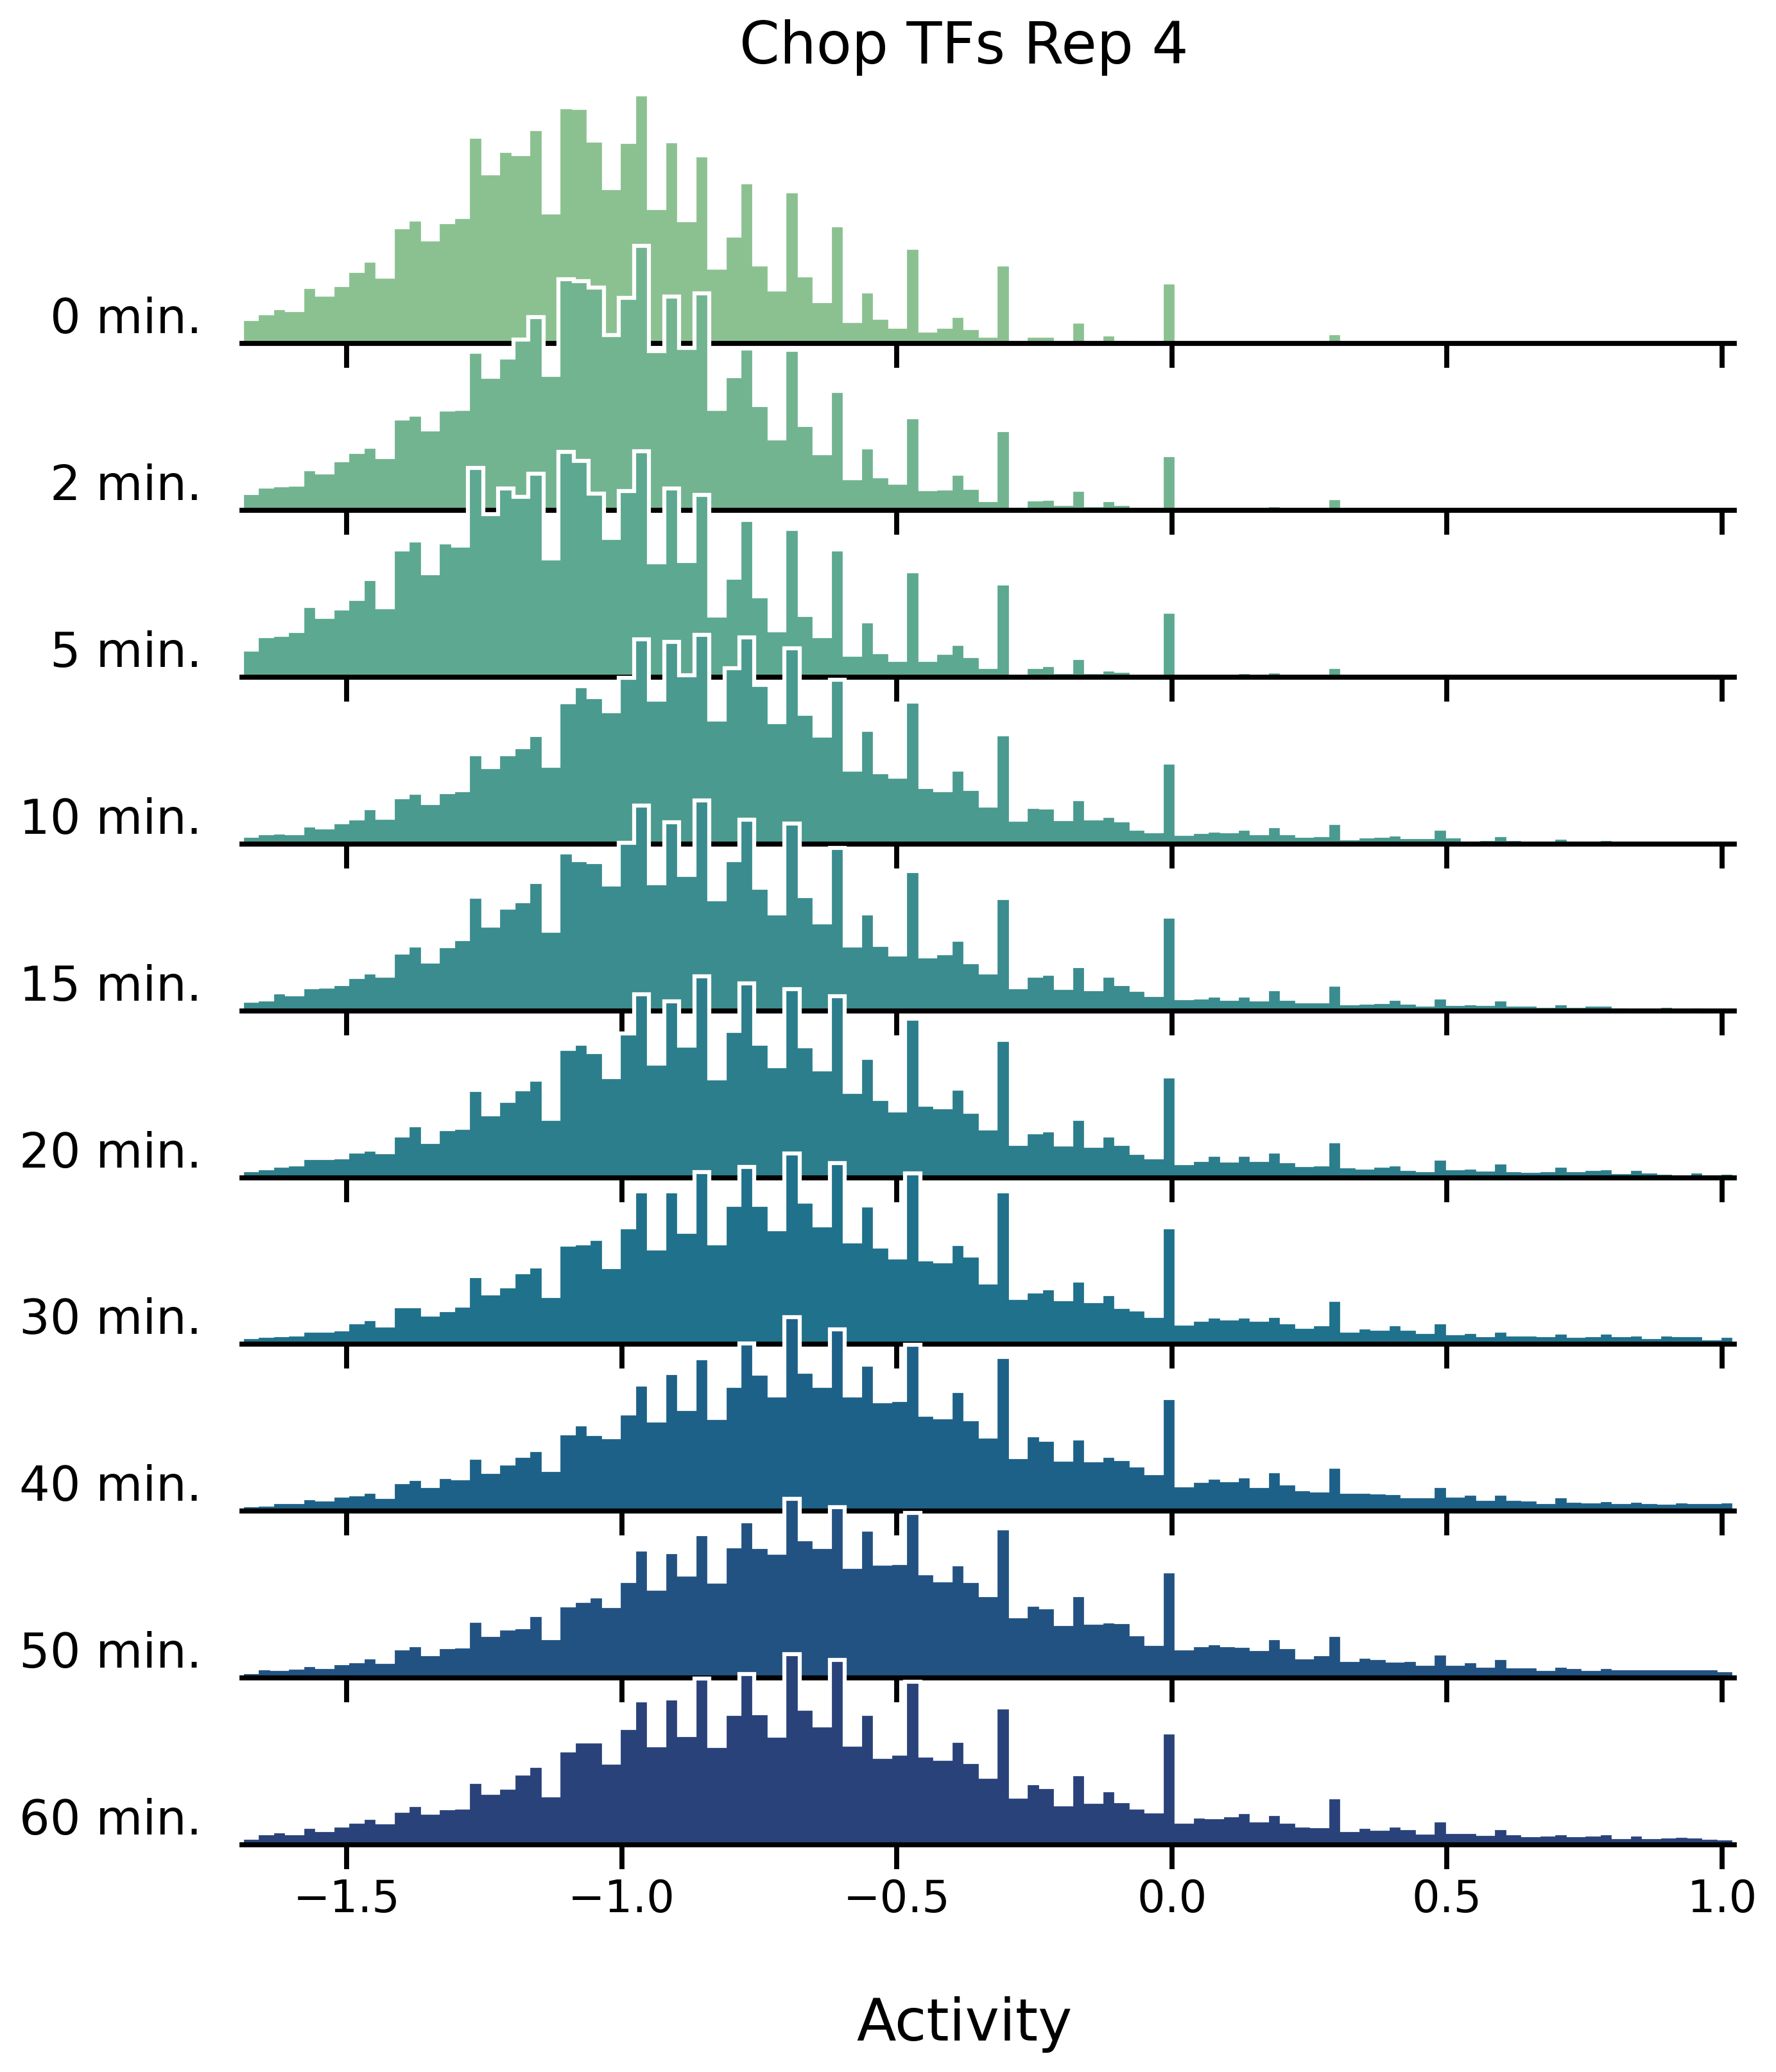

In [8]:
for rep in [2,3,4]:
    fig,axs = time_normalization_helpers.plot_ridge(activities[activities["rep"] == rep])
    fig.suptitle(f"Chop TFs Rep {rep}", y = 0.9)

# Where do negatives lie

In [9]:
activities

,AD,AD_end,AD_BC,RPTR_BC,count_simple_AD,count_directional_AD,rep,time,count_simple_RT,count_directional_RT,activity_simple,activity_directional,AD_protein
0,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,177.0,175.0,2,0,11.0,11.0,-1.206581,-1.201645,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
1,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,186.0,182.0,2,2,14.0,14.0,-1.123385,-1.113943,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
2,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,166.0,164.0,2,5,10.0,8.0,-1.220108,-1.311754,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
3,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,232.0,231.0,2,10,34.0,33.0,-0.834009,-0.845098,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
4,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,243.0,241.0,2,15,70.0,65.0,-0.540508,-0.569104,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1827292,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,74.0,73.0,4,20,10.0,9.0,-0.869232,-0.909080,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827293,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,87.0,86.0,4,30,16.0,14.0,-0.735399,-0.788370,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827294,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,96.0,95.0,4,40,16.0,16.0,-0.778151,-0.773604,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827295,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,108.0,108.0,4,50,28.0,27.0,-0.586266,-0.602060,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR


In [10]:
negative_controls = pd.read_csv("../../../data/NegControls_Design_AA.csv")
negative_controls

,DNAseq,AAseq
0,GATGCTTTGTCTTCTTCTTCTTTGCCATCTACTGCTGTTGCTCAAG...,DALSSSSLPSTAVAQGDIQTTSTADTETKNPAQSDIAEAA
1,TCTTCTTTGCCATCTACTGCTGTTGCTCAAGGTGATATTCAAACTA...,SSLPSTAVAQGDIQTTSTADTETKNPAQSDIAEAARQLLE
2,TTGAATGCTTATAGAGAAAAAGGTGGTTGTGTTTTGTTGATTCATA...,LNAYREKGGCVLLIHRDTKQVVEYLLQDKTRPAYREDIED
3,GCTTTGCATAATACTTTGTTTCAATTGACTGGTTTGCCACATTCTT...,ALHNTLFQLTGLPHSYSAVETDQAEPTVRELTRRADFGGA
4,GCTCCAGCTCCACAACCATCTCCAGTTCAAAAACCAGTTGAAACTG...,APAPQPSPVQKPVETEVAVTTTSSSSRRKSGGSPASGRHS
...,...,...
198,GAATTGGCTGCTCCAACTCAACAACAACAATCTCCAGCTGCTGGTT...,ELAAPTQQQQSPAAGSEDLEAAPSPAPRRKSGNSPTSSTG
199,GCTGCTTTGGATGTTGCTTTGGCTTTGTCTCAACCAGAAACTAAAC...,AALDVALALSQPETKPAKEVSVPPSPAIRNSASPAPSPAP
200,GATGATGCTGTTGTTGAATCTGCTGCTTCTTCTTCTACTGATTCTA...,DDAVVESAASSSTDSTPAAEAENAEDNSKEATSAADNDIP
201,GATGATGCTGTTGTTGAATCTGCTGCTTCTTCTTCTACTGATTCTA...,DDAVVESAASSSTDSTPMAEAENLEDNSKEATSLADNDIP


In [11]:
activities["neg_ctrl"] = activities["AD_protein"].isin(negative_controls["AAseq"])
activities

,AD,AD_end,AD_BC,RPTR_BC,count_simple_AD,count_directional_AD,rep,time,count_simple_RT,count_directional_RT,activity_simple,activity_directional,AD_protein,neg_ctrl
0,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,177.0,175.0,2,0,11.0,11.0,-1.206581,-1.201645,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,False
1,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,186.0,182.0,2,2,14.0,14.0,-1.123385,-1.113943,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,False
2,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,166.0,164.0,2,5,10.0,8.0,-1.220108,-1.311754,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,False
3,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,232.0,231.0,2,10,34.0,33.0,-0.834009,-0.845098,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,False
4,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,243.0,241.0,2,15,70.0,65.0,-0.540508,-0.569104,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1827292,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,74.0,73.0,4,20,10.0,9.0,-0.869232,-0.909080,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,False
1827293,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,87.0,86.0,4,30,16.0,14.0,-0.735399,-0.788370,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,False
1827294,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,96.0,95.0,4,40,16.0,16.0,-0.778151,-0.773604,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,False
1827295,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,108.0,108.0,4,50,28.0,27.0,-0.586266,-0.602060,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,False


In [12]:
neg_ctrl_ads = activities[activities["neg_ctrl"]]["AD_protein"].unique()
neg_ctrl_ads

array(['PPTDVSAGDEAHADGEDVAMAHADAADDFDADMAGDGDSP',
       'DDAVVESAASSSTDSTPMAEAENLEDNSKEATSLADNDIP',
       'DDAVVESAASSSTDSTPAAEAENAEDNSKEATSAADNDIP',
       'DVTPASPMIRTTSSRATSPSARSVTKPSHVAGVNARQRKP'], dtype=object)

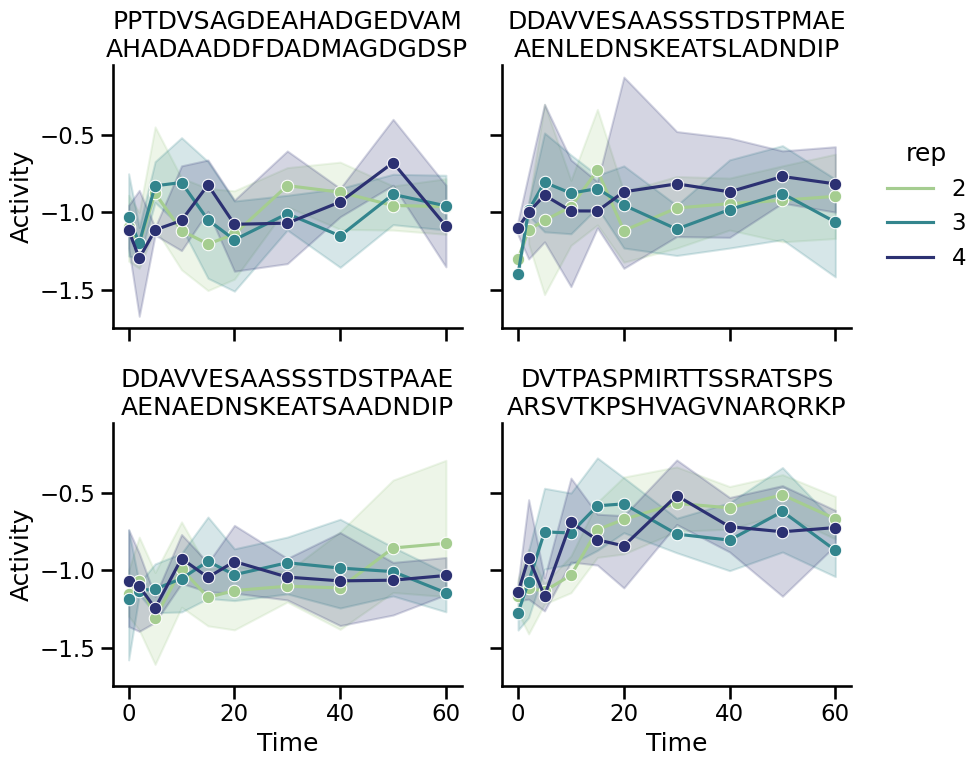

In [13]:
sns.set_context('talk')

neg_ctrl_ads = [
    "PPTDVSAGDEAHADGEDVAMAHADAADDFDADMAGDGDSP",
    "DDAVVESAASSSTDSTPMAEAENLEDNSKEATSLADNDIP",
    "DDAVVESAASSSTDSTPAAEAENAEDNSKEATSAADNDIP",
    "DVTPASPMIRTTSSRATSPSARSVTKPSHVAGVNARQRKP"
]

df = activities[activities["AD_protein"].isin(neg_ctrl_ads)]


g = sns.relplot(
    data=df,
    x="time",
    y="activity_directional",
    hue="rep",
    col="AD_protein",
    kind="line",
    marker="o",
    col_wrap=2,
    height=4,
    palette = 'crest'
)

for ax in g.axes.flat:
    title = ax.get_title().replace("AD_protein = ", "")
    ax.set_title("\n".join(textwrap.wrap(title, 20)))

plt.tight_layout()
g._legend.set_bbox_to_anchor((1.1, 0.7))

g.set_axis_labels("Time", "Activity")
sns.despine()

# Z-score normalization

In [14]:
activities = pd.read_csv("../../../output/ChopTFs_pipeline/trebl_experiment_activities_per_barcode.csv", index_col = 0)
activities

,AD,AD_end,AD_BC,RPTR_BC,count_simple_AD,count_directional_AD,rep,time,count_simple_RT,count_directional_RT,activity_simple,activity_directional,AD_protein
0,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,177.0,175.0,2,0,11.0,11.0,-1.206581,-1.201645,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
1,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,186.0,182.0,2,2,14.0,14.0,-1.123385,-1.113943,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
2,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,166.0,164.0,2,5,10.0,8.0,-1.220108,-1.311754,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
3,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,232.0,231.0,2,10,34.0,33.0,-0.834009,-0.845098,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
4,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,243.0,241.0,2,15,70.0,65.0,-0.540508,-0.569104,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1827292,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,74.0,73.0,4,20,10.0,9.0,-0.869232,-0.909080,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827293,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,87.0,86.0,4,30,16.0,14.0,-0.735399,-0.788370,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827294,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,96.0,95.0,4,40,16.0,16.0,-0.778151,-0.773604,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827295,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,108.0,108.0,4,50,28.0,27.0,-0.586266,-0.602060,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR


In [15]:
activities = activities.rename(columns = {"AD_protein" : "seq", "activity_directional" : "score"})
activities = activities[["seq", "AD_BC", "score", "rep", "time"]]
activities

,seq,AD_BC,score,rep,time
0,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,ATAACCAATGG,-1.201645,2,0
1,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,ATAACCAATGG,-1.113943,2,2
2,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,ATAACCAATGG,-1.311754,2,5
3,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,ATAACCAATGG,-0.845098,2,10
4,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,ATAACCAATGG,-0.569104,2,15
...,...,...,...,...,...
1827292,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,TACAACTTTAT,-0.909080,4,20
1827293,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,TACAACTTTAT,-0.788370,4,30
1827294,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,TACAACTTTAT,-0.773604,4,40
1827295,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,TACAACTTTAT,-0.602060,4,50


In [16]:
# Create a dictionary to hold the split dataframes
activities_by_time_rep = {}

# Group by 'time' and 'rep'
for (rep, time), group in activities.groupby(['rep', 'time']):
    activities_by_time_rep[(rep, time)] = group.reset_index(drop=True)

In [27]:
cached_fits = {}

for (rep, time), group in tqdm.tqdm(activities.groupby(['rep', 'time'])):
    mu, sigma, truncated, df_out = time_normalization_helpers.fit_inactive_gaussian_progressive_fast(group)
    cached_fits[(rep, time)] = (mu, sigma, truncated, df_out)

100%|██████████| 30/30 [00:17<00:00,  1.71it/s]


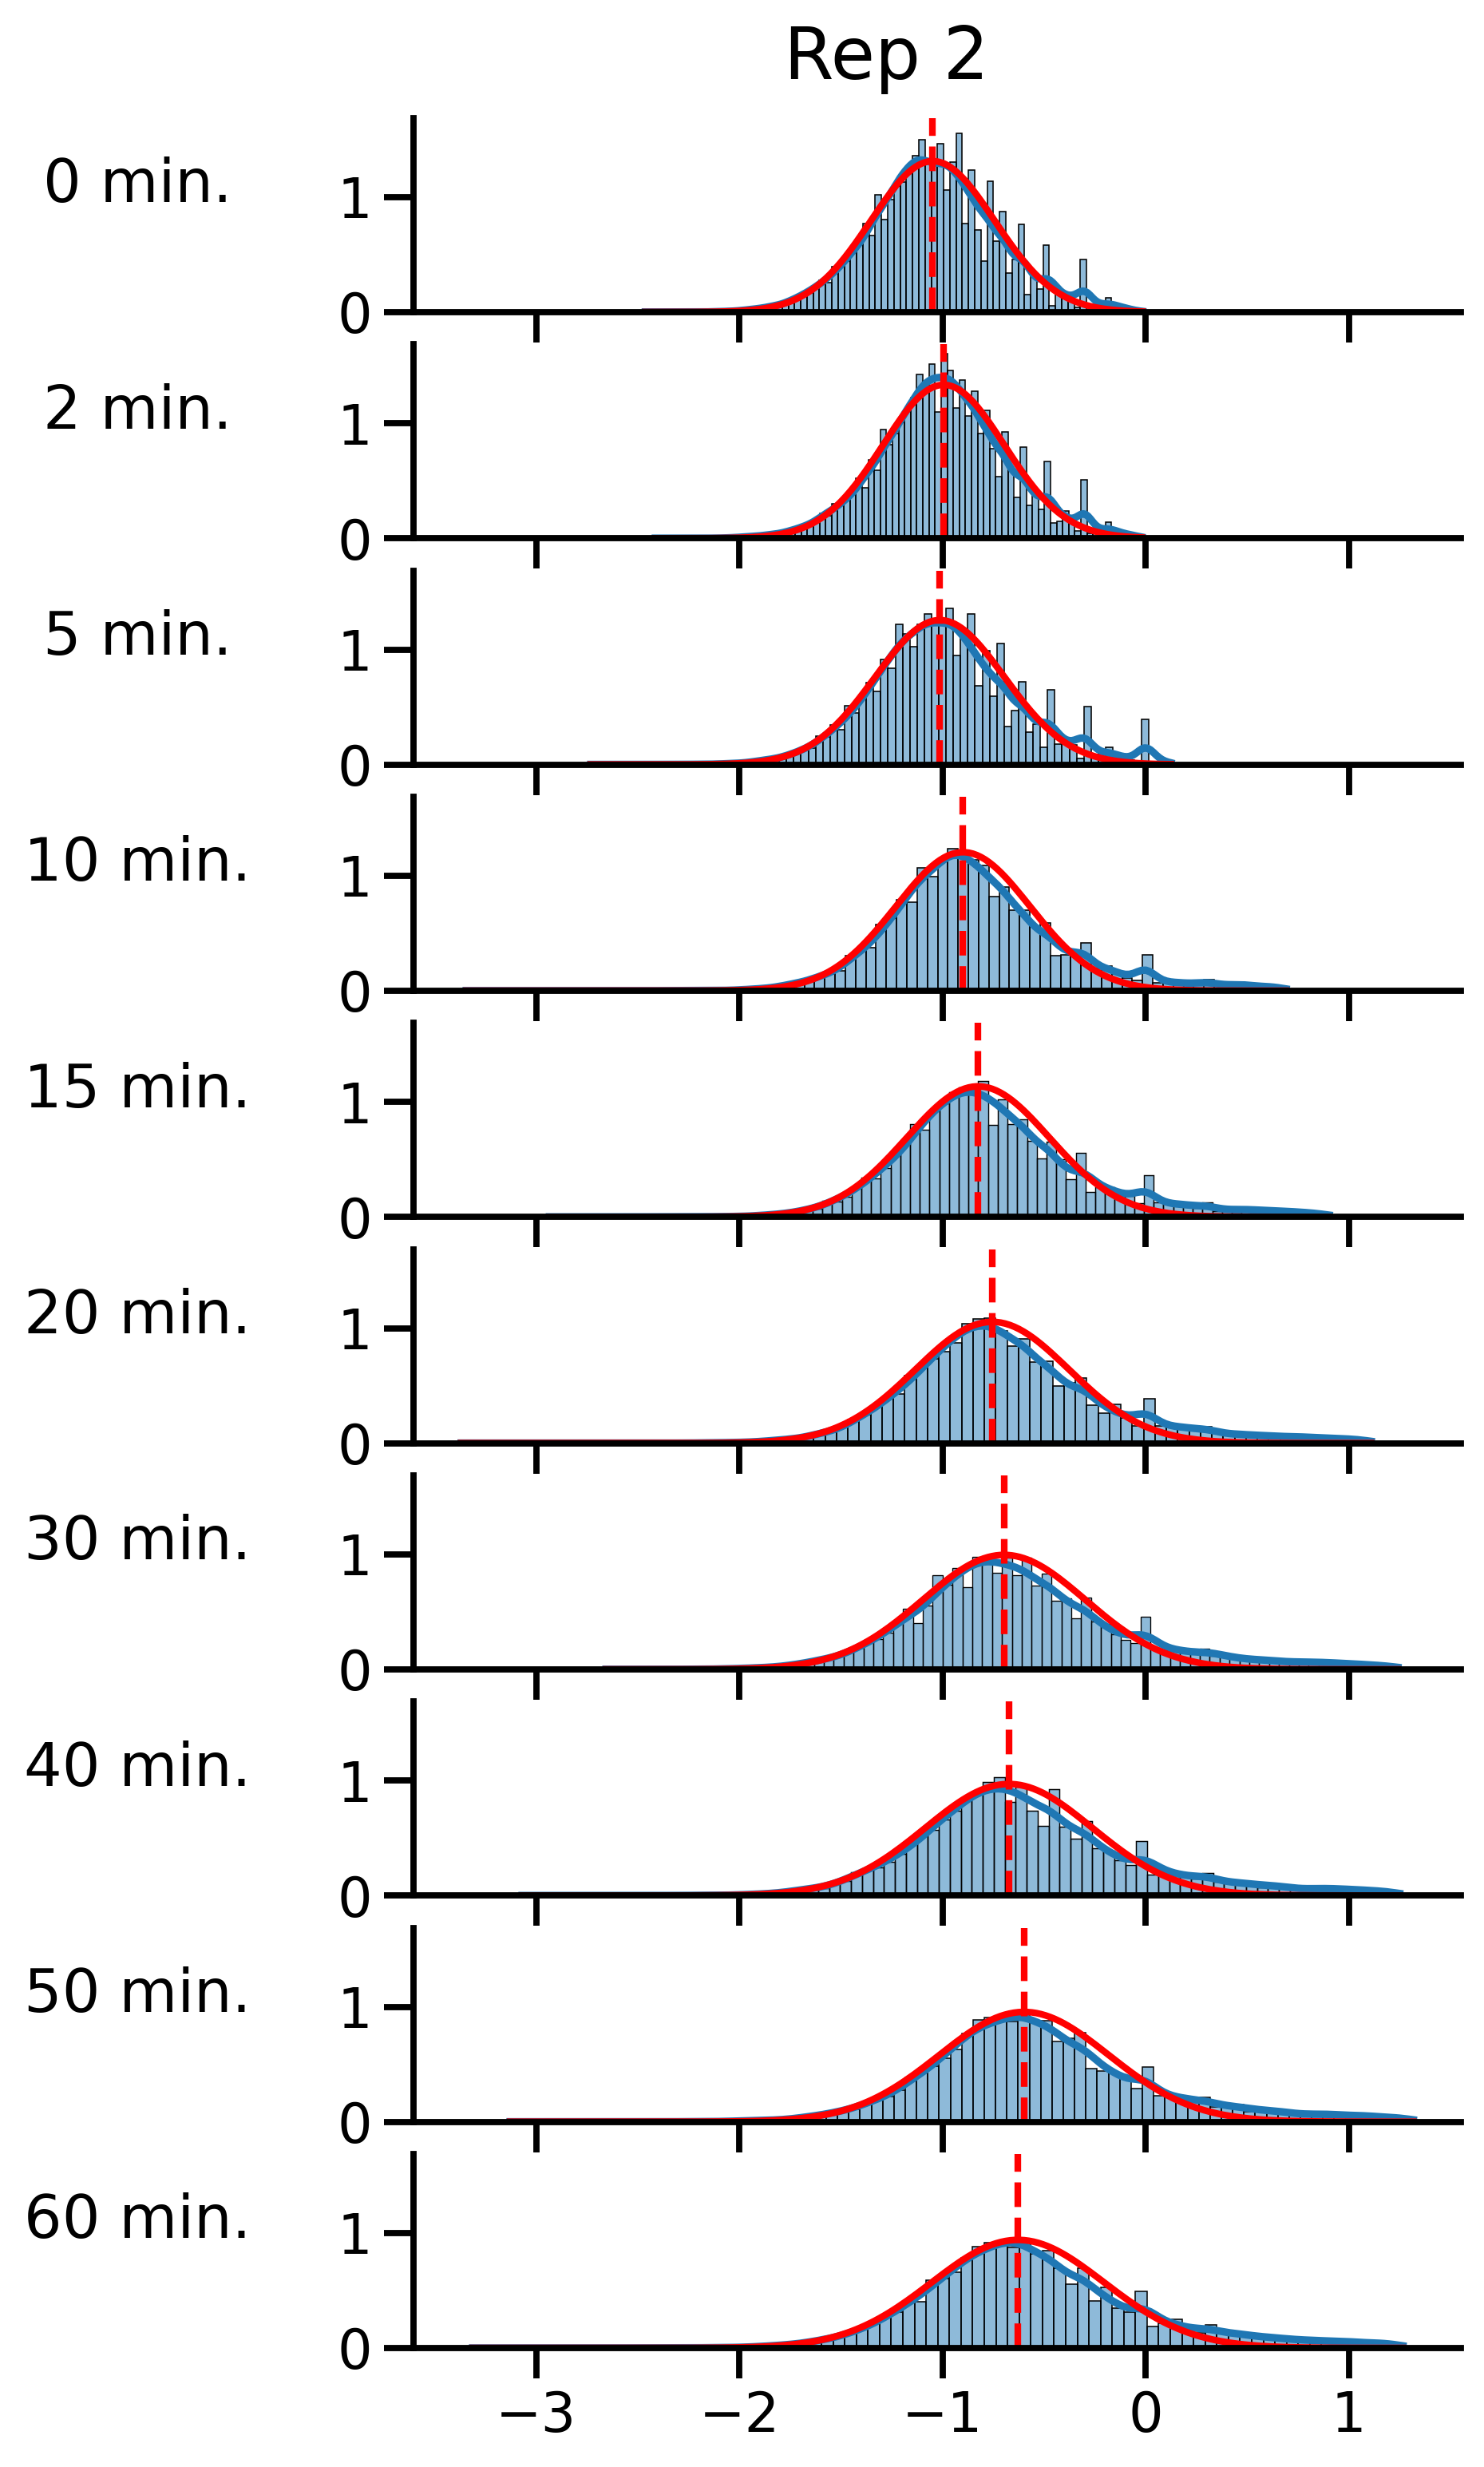

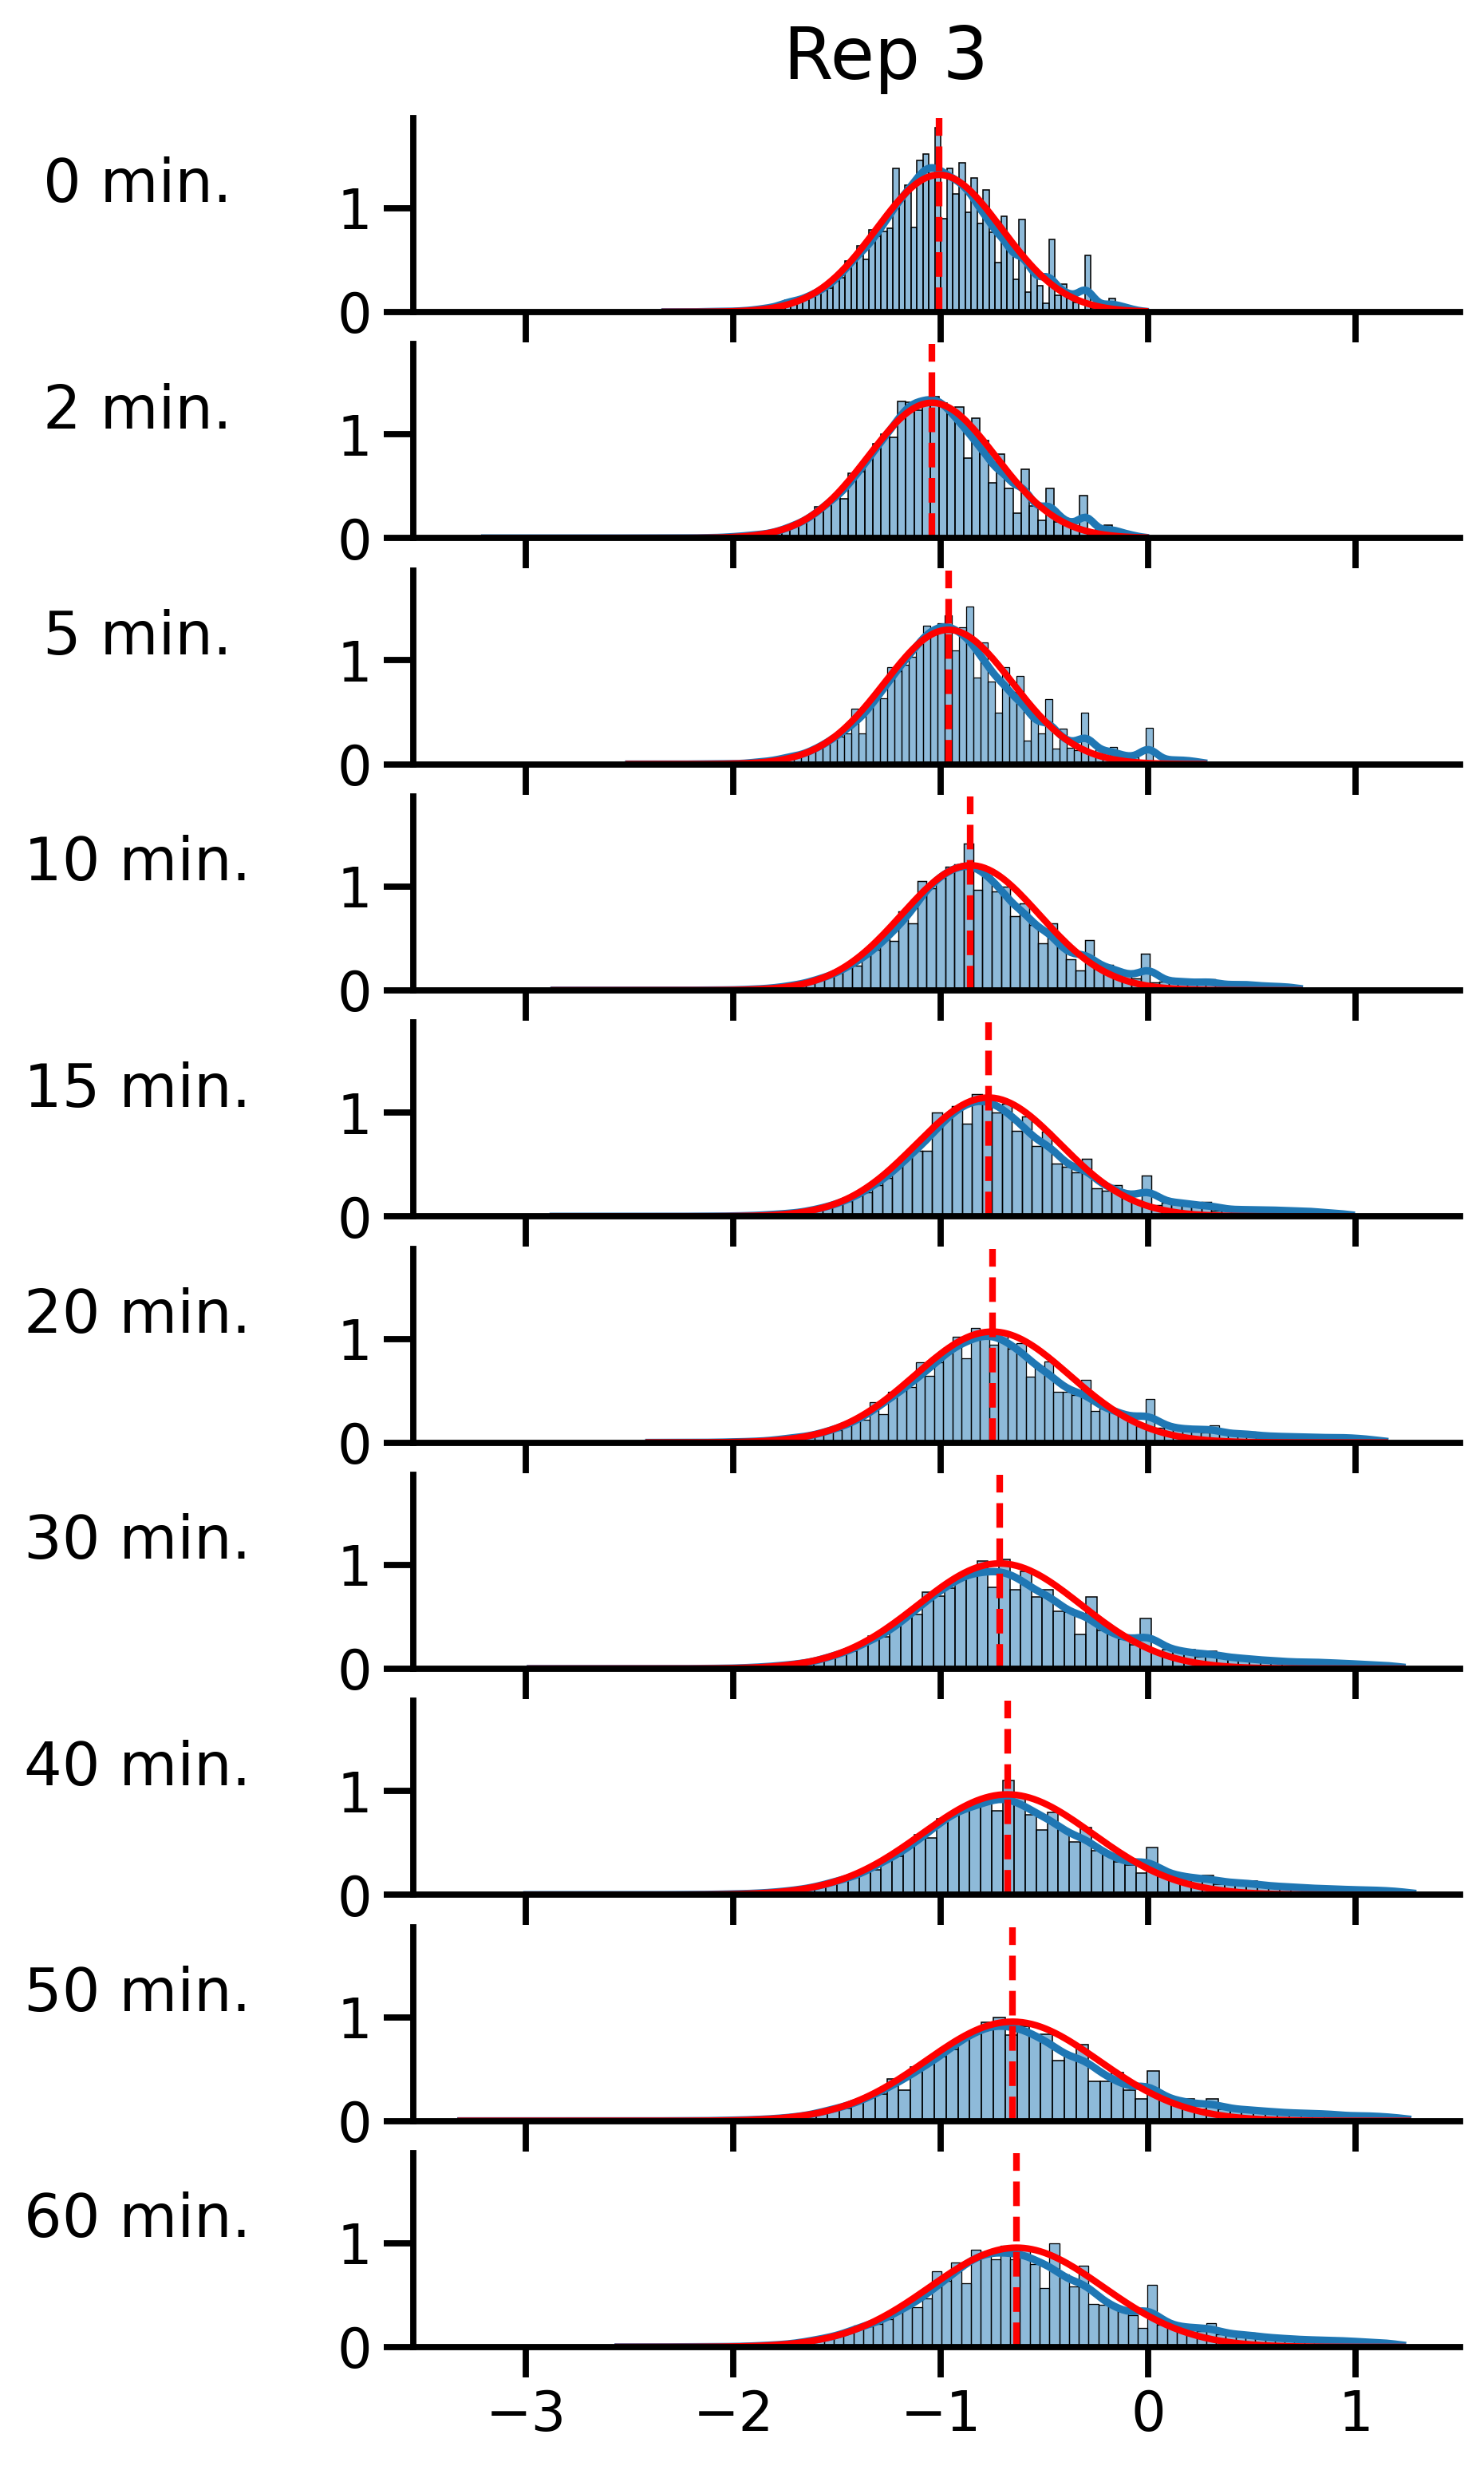

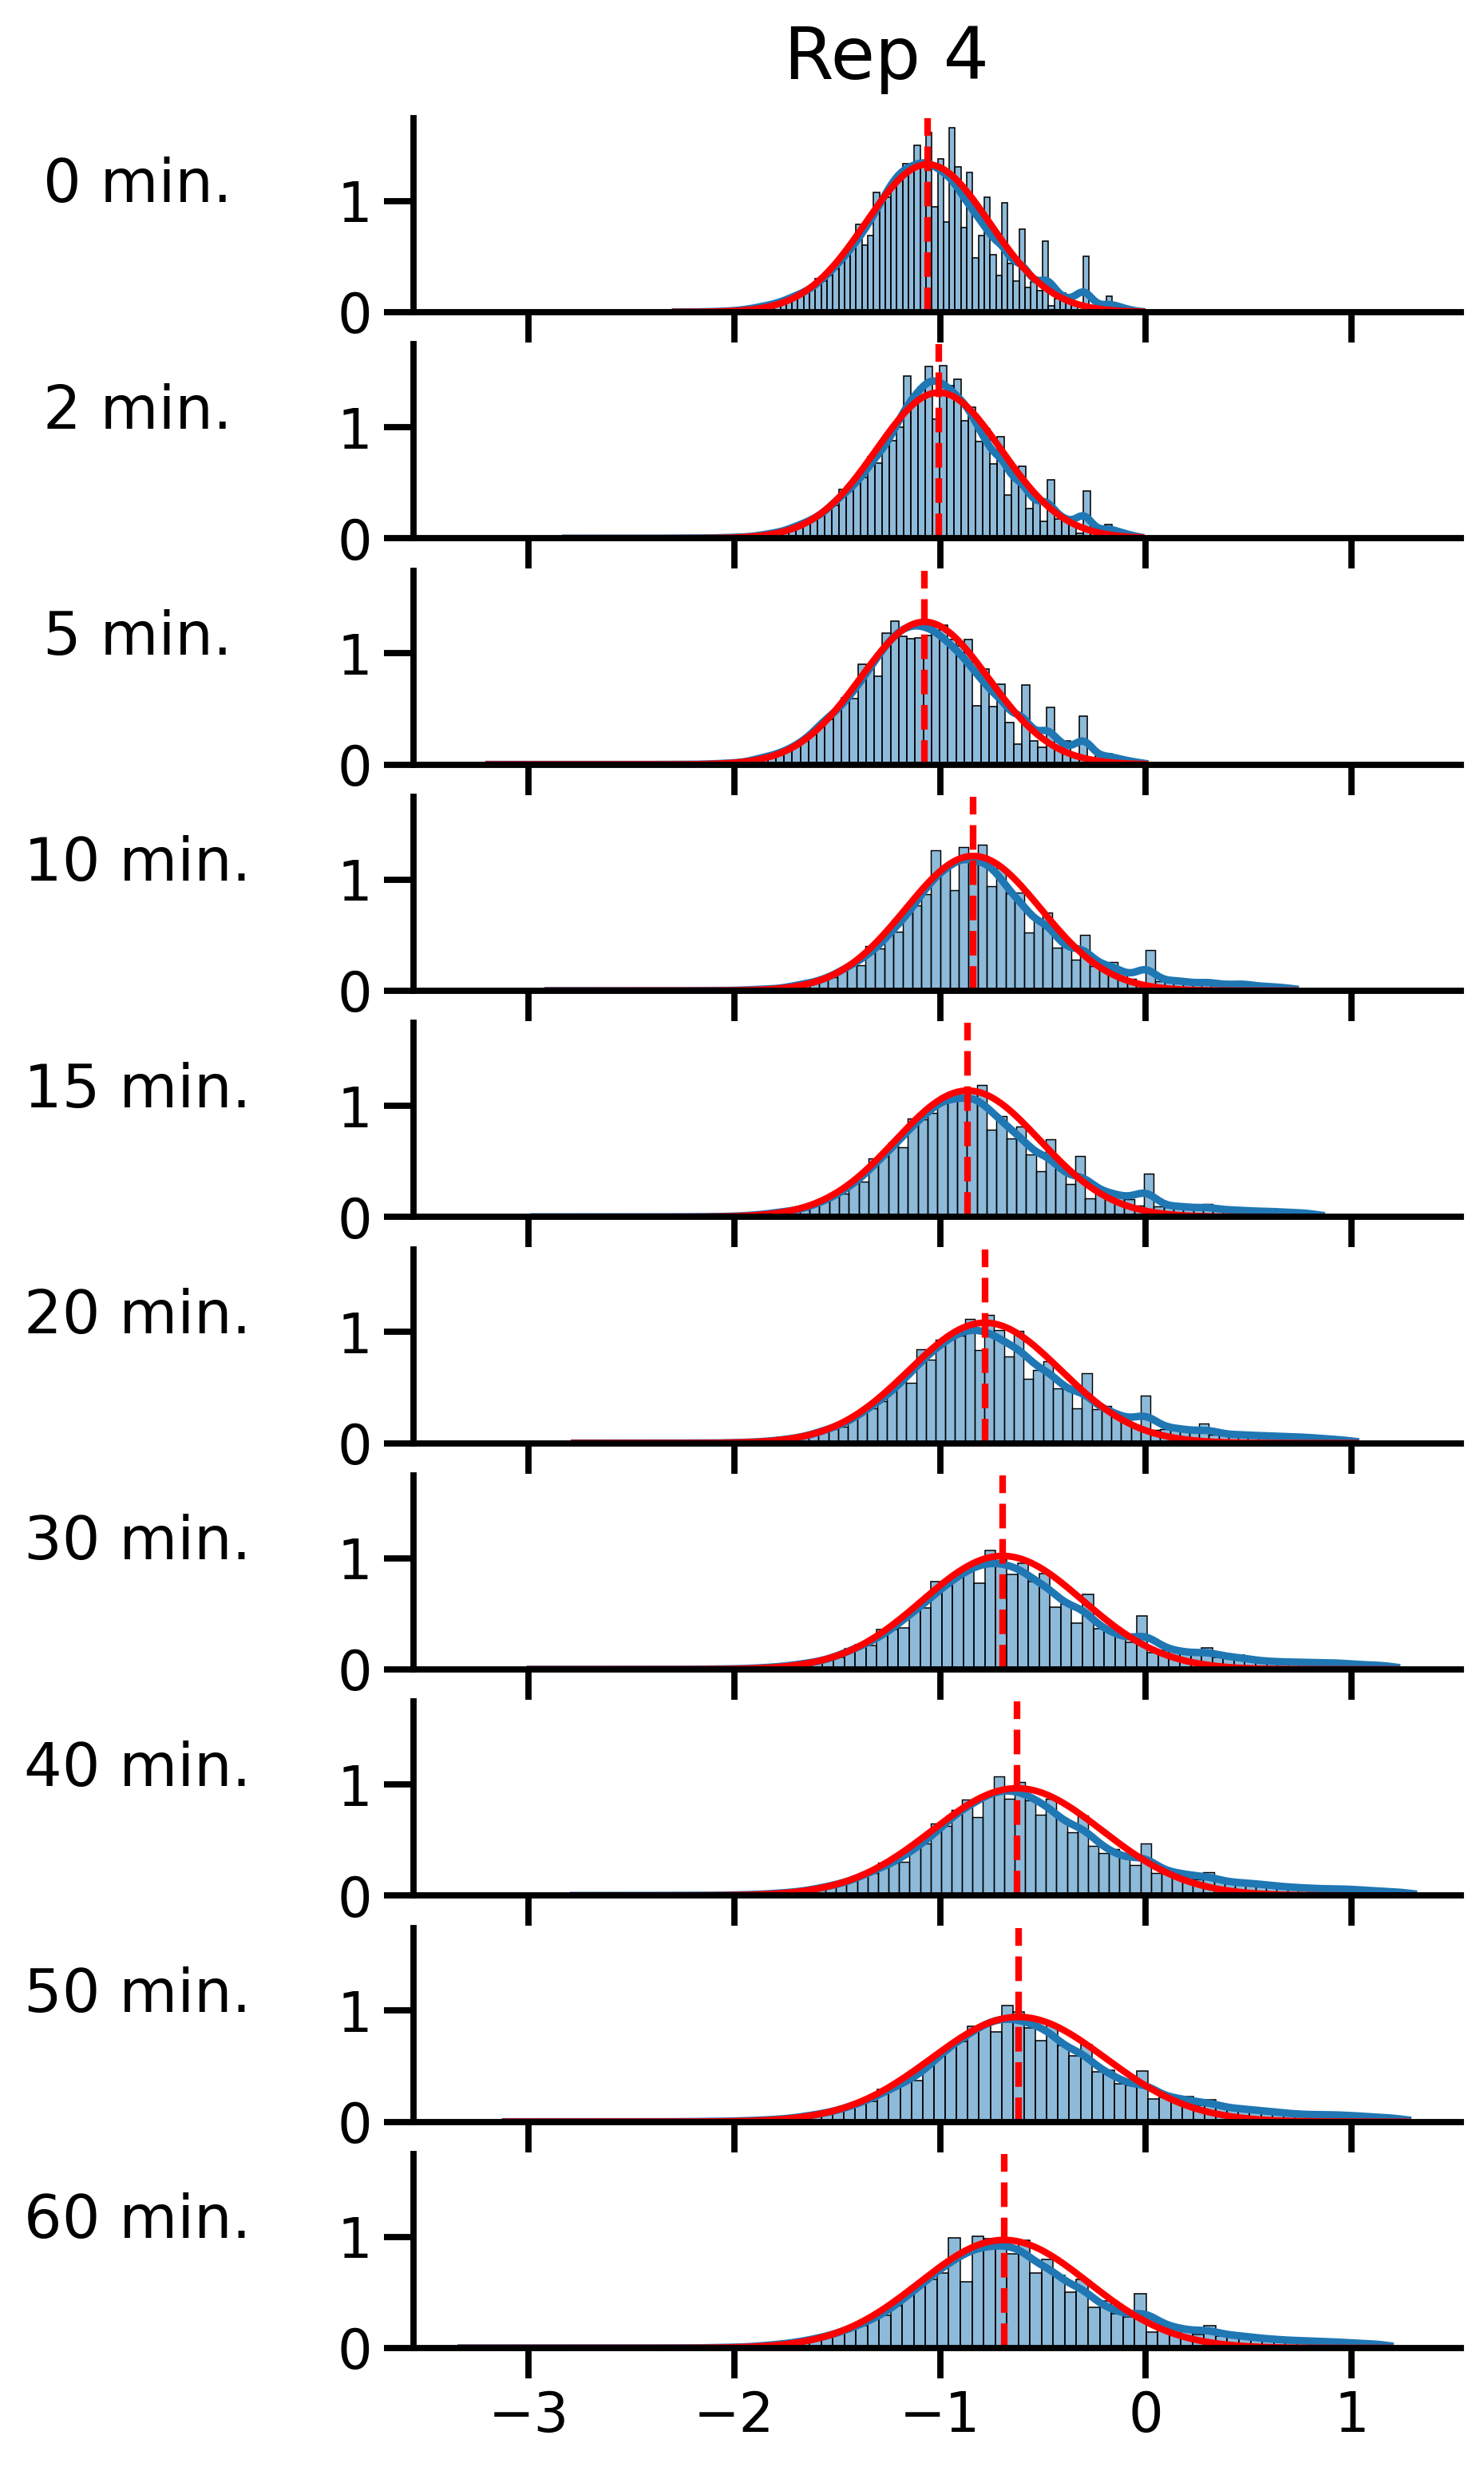

In [28]:
for target_rep in activities["rep"].unique():
    rep_keys = [(rep, time) for (rep, time) in cached_fits.keys() if rep == target_rep]
    rep_keys = sorted(rep_keys, key=lambda x: x[1])

    nrows = len(rep_keys)
    fig, axes = plt.subplots(nrows, 1, figsize=(6, nrows * 1), dpi=300, sharex=True, sharey=True)
    axes = np.atleast_1d(axes)

    fig.suptitle(f"Rep {target_rep}", fontsize='large', y=1.01, x=0.6)

    for ax, (rep, time) in zip(axes, rep_keys):
        mu, sigma, truncated, df = cached_fits[(rep, time)]

        sns.histplot(truncated, ax=ax, stat='density', bins=80, kde=True)
        ax.axvline(mu, color='red', linestyle='dashed', lw=2)

        x = np.linspace(min(truncated), max(truncated), 200)
        ax.plot(x, norm.pdf(x, mu, sigma), 'r-', lw=2)

        ax.set_ylabel(f"{time} min.", fontsize='medium', rotation=0, labelpad=60)
        ax.set_xlabel("")

    plt.tight_layout(pad=0)
    sns.despine()
    plt.show()

In [30]:
all_activities = pd.concat(
    [cached_fits[k][3] for k in cached_fits],
    ignore_index=True
)
all_activities

,seq,AD_BC,score,rep,time,z-score
0,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,ATAACCAATGG,-1.201645,2,0,-0.506097
1,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,TATCTTCGCTT,-1.380211,2,0,-1.093743
2,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,AATCGTACCGA,-1.447158,2,0,-1.314059
3,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,TTGCATAGCTG,-1.799341,2,0,-2.473062
4,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,TTTATAATACC,-1.124939,2,0,-0.253662
...,...,...,...,...,...,...
1361924,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,CCAAACTTGGA,-1.122216,4,60,-1.054444
1361925,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,CCCACTCTCAG,-0.954243,4,60,-0.645097
1361926,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,GGGTCGTAAAT,-0.425969,4,60,0.642294
1361927,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,GATCCCATGCA,-0.421324,4,60,0.653613


In [31]:
def fit_inactive_gaussian_v2(df, ax=None):
    scores = np.array(df["score"])
    search_ceiling = np.percentile(scores, 95)
    truncated = scores[scores < search_ceiling]
    
    # search_floor = np.percentile(scores, 0)
    # truncated = truncated[search_floor < truncated]

    kde = gaussian_kde(truncated, bw_method=0.2)
    x_vals = np.linspace(min(scores), search_ceiling, 1000)
    peak_location = x_vals[np.argmax(kde(x_vals))]
    left_of_peak = scores[scores < peak_location]
    mirrored = np.concatenate([left_of_peak, 2 * peak_location - left_of_peak])
    sigma = np.std(mirrored)
    mu = peak_location

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3), dpi=150)

    sns.histplot(truncated, ax=ax, stat='density', kde=True)
    ax.axvline(mu, color='red', linestyle='dashed', lw=2, label=f'peak={mu:.3f}')
    x = np.linspace(min(truncated), max(truncated), 200)
    ax.plot(x, norm.pdf(x, mu, sigma), 'r-', lw=2)
    y_max = max(p.get_height() for p in ax.patches)
    # ax.set_ylim(0, y_max * 1.15)
    ax.legend(fontsize=8)
    ax.set_title(f"rep={df['rep'].iloc[0]}, time={df['time'].iloc[0]}", fontsize=8)

    df = df.copy()
    df["z-score"] = (df["score"] - mu) / sigma
    return df

,seq,AD_BC,score,rep,time,z-score
0,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,ATAACCAATGG,-1.311754,2,5,-0.915417
1,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,TATCTTCGCTT,-1.431364,2,5,-1.298457
2,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,TTGCATAGCTG,-0.963788,2,5,0.198912
3,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,TTTATAATACC,-1.397940,2,5,-1.191420
4,KNSHSVISSRRSSFNMMHSRRSSFNSHAPTEPISRRASLV,ACGTTCGACGT,-0.477121,2,5,1.757418
...,...,...,...,...,...,...
39008,FVSCVFWNNLYYITGTDIVKCCLYRMQKFGREVVQKKKFE,ACACCGTGACC,-1.301030,2,5,-0.881075
39009,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,CCAAACTTGGA,-1.342423,2,5,-1.013631
39010,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,CCCACTCTCAG,0.000000,2,5,3.285355
39011,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,GATCCCATGCA,-1.441957,2,5,-1.332380


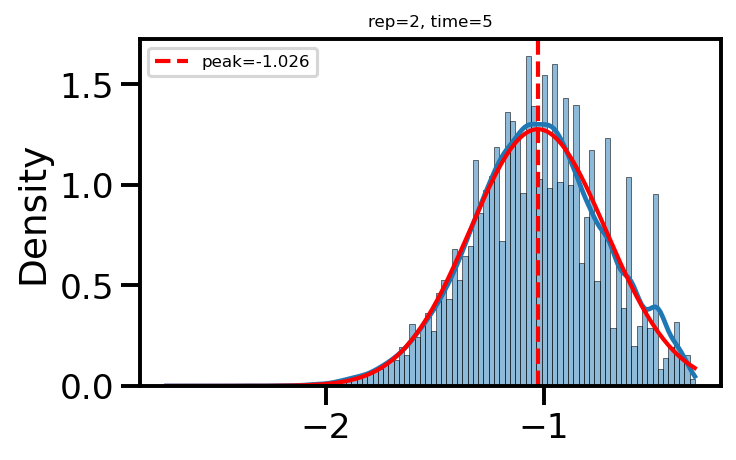

In [32]:
fit_inactive_gaussian_v2(activities_by_time_rep[(2,5)])

In [33]:
# --- Run once, cache results ---
groups = list(activities.groupby(['rep', 'time']))
cached_fits = {}  # (rep, time) -> (mu, sigma, truncated, df_out)

for (rep, time), group in tqdm.tqdm(groups):
    df = activities_by_time_rep[(rep, time)].copy()
    scores = np.array(df["score"])
    search_ceiling = np.percentile(scores, 95)
    truncated = scores[scores < search_ceiling]
    
    # search_floor = np.percentile(scores, 0)
    # truncated = truncated[search_floor < truncated]
    
    kde = gaussian_kde(truncated, bw_method=0.2)
    x_vals = np.linspace(min(scores), search_ceiling, 1000)
    peak_location = x_vals[np.argmax(kde(x_vals))]
    left_of_peak = scores[scores < peak_location]
    mirrored = np.concatenate([left_of_peak, 2 * peak_location - left_of_peak])
    sigma = np.std(mirrored)
    mu = peak_location
    df["z-score"] = (df["score"] - mu) / sigma
    cached_fits[(rep, time)] = (mu, sigma, truncated, df)

log_norm_activities = [cached_fits[k][3] for k in cached_fits]

100%|██████████| 30/30 [00:26<00:00,  1.11it/s]


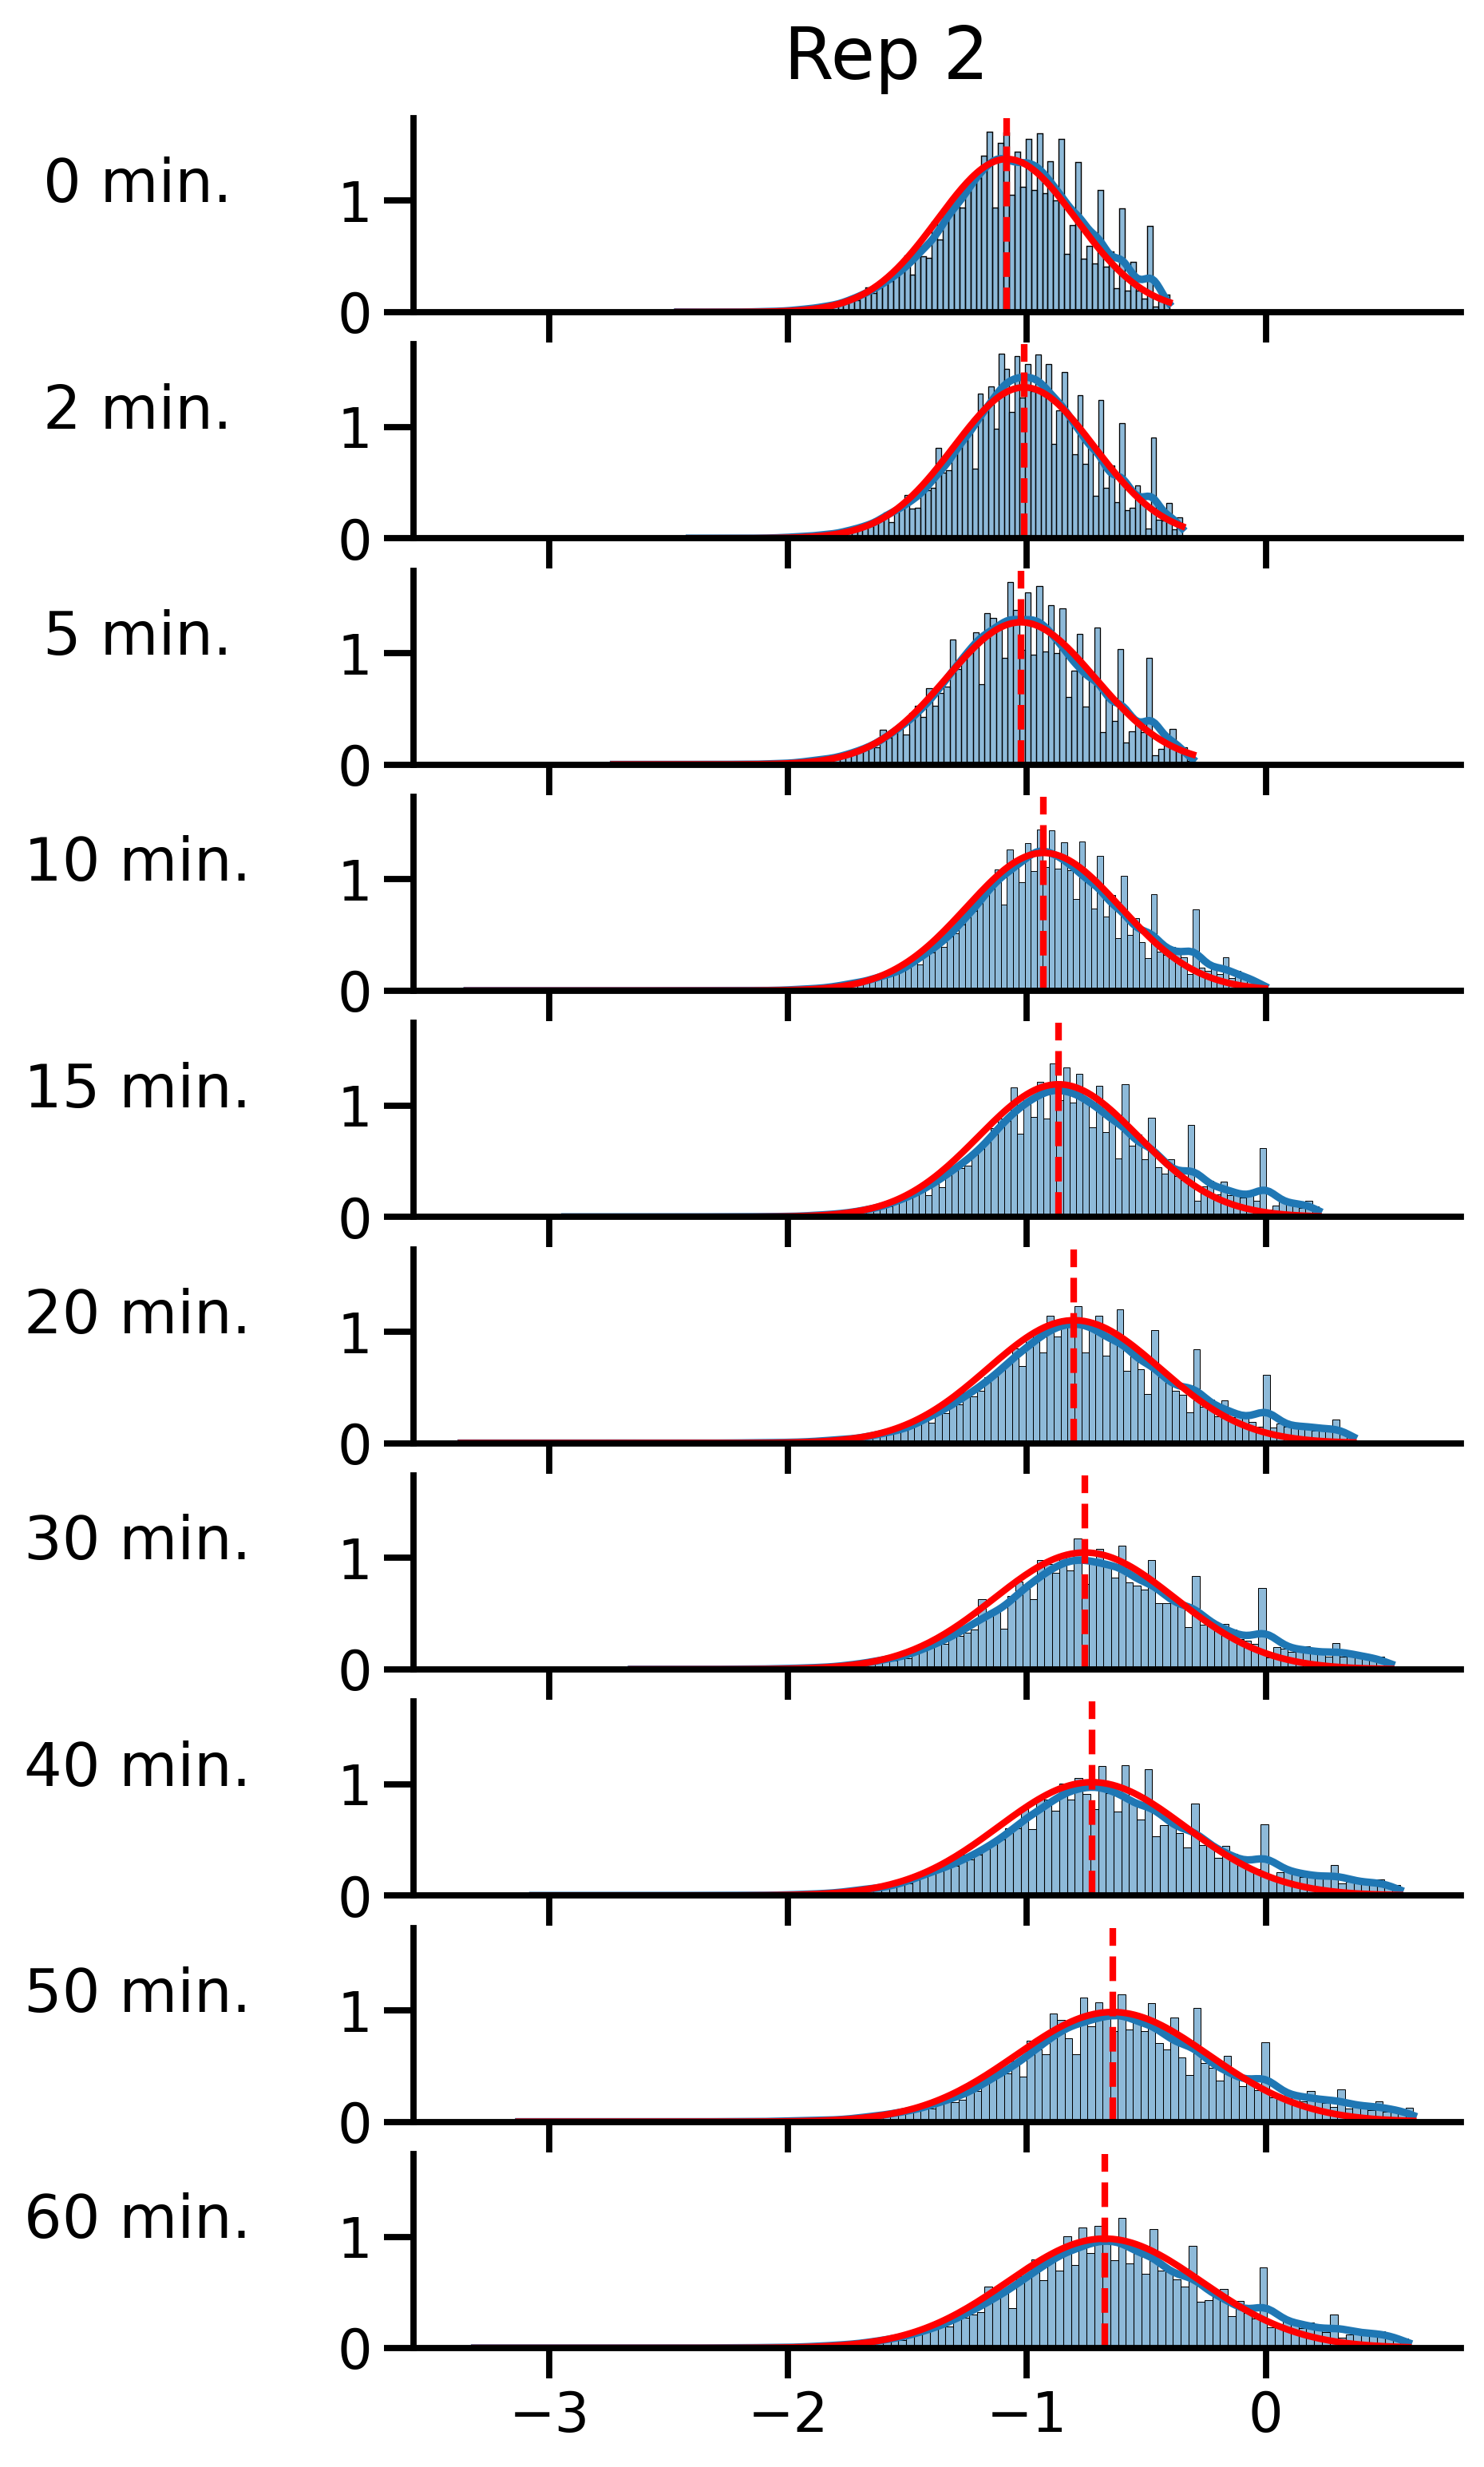

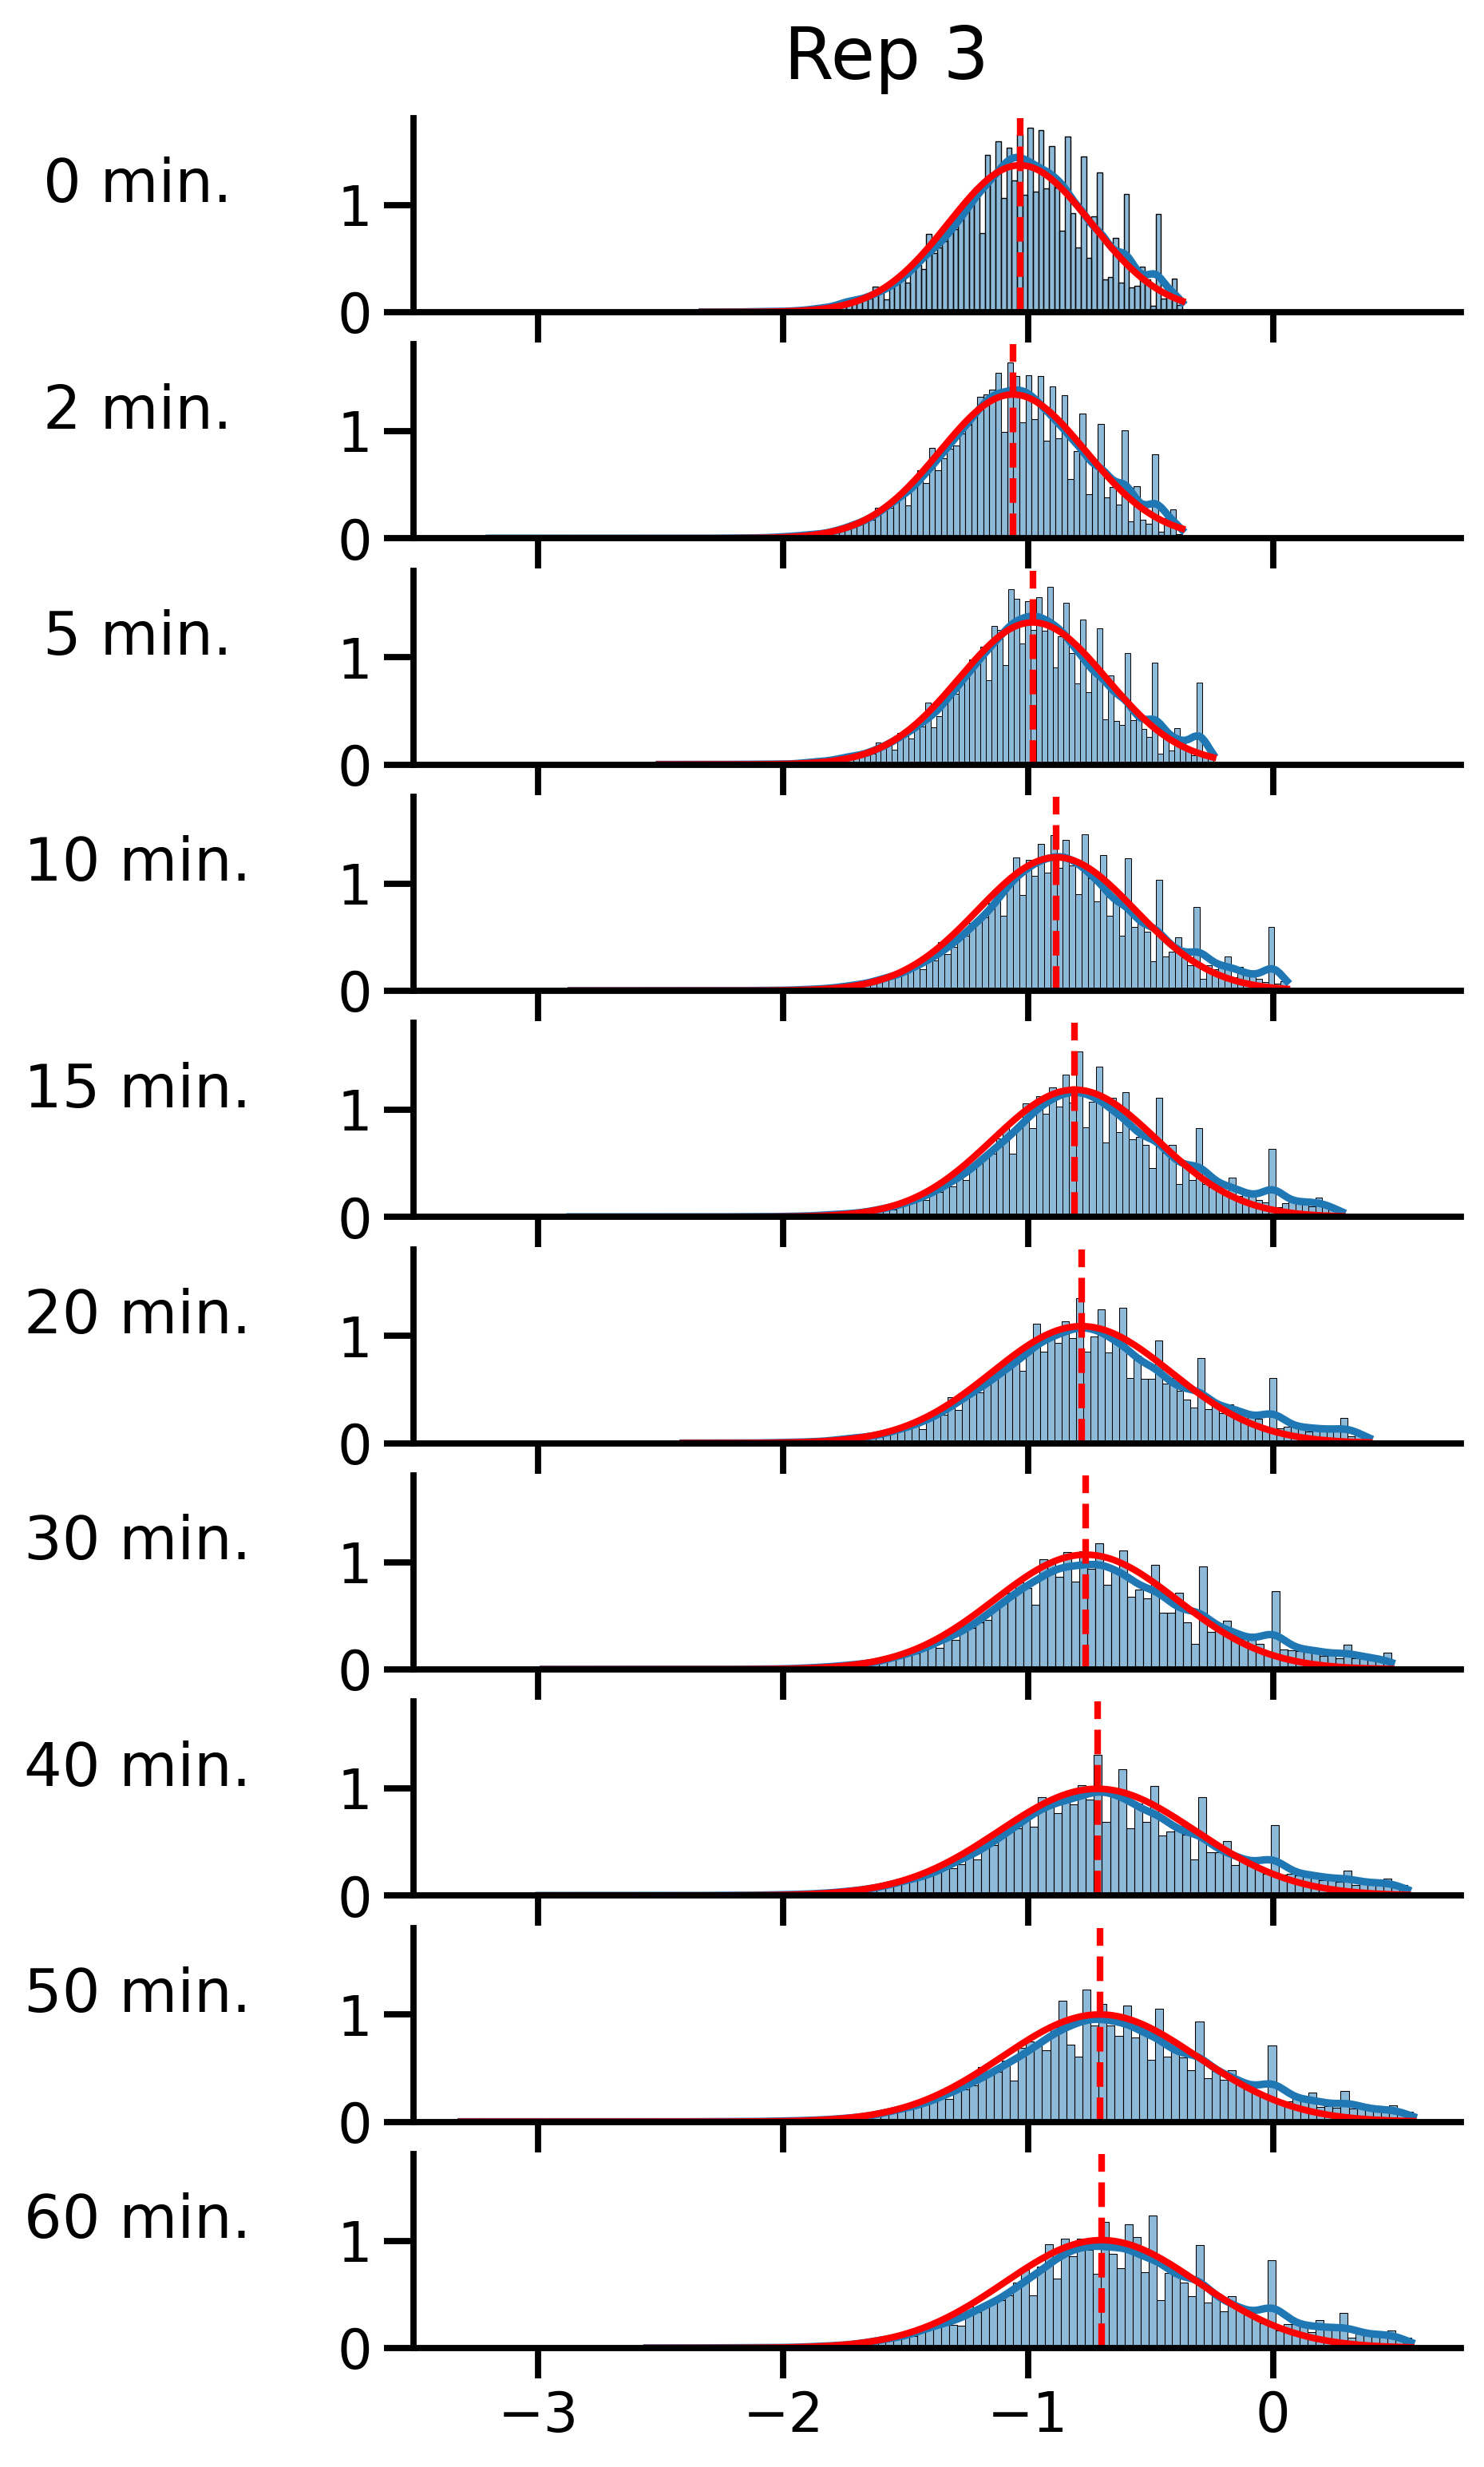

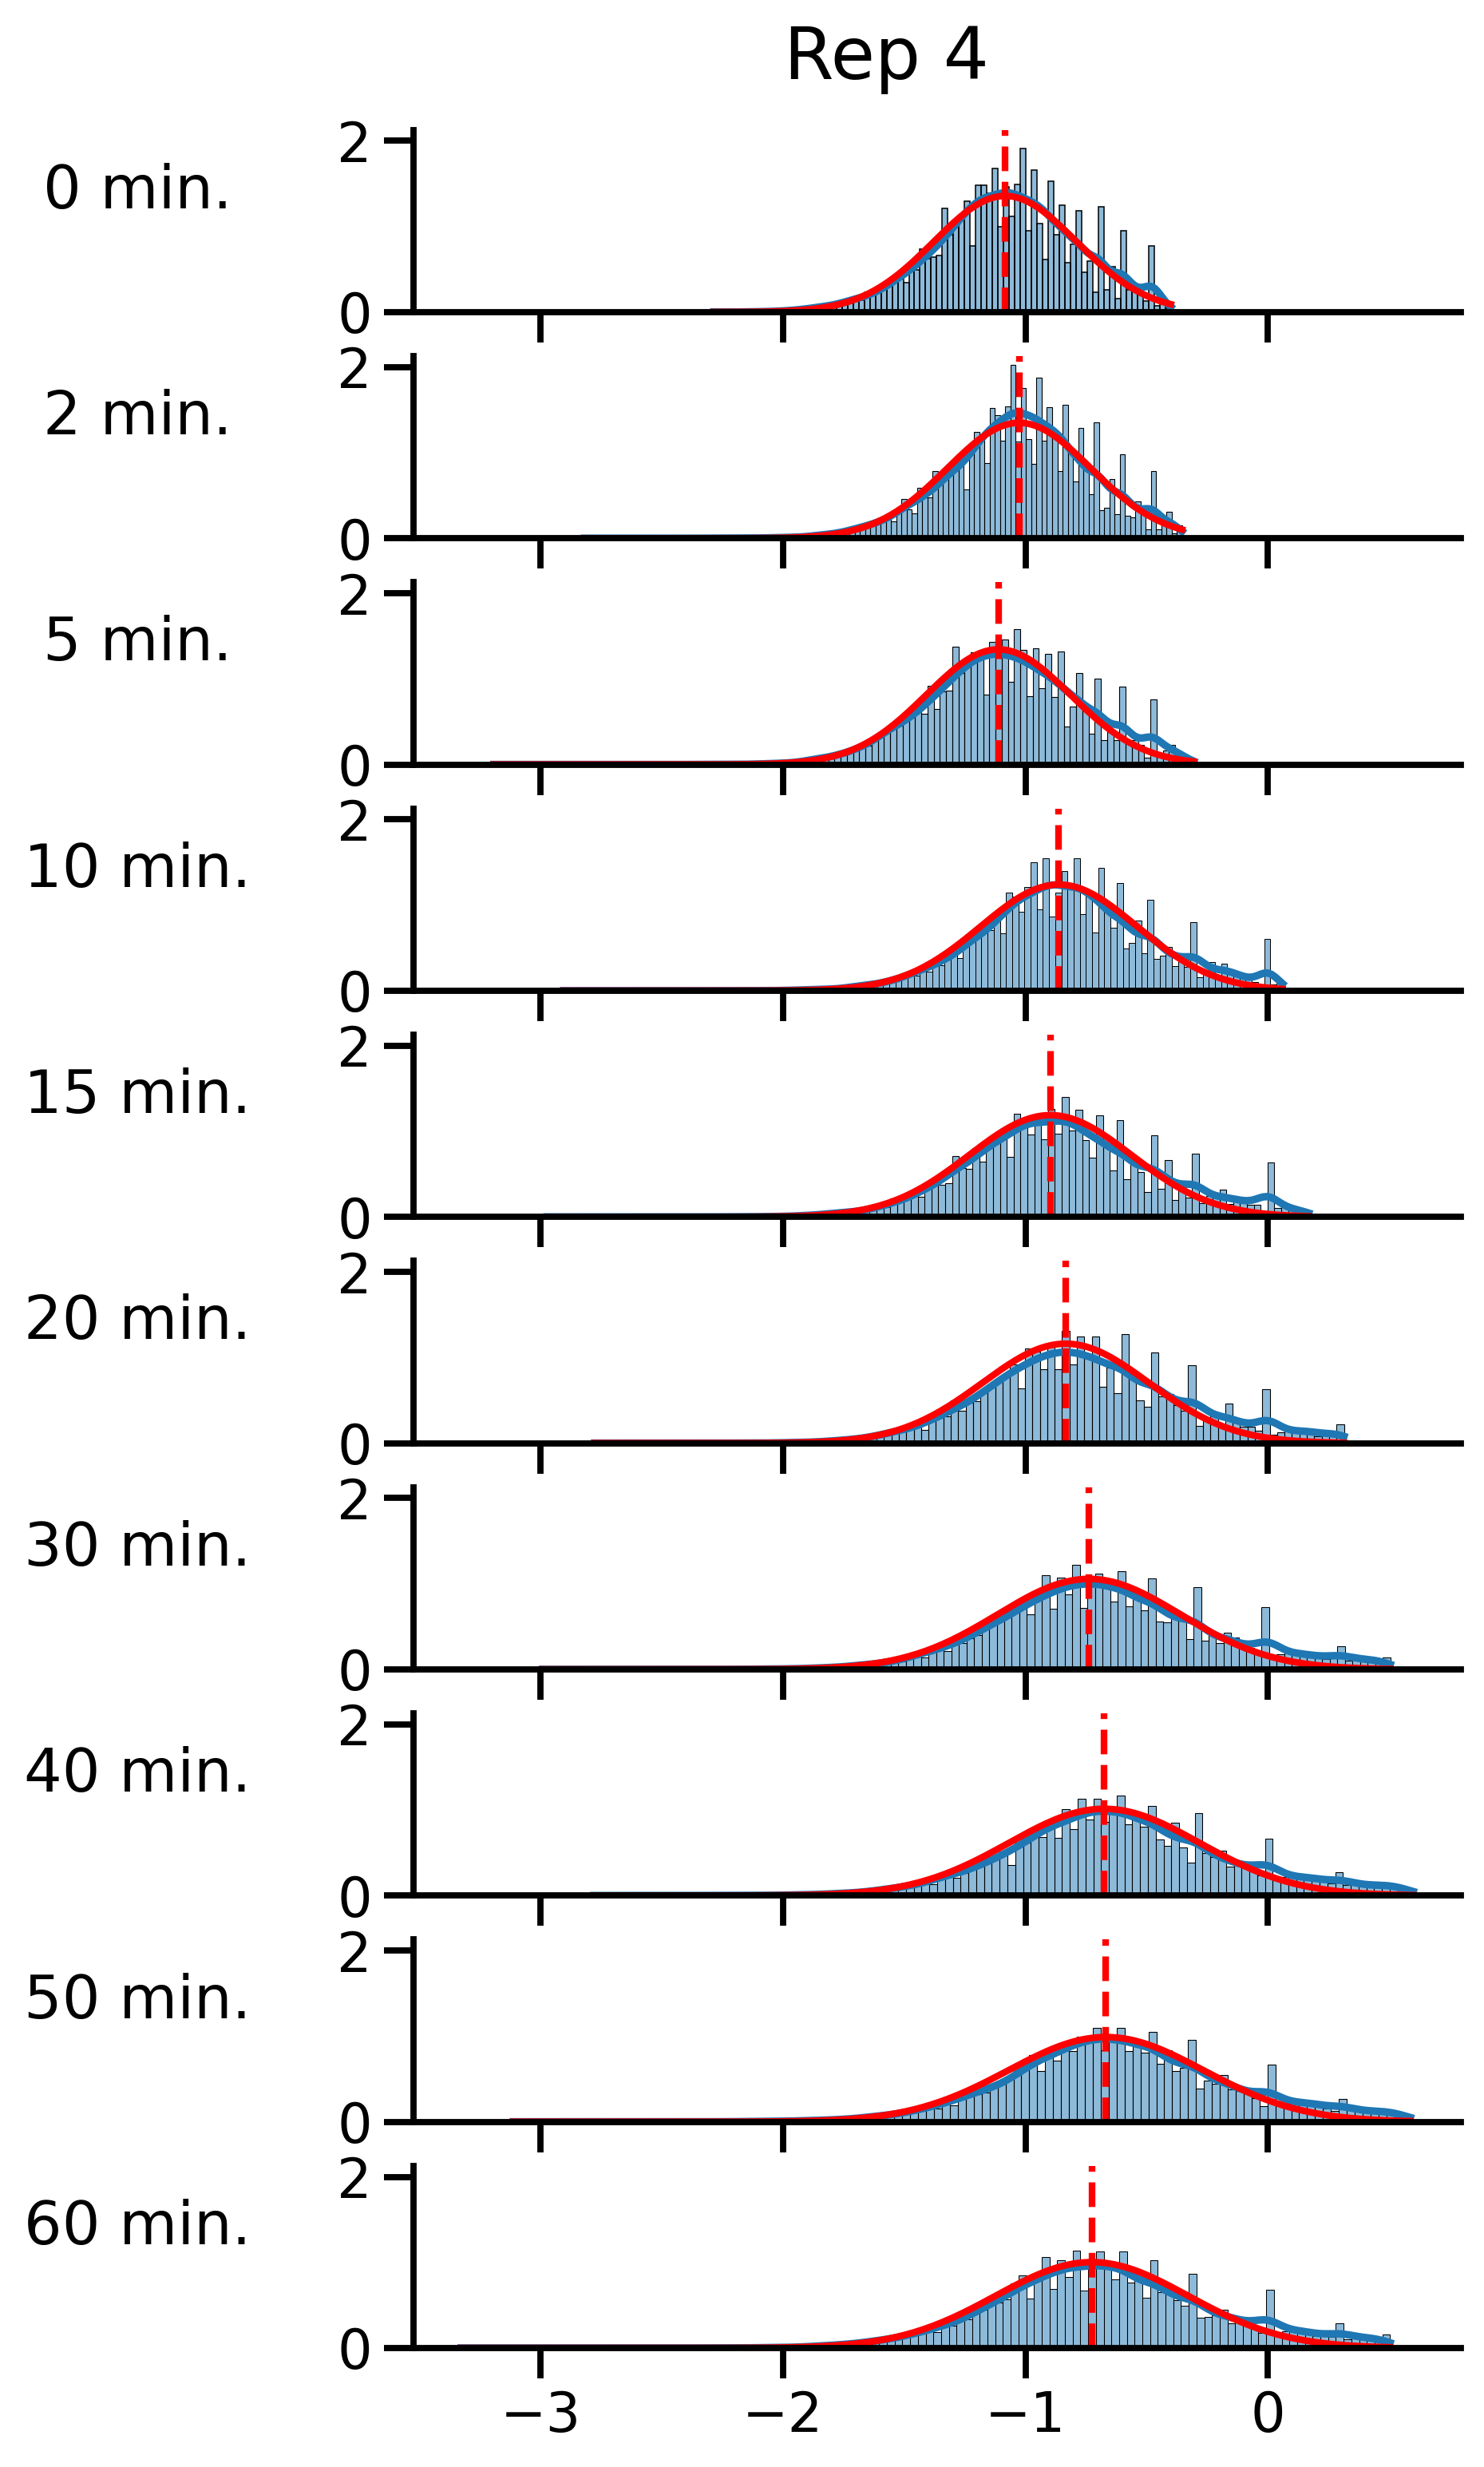

In [34]:
for target_rep in activities["rep"].unique():
    rep_keys = [(rep, time) for (rep, time) in cached_fits.keys() if rep == target_rep]
    rep_keys = sorted(rep_keys, key=lambda x: x[1])  # sort by time

    nrows = len(rep_keys)
    fig, axes = plt.subplots(nrows, 1, figsize=(6, nrows * 1), dpi=300, sharex=True, sharey=True)
    axes = np.atleast_1d(axes)
    fig.suptitle(f"Rep {target_rep}", fontsize='large', y = 1.01, x = 0.6)

    for ax, (rep, time) in zip(axes, rep_keys):
        mu, sigma, truncated, df = cached_fits[(rep, time)]
        sns.histplot(truncated, ax=ax, stat='density', kde=True)
        ax.axvline(mu, color='red', linestyle='dashed', lw=2)
        x = np.linspace(min(truncated), max(truncated), 200)
        ax.plot(x, norm.pdf(x, mu, sigma), 'r-', lw=2)
        y_max = max(p.get_height() for p in ax.patches)
        # ax.set_ylim(0, y_max * 1.15)
        ax.set_ylabel(f"{time} min.", fontsize='medium', rotation = 0, labelpad = 60)
        ax.set_xlabel("")

    plt.tight_layout(pad = 0)
    sns.despine()
    plt.show()

In [36]:
log_norm_activities_df = pd.concat(log_norm_activities)
log_norm_activities_df["active"] = log_norm_activities_df["z-score"] > 2
log_norm_activities_df

,seq,AD_BC,score,rep,time,z-score,active
0,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,ATAACCAATGG,-1.201645,2,0,-0.405362,False
1,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,TATCTTCGCTT,-1.380211,2,0,-1.020770,False
2,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,AATCGTACCGA,-1.447158,2,0,-1.251494,False
3,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,TTGCATAGCTG,-1.799341,2,0,-2.465253,False
4,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,TTTATAATACC,-1.124939,2,0,-0.141001,False
...,...,...,...,...,...,...,...
47341,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,CCAAACTTGGA,-1.122216,4,60,-0.995653,False
47342,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,CCCACTCTCAG,-0.954243,4,60,-0.573284,False
47343,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,GGGTCGTAAAT,-0.425969,4,60,0.755060,False
47344,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,GATCCCATGCA,-0.421324,4,60,0.766739,False


In [38]:
log_norm_activities_df.to_csv("../../../output/ChopTFs_pipeline/tentative_Z-scored_barcode_activities.csv")

100%|██████████| 10/10 [00:01<00:00,  9.77it/s]


Text(0.5, 0.9, 'Chop TFs Rep 4')

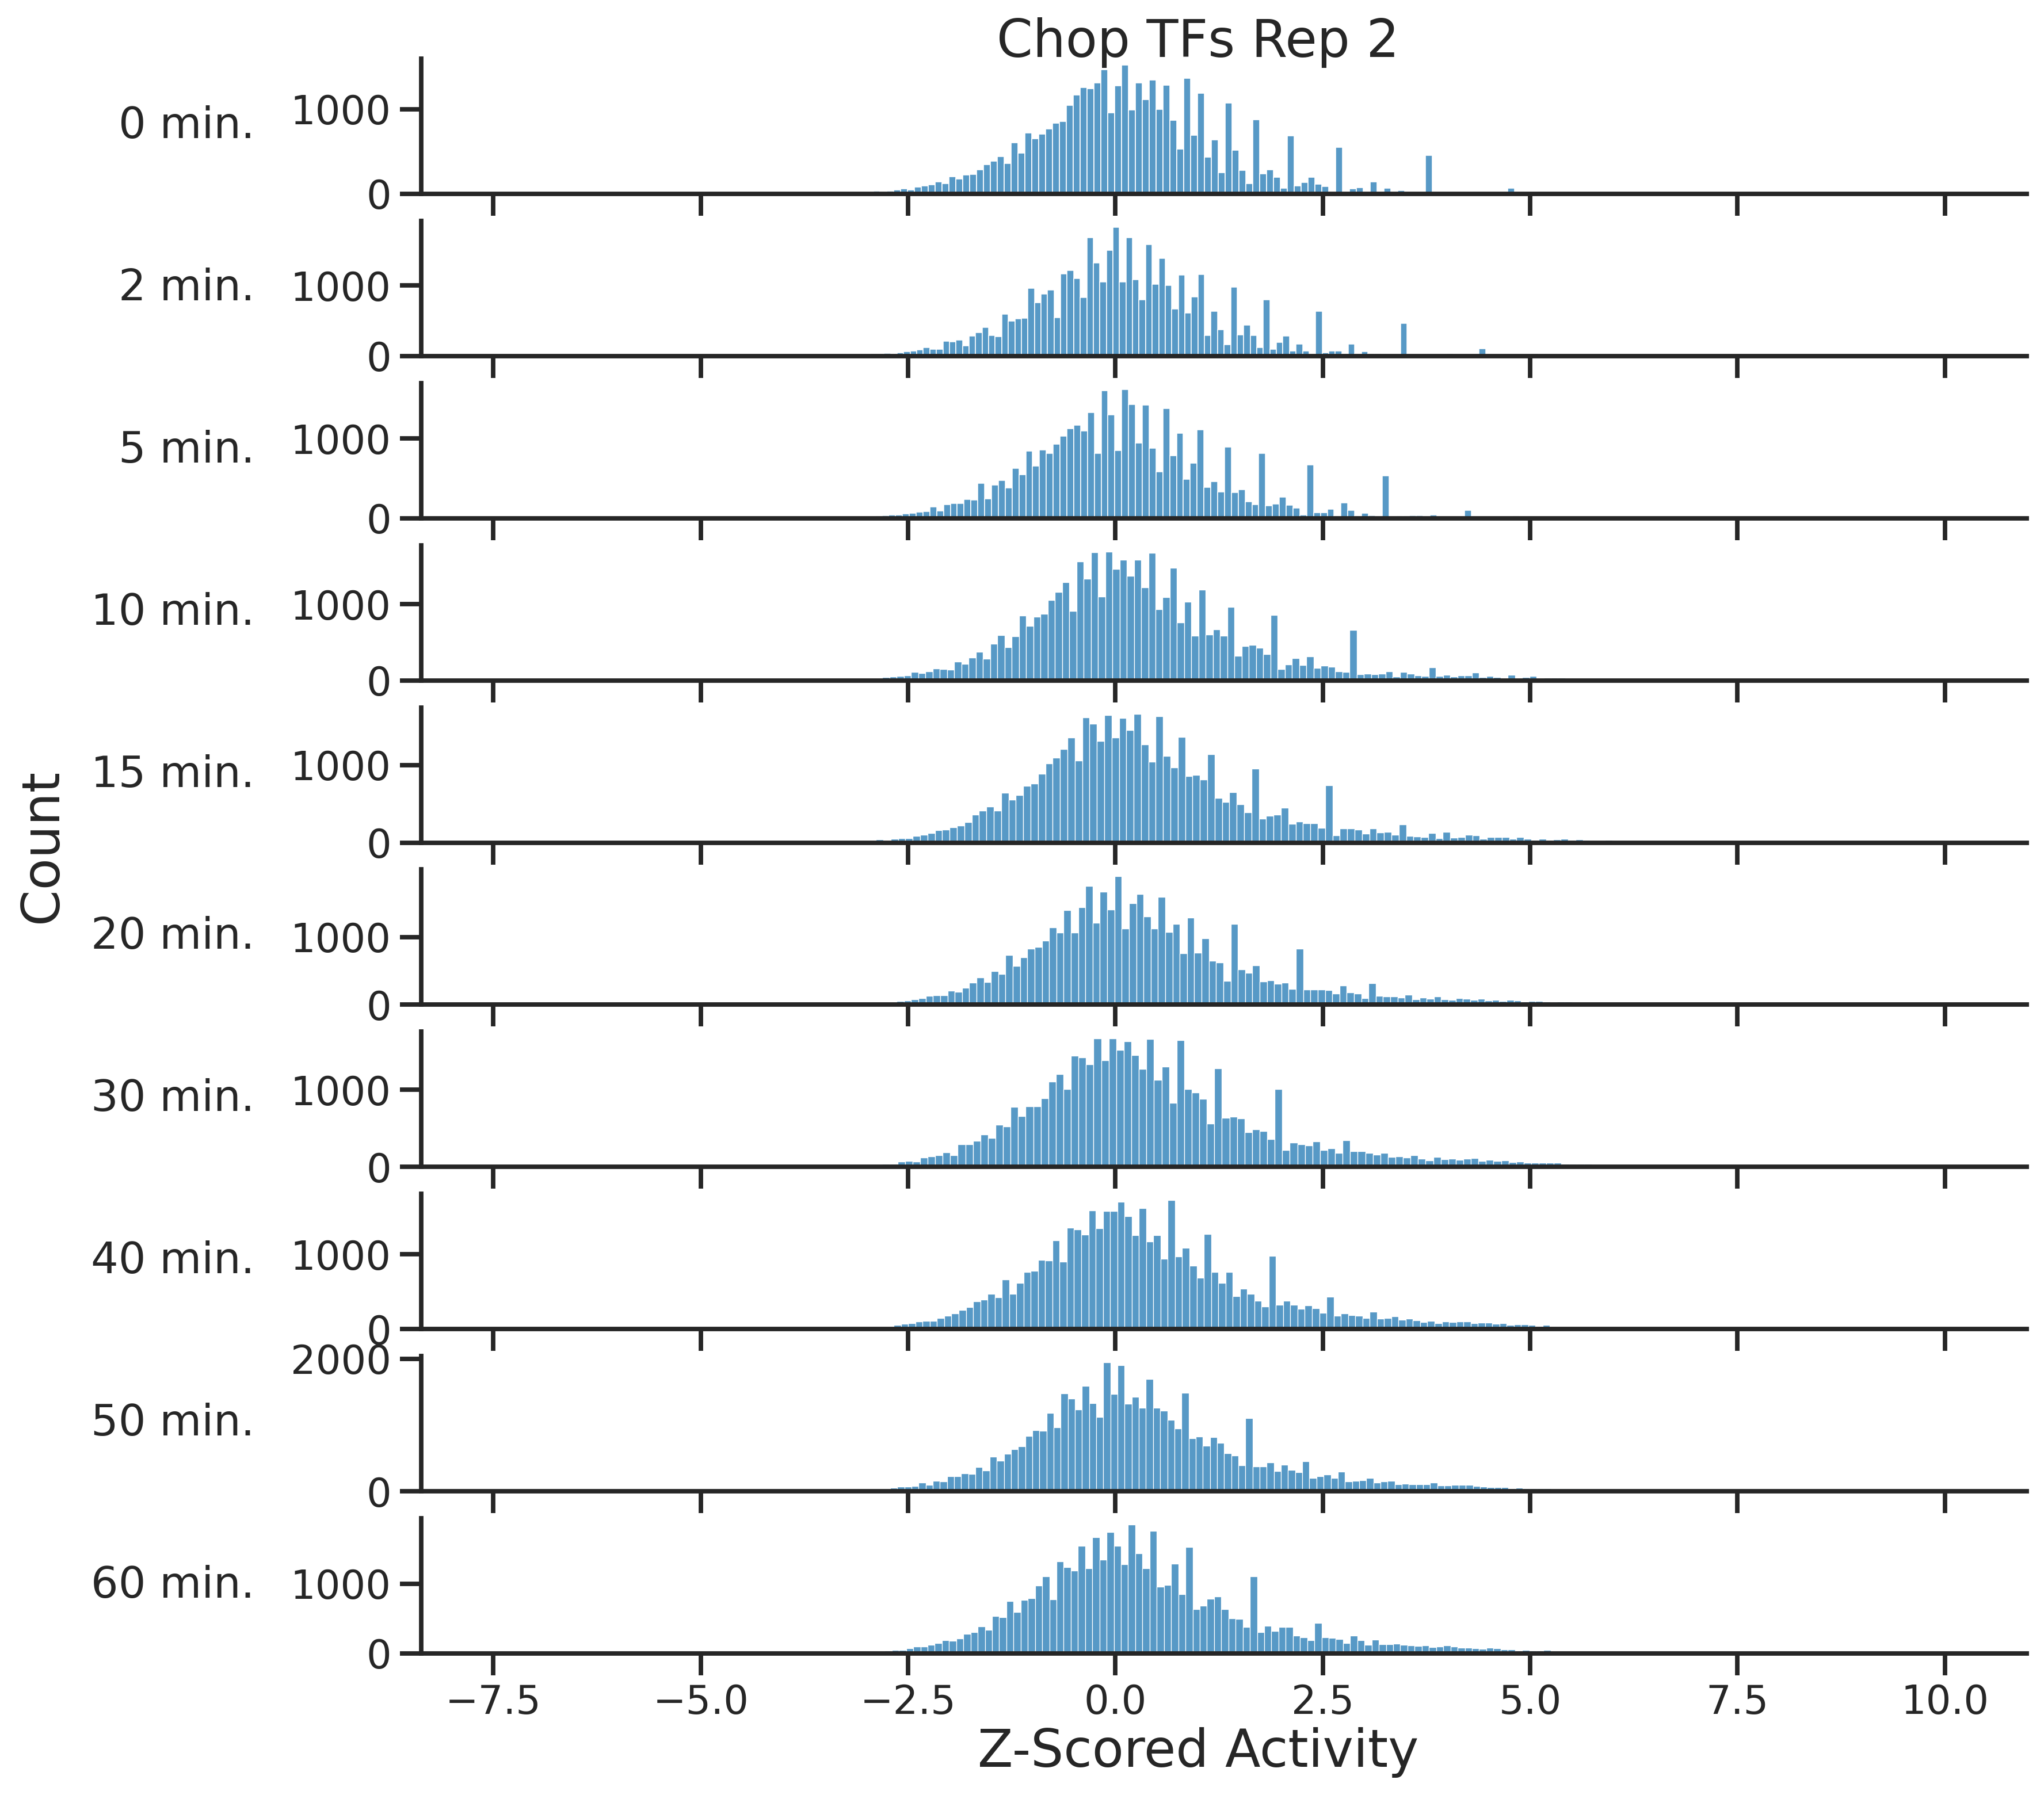

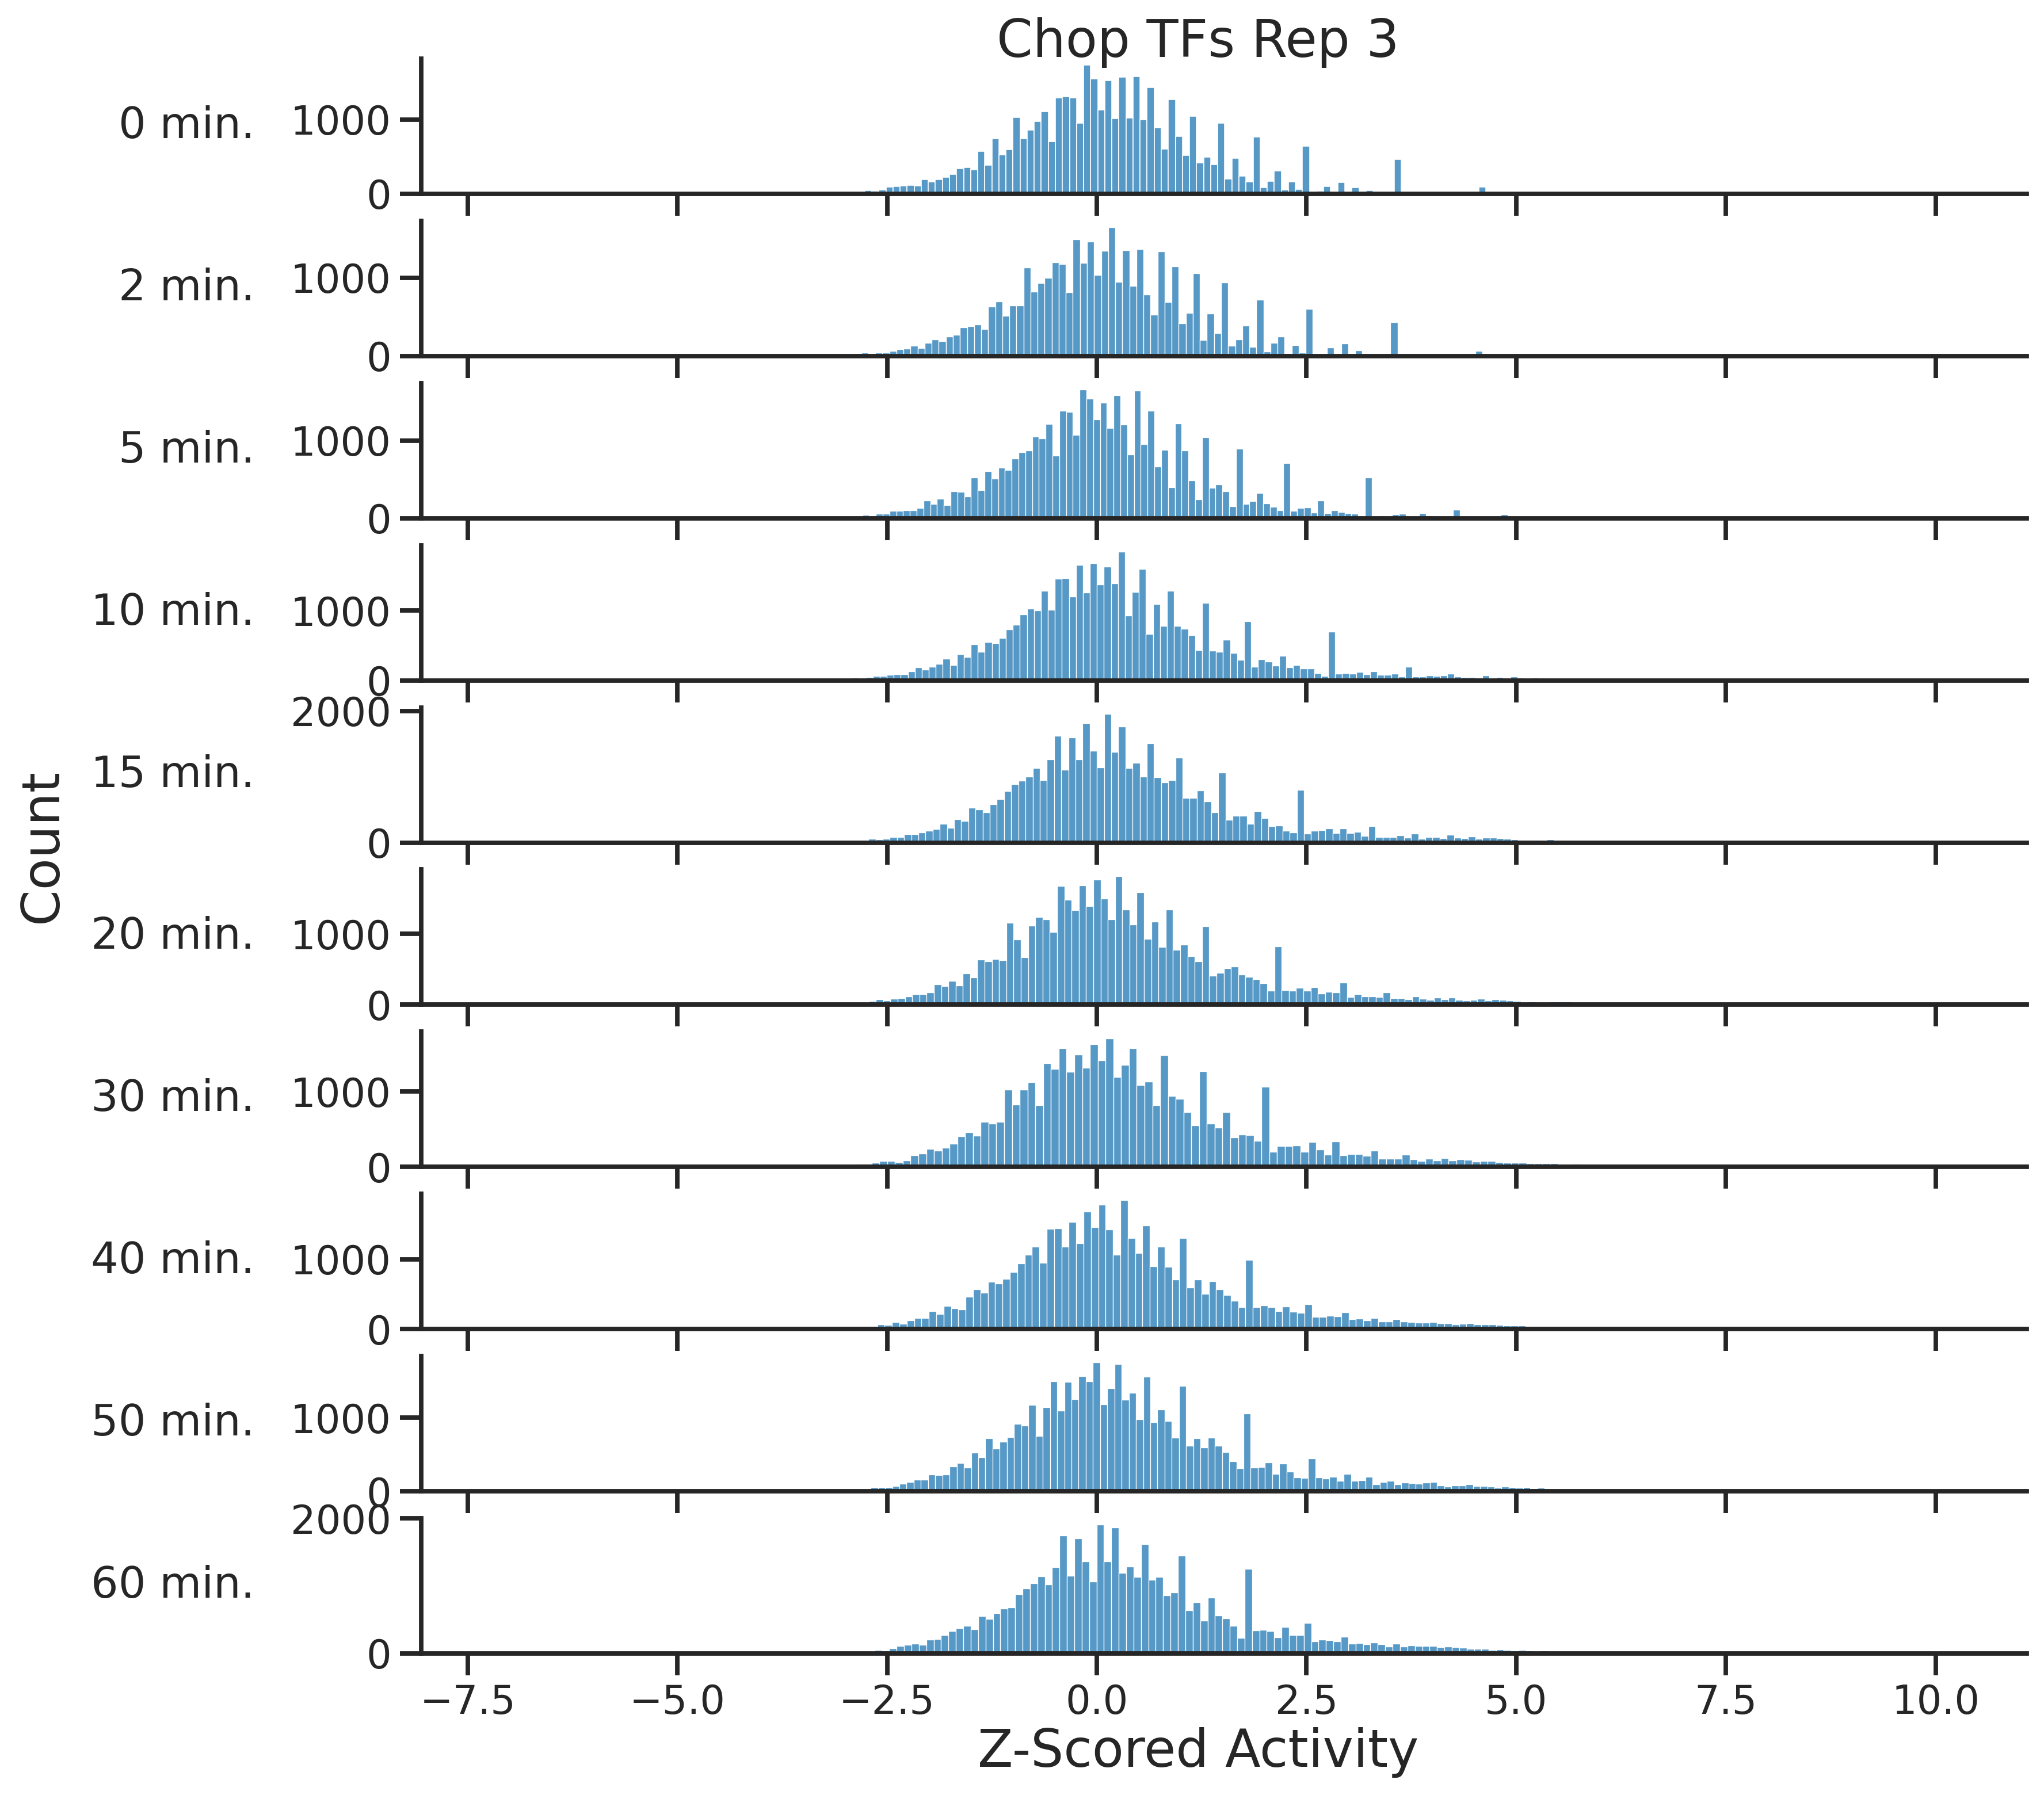

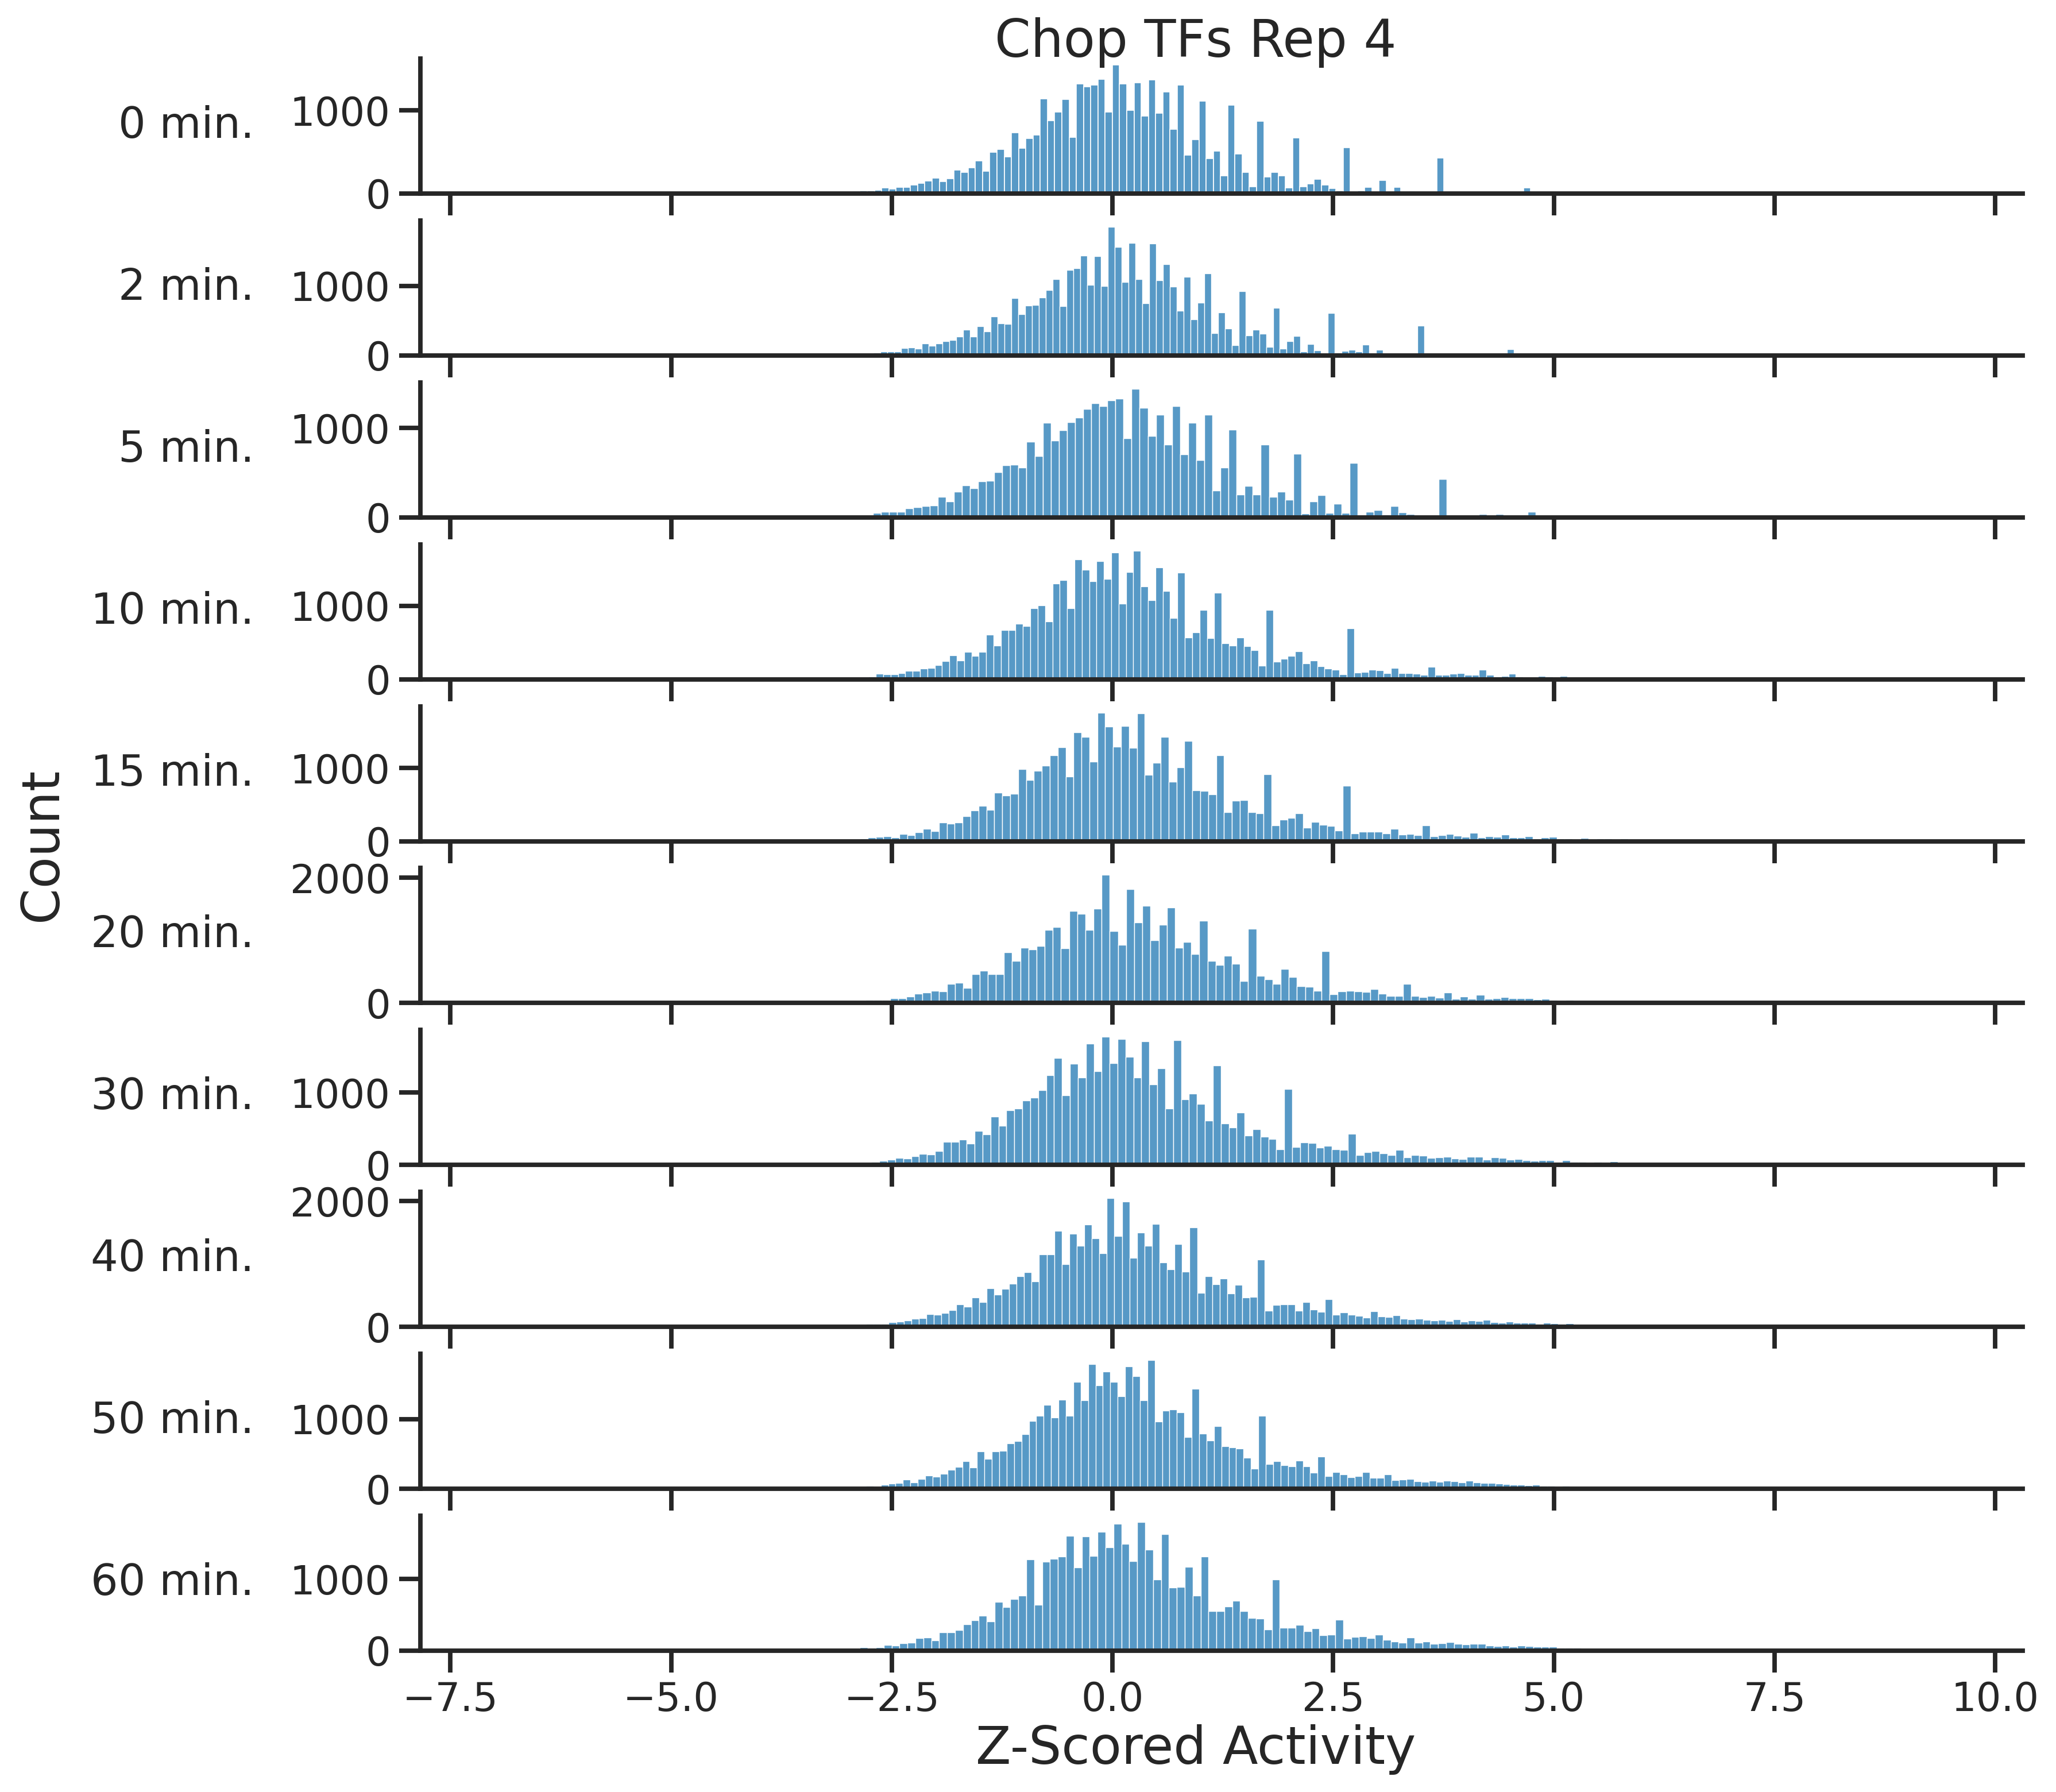

In [178]:
fig, axs = plot_hists_over_time(log_norm_activities_df[log_norm_activities_df["rep"] == 2], "z-score", xlabel = "Z-Scored Activity")
fig.suptitle("Chop TFs Rep 2", y = 0.9)

fig, axs = plot_hists_over_time(log_norm_activities_df[log_norm_activities_df["rep"] == 3], "z-score", xlabel = "Z-Scored Activity")
fig.suptitle("Chop TFs Rep 3", y = 0.9)

fig, axs = plot_hists_over_time(log_norm_activities_df[log_norm_activities_df["rep"] == 4], "z-score", xlabel = "Z-Scored Activity")
fig.suptitle("Chop TFs Rep 4", y = 0.9)

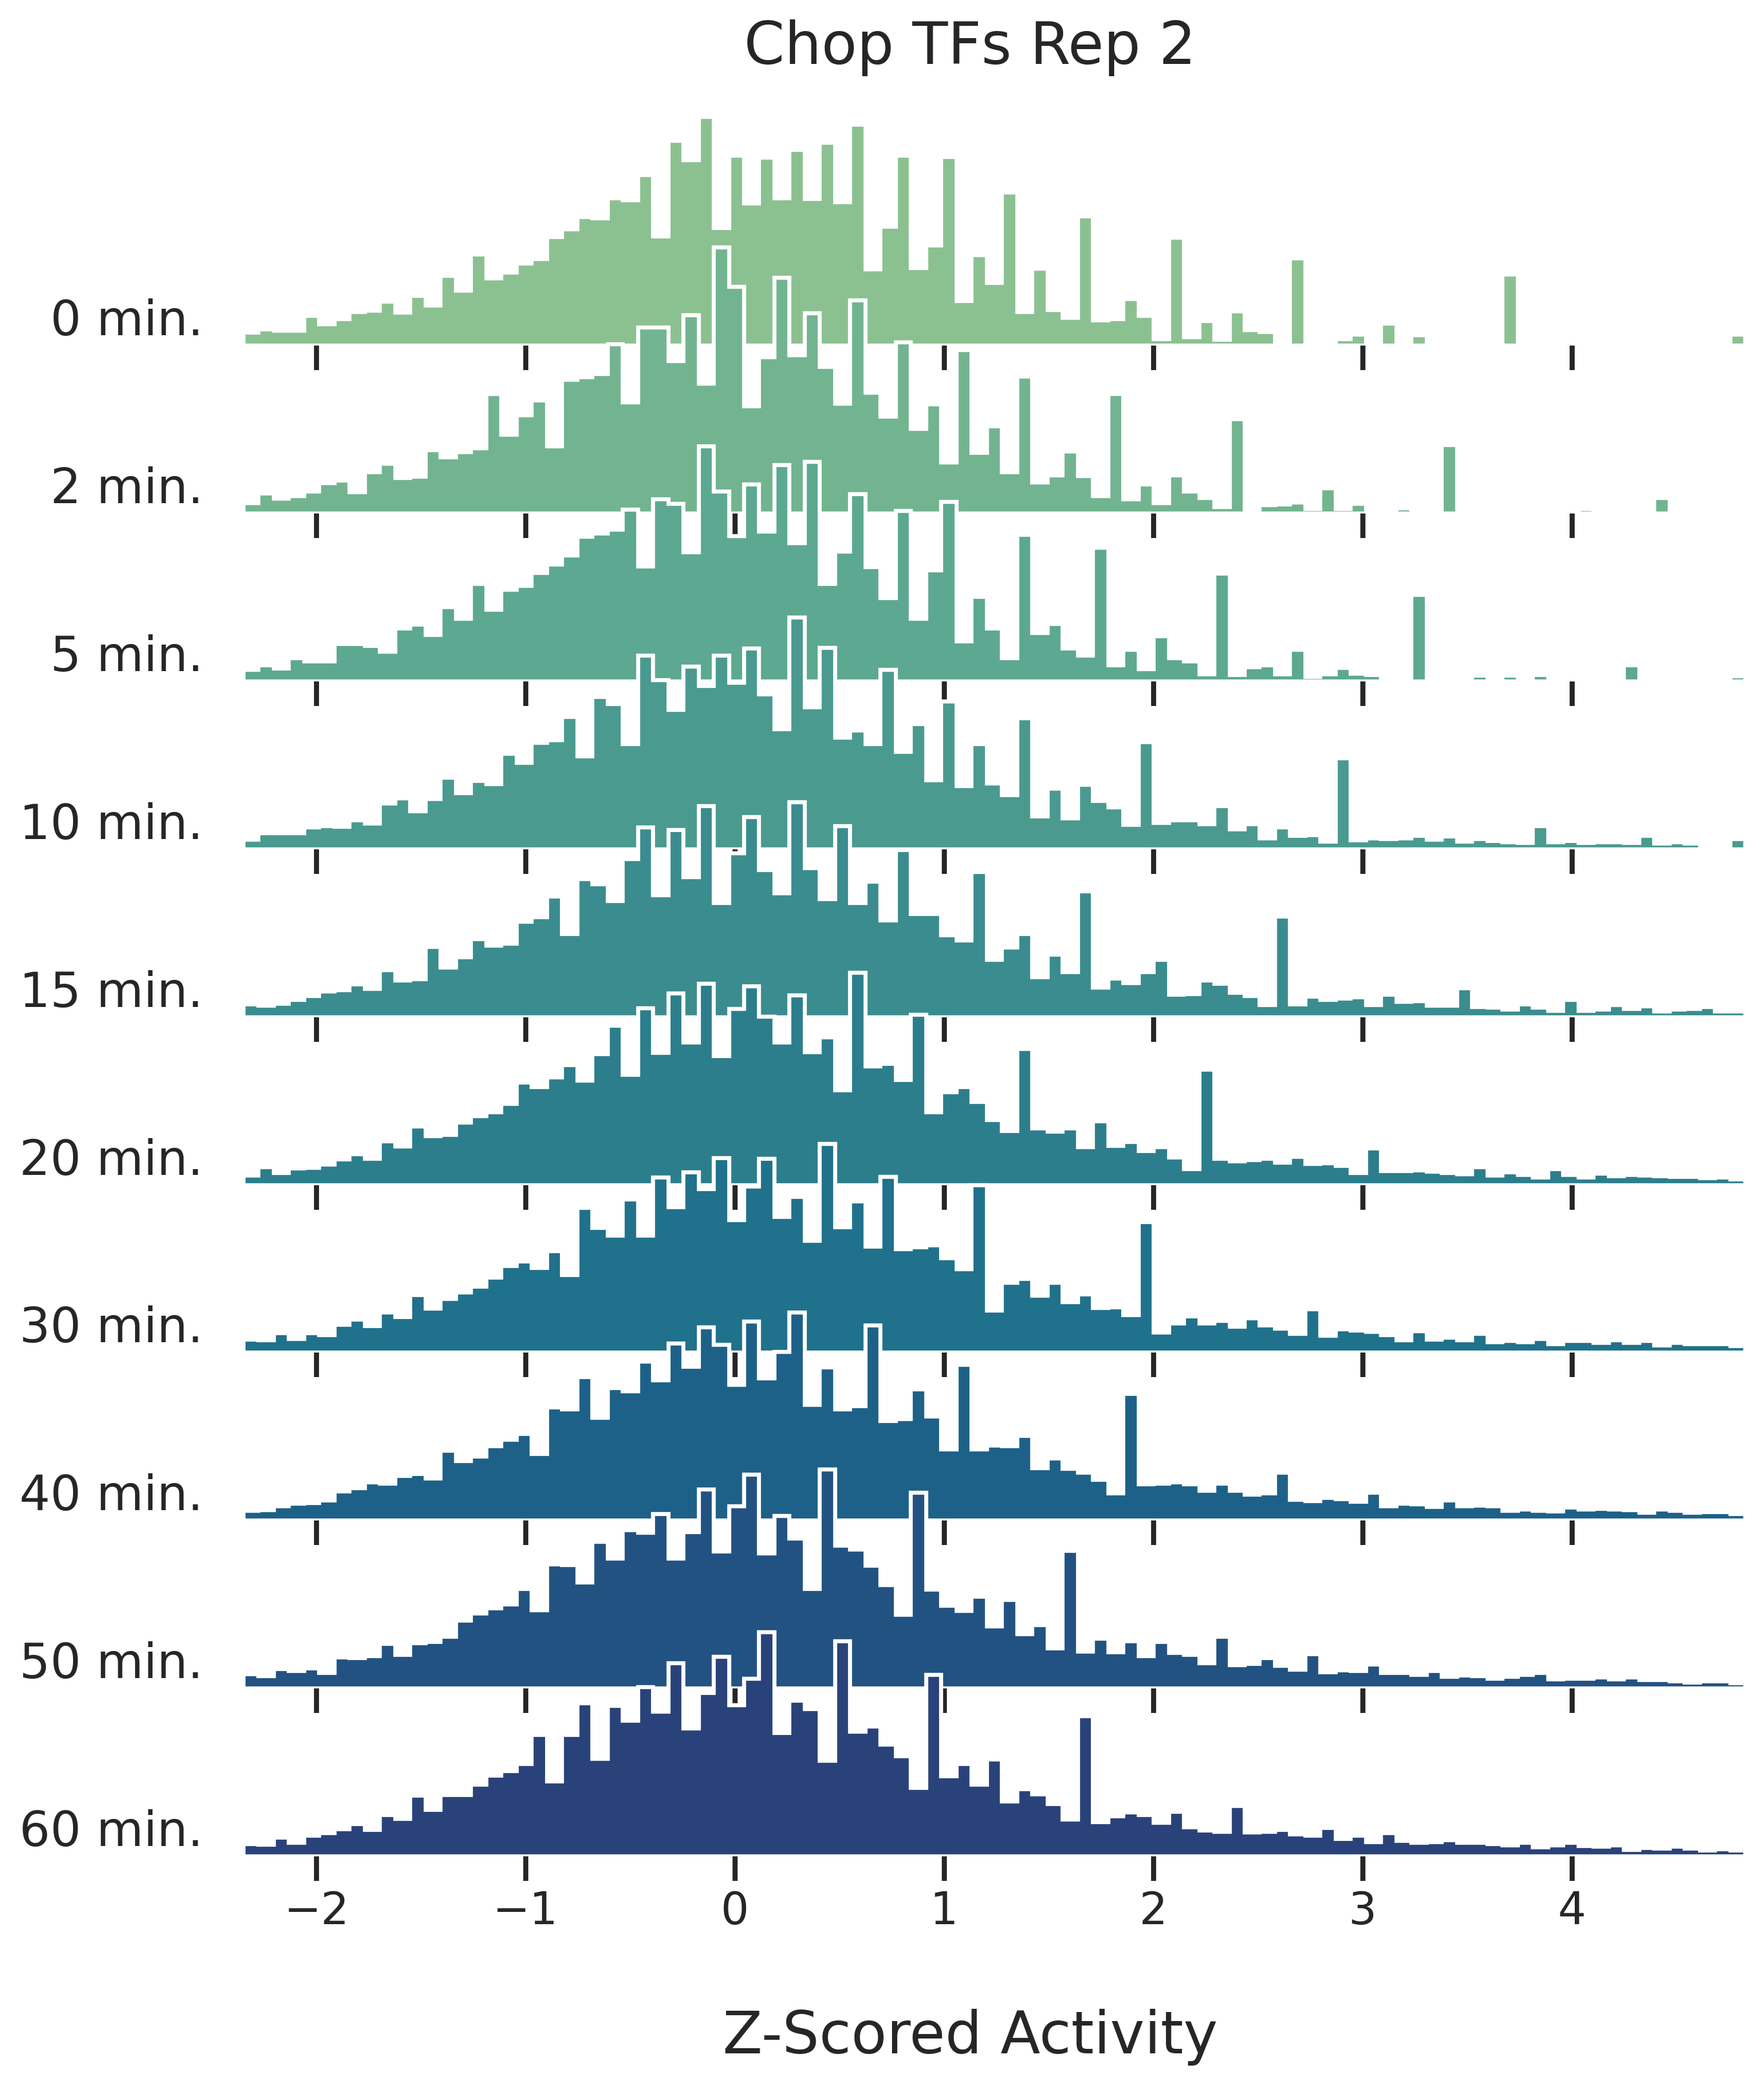

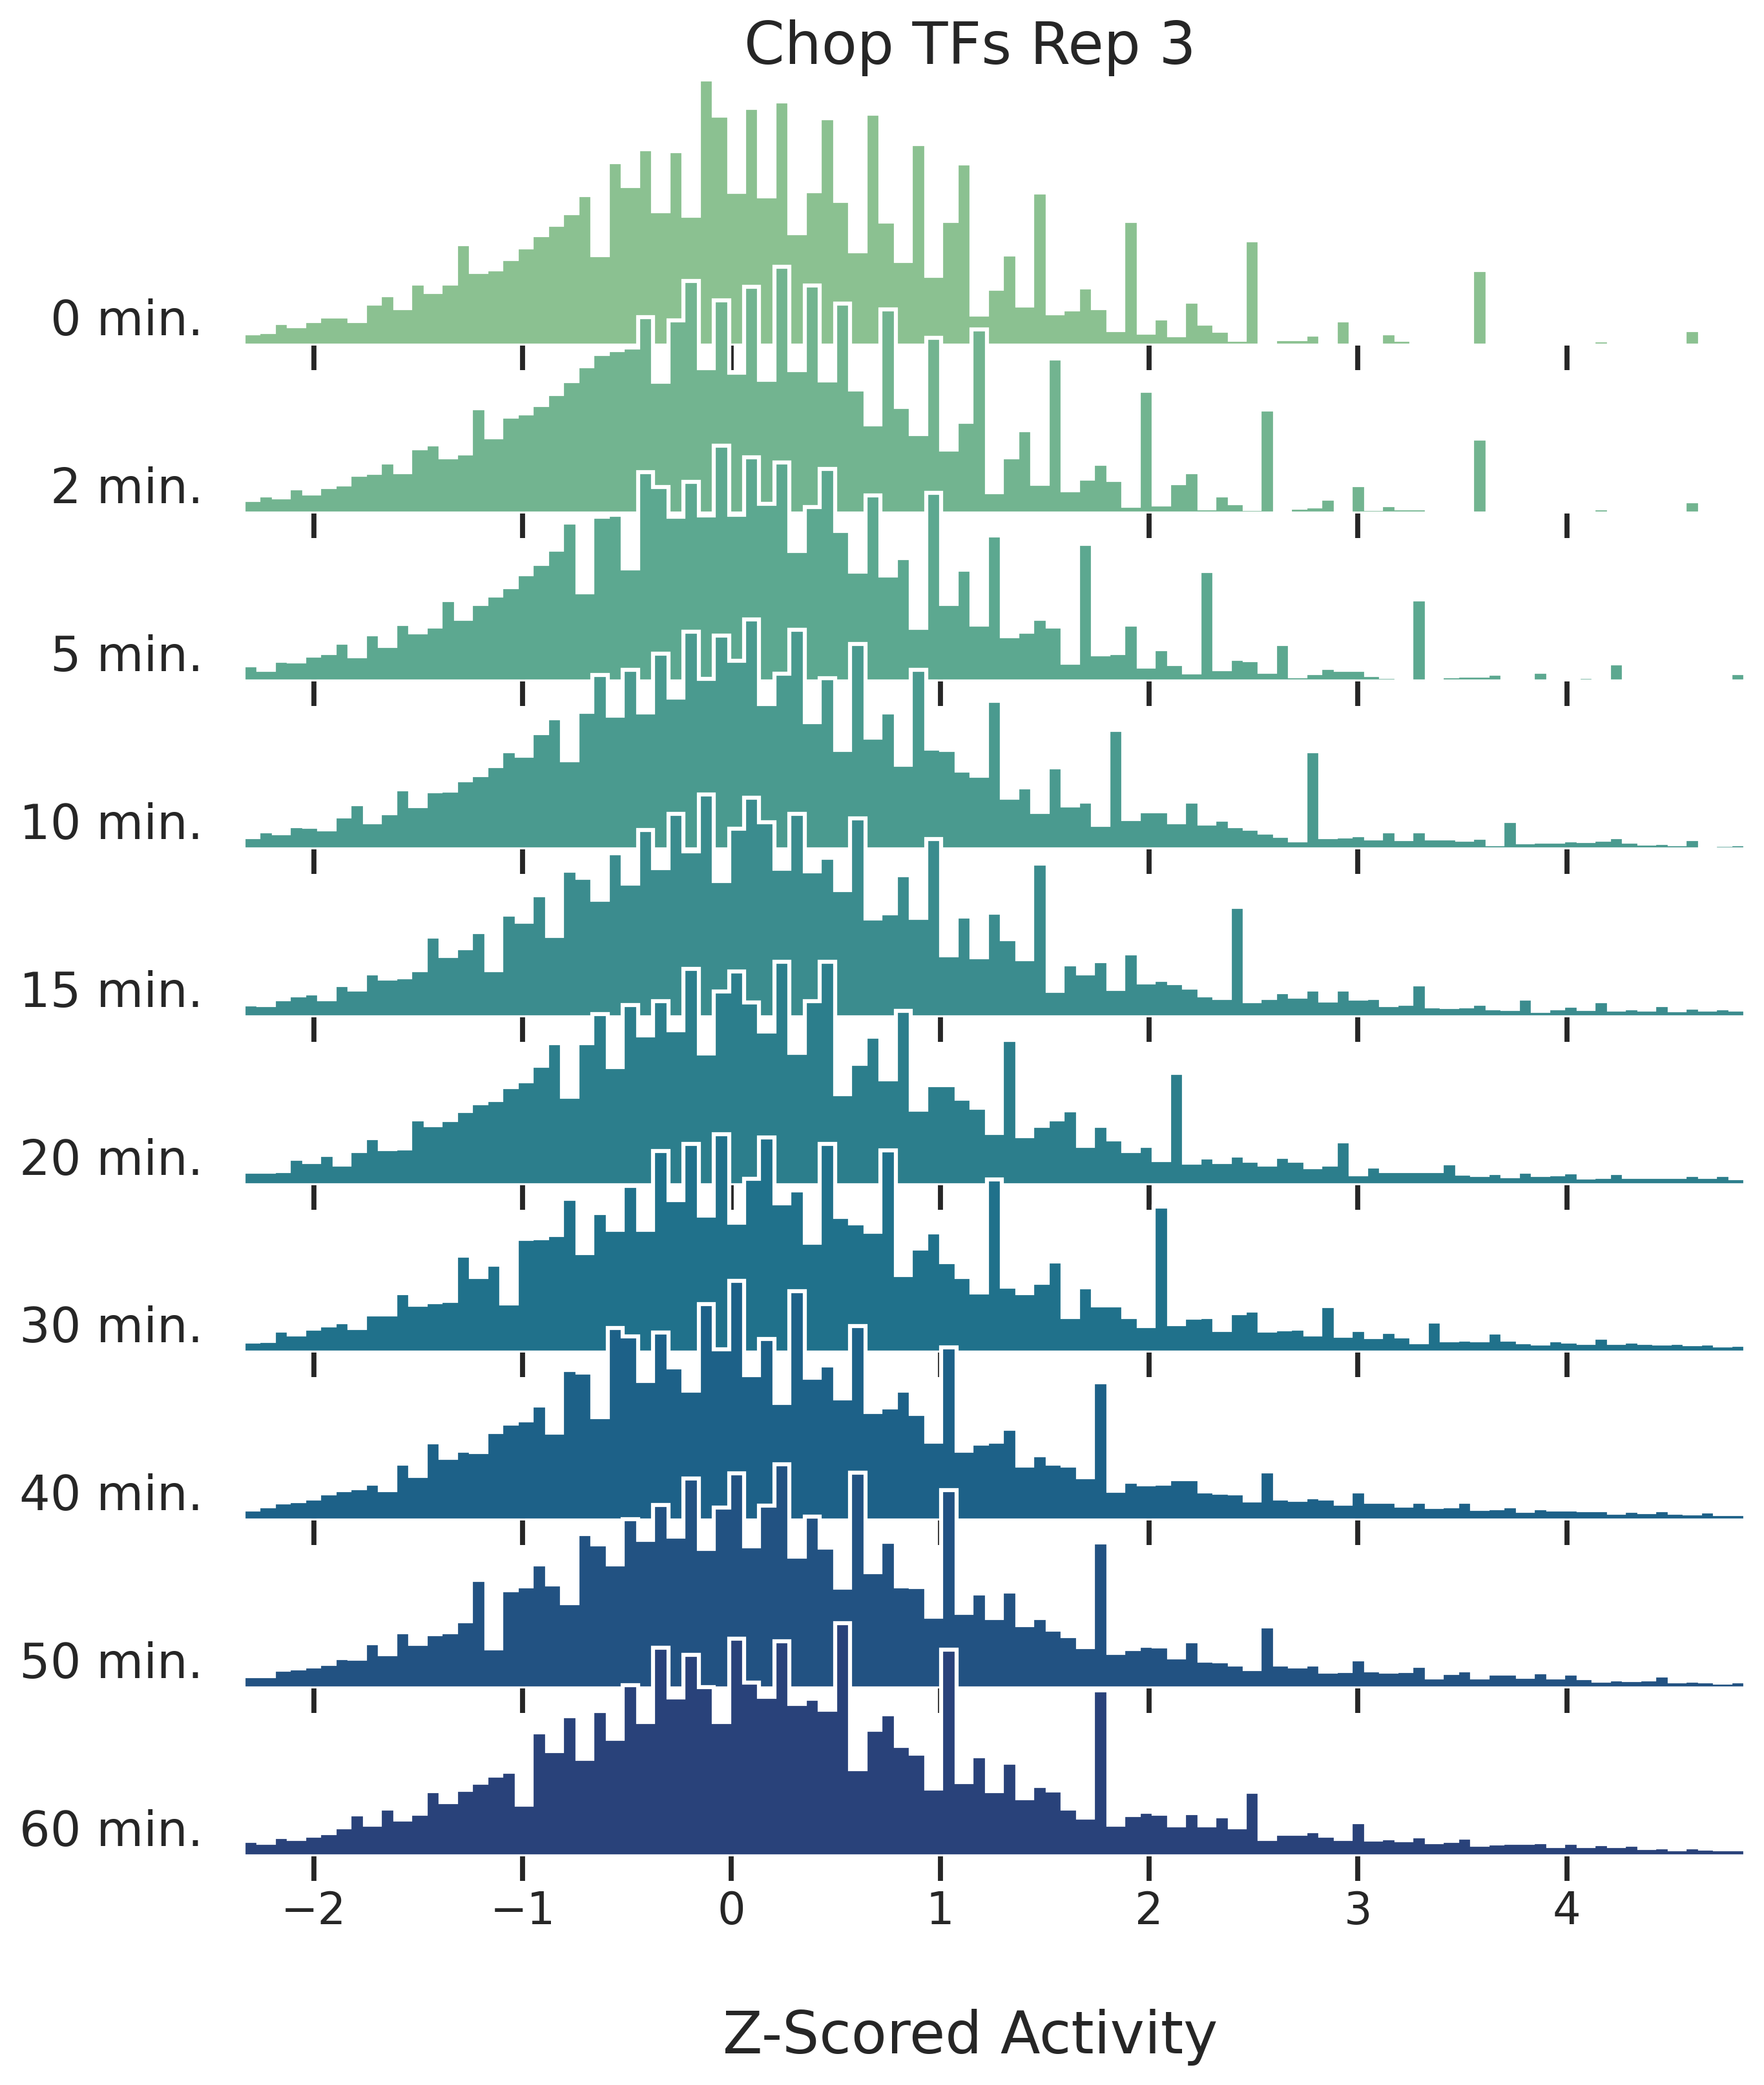

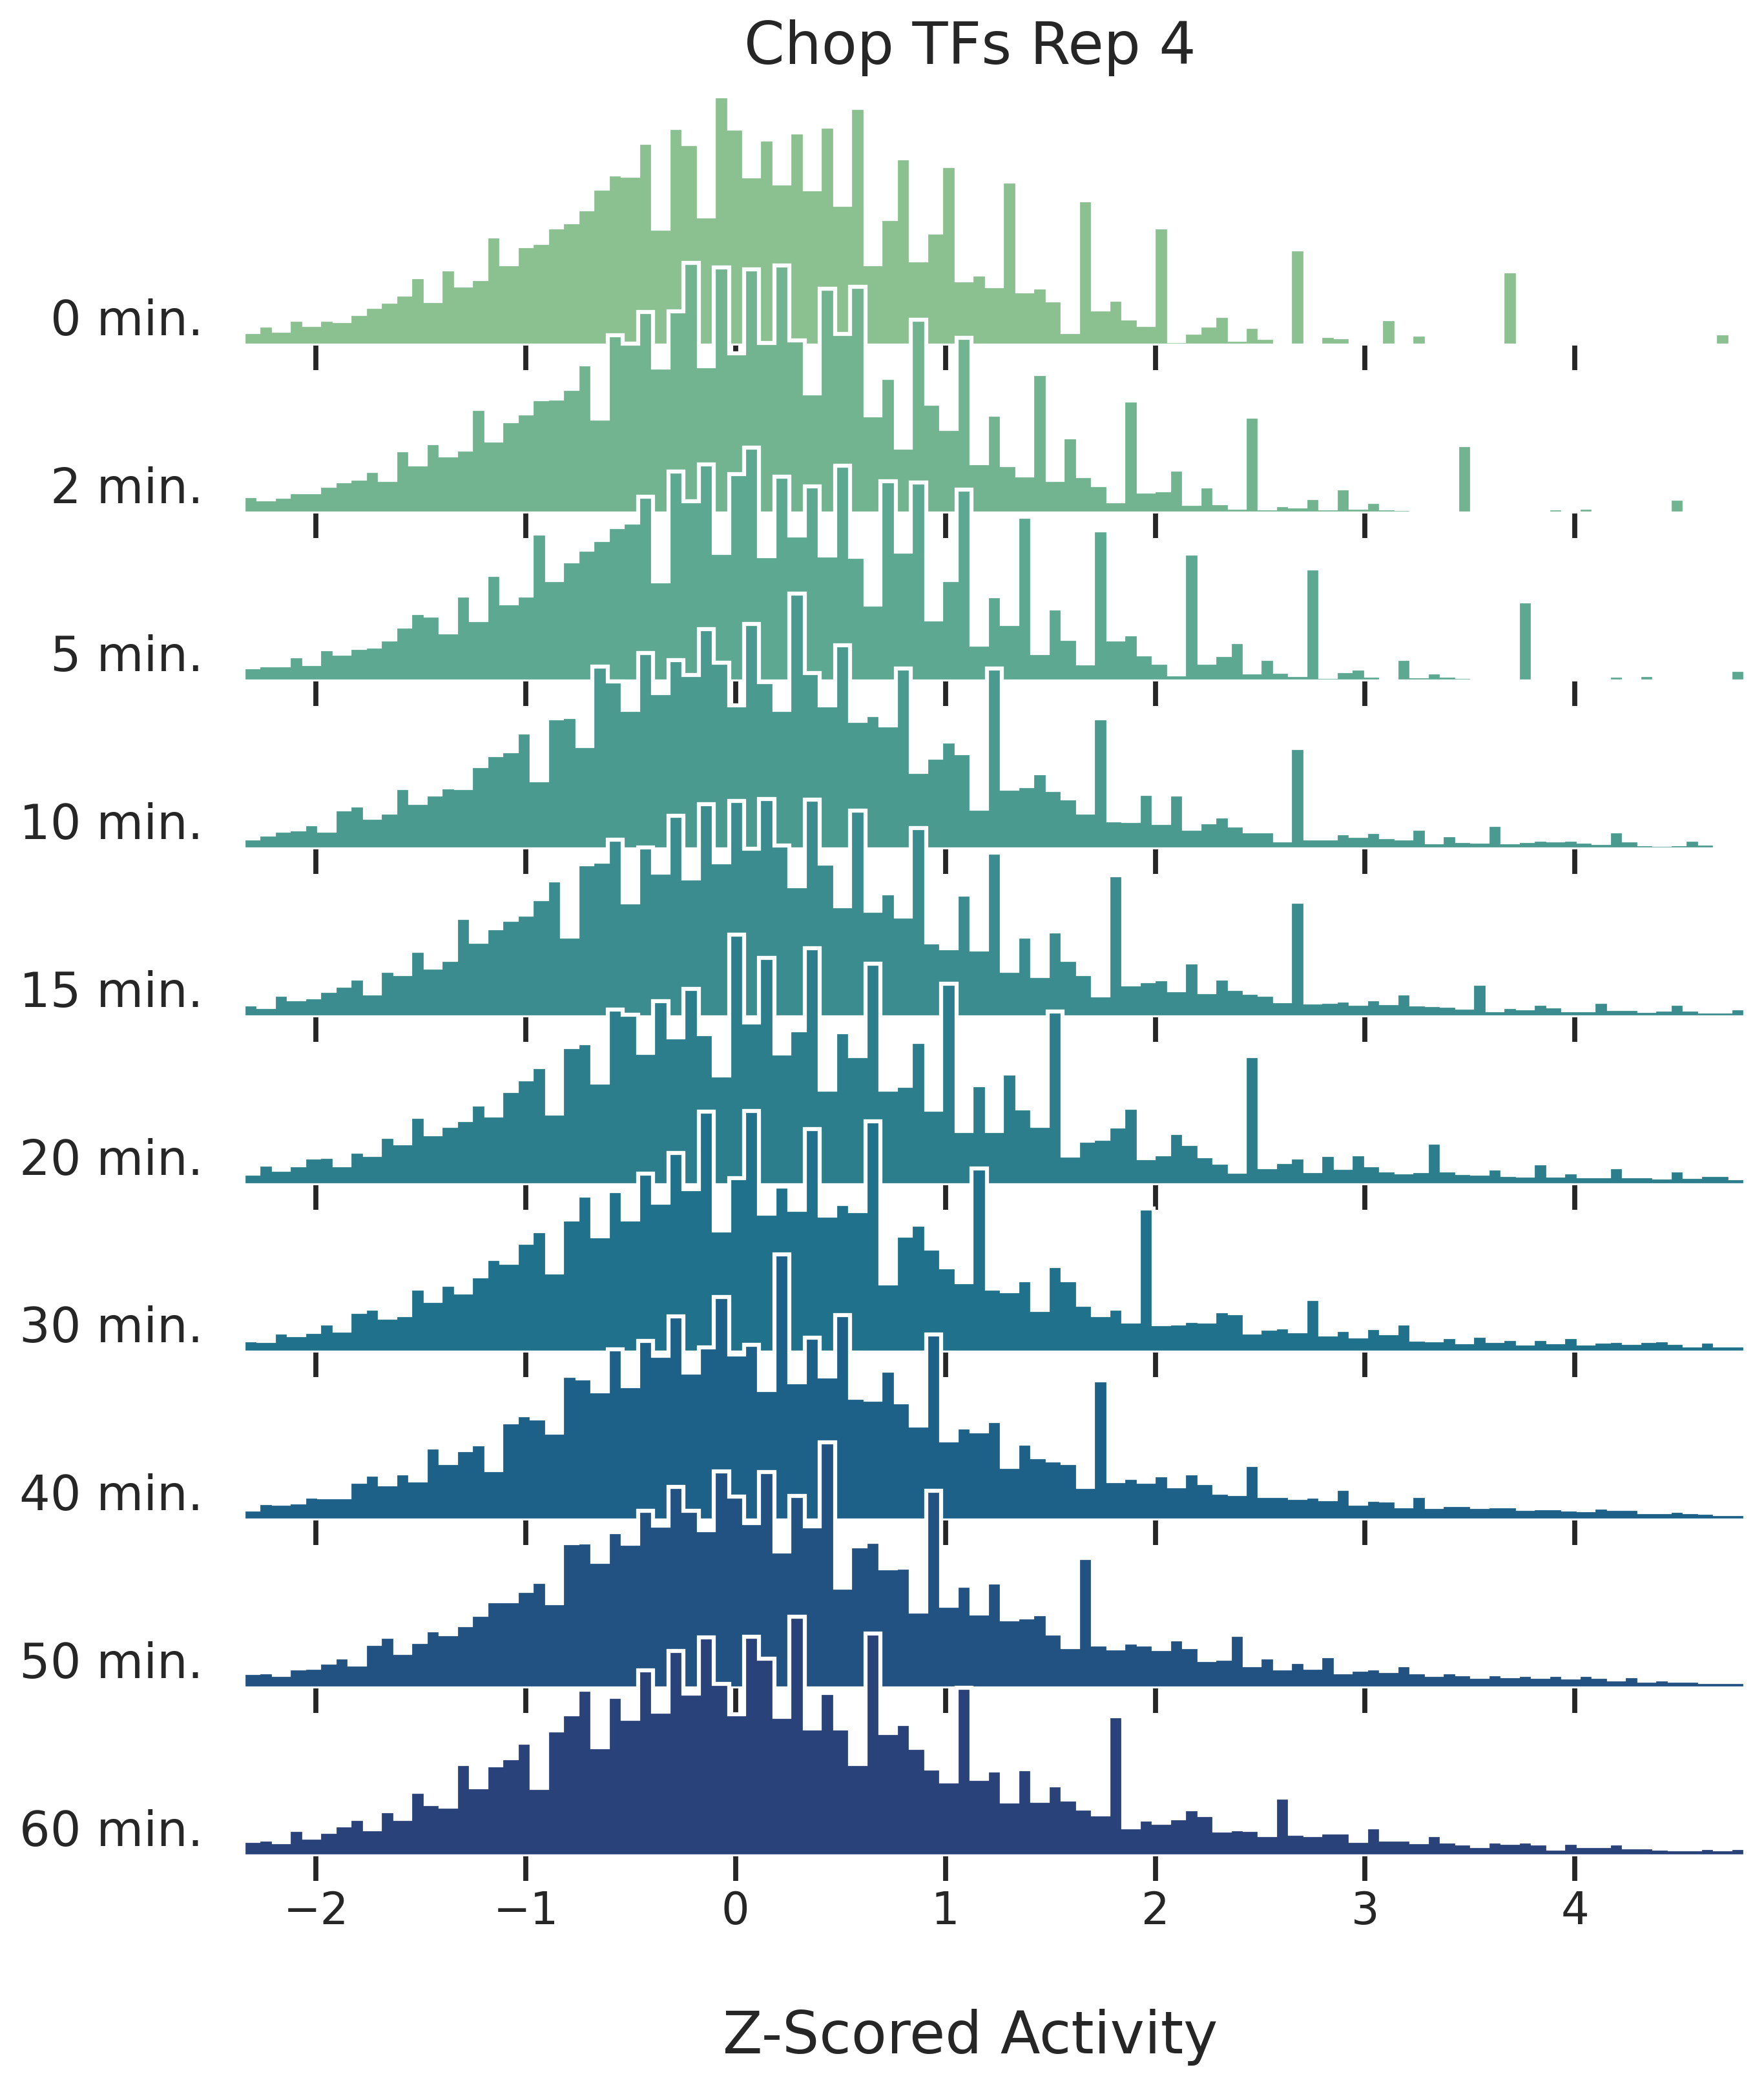

In [179]:
sns.set_style('ticks')
fig, axs = plot_ridge(log_norm_activities_df[log_norm_activities_df["rep"] == 2], "z-score", xlabel = "Z-Scored Activity")
fig.suptitle("Chop TFs Rep 2", y = 0.9)
sns.despine(bottom = True, left = True)

sns.set_style('ticks')
fig, axs = plot_ridge(log_norm_activities_df[log_norm_activities_df["rep"] == 3], "z-score", xlabel = "Z-Scored Activity")
fig.suptitle("Chop TFs Rep 3", y = 0.9)
sns.despine(bottom = True, left = True)

sns.set_style('ticks')
fig, axs = plot_ridge(log_norm_activities_df[log_norm_activities_df["rep"] == 4], "z-score", xlabel = "Z-Scored Activity")
fig.suptitle("Chop TFs Rep 4", y = 0.9)
sns.despine(bottom = True, left = True)

In [155]:
log_norm_activities_df_per_AD = log_norm_activities_df.groupby(["seq", "rep", "time"])[["score", "z-score"]].agg([np.mean, np.std]).reset_index()
log_norm_activities_df_per_AD.columns = ["seq", "rep", "time", "raw_mean", "raw_std", "norm_mean", "norm_std"]
log_norm_activities_df_per_AD

,seq,rep,time,raw_mean,raw_std,norm_mean,norm_std
0,AAAAAAASNSYAIPENELLDEDTMNFISSLKNDLSNISNS,2,15,0.602060,NaN,4.391495,NaN
1,AAAAAAASNSYAIPENELLDEDTMNFISSLKNDLSNISNS,3,30,0.000000,NaN,2.051382,NaN
2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,0,-0.899670,0.077177,0.635362,0.265981
3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,2,-0.738533,0.244102,0.930274,0.829555
4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,5,-0.542113,0.321389,1.549286,1.029220
...,...,...,...,...,...,...,...
472407,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,4,20,-0.954243,NaN,-0.349395,NaN
472408,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,4,30,-1.141674,NaN,-1.069139,NaN
472409,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,4,40,-1.083682,NaN,-1.037561,NaN
472410,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,4,50,-1.063387,NaN,-0.980670,NaN


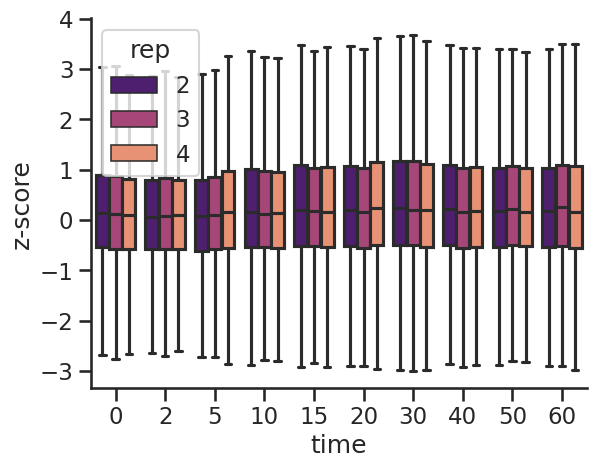

In [156]:
# How does z-score change over time?
sns.boxplot(data=log_norm_activities_df, x="time", y="z-score", hue="rep", showfliers = False, palette = 'magma')
sns.despine()

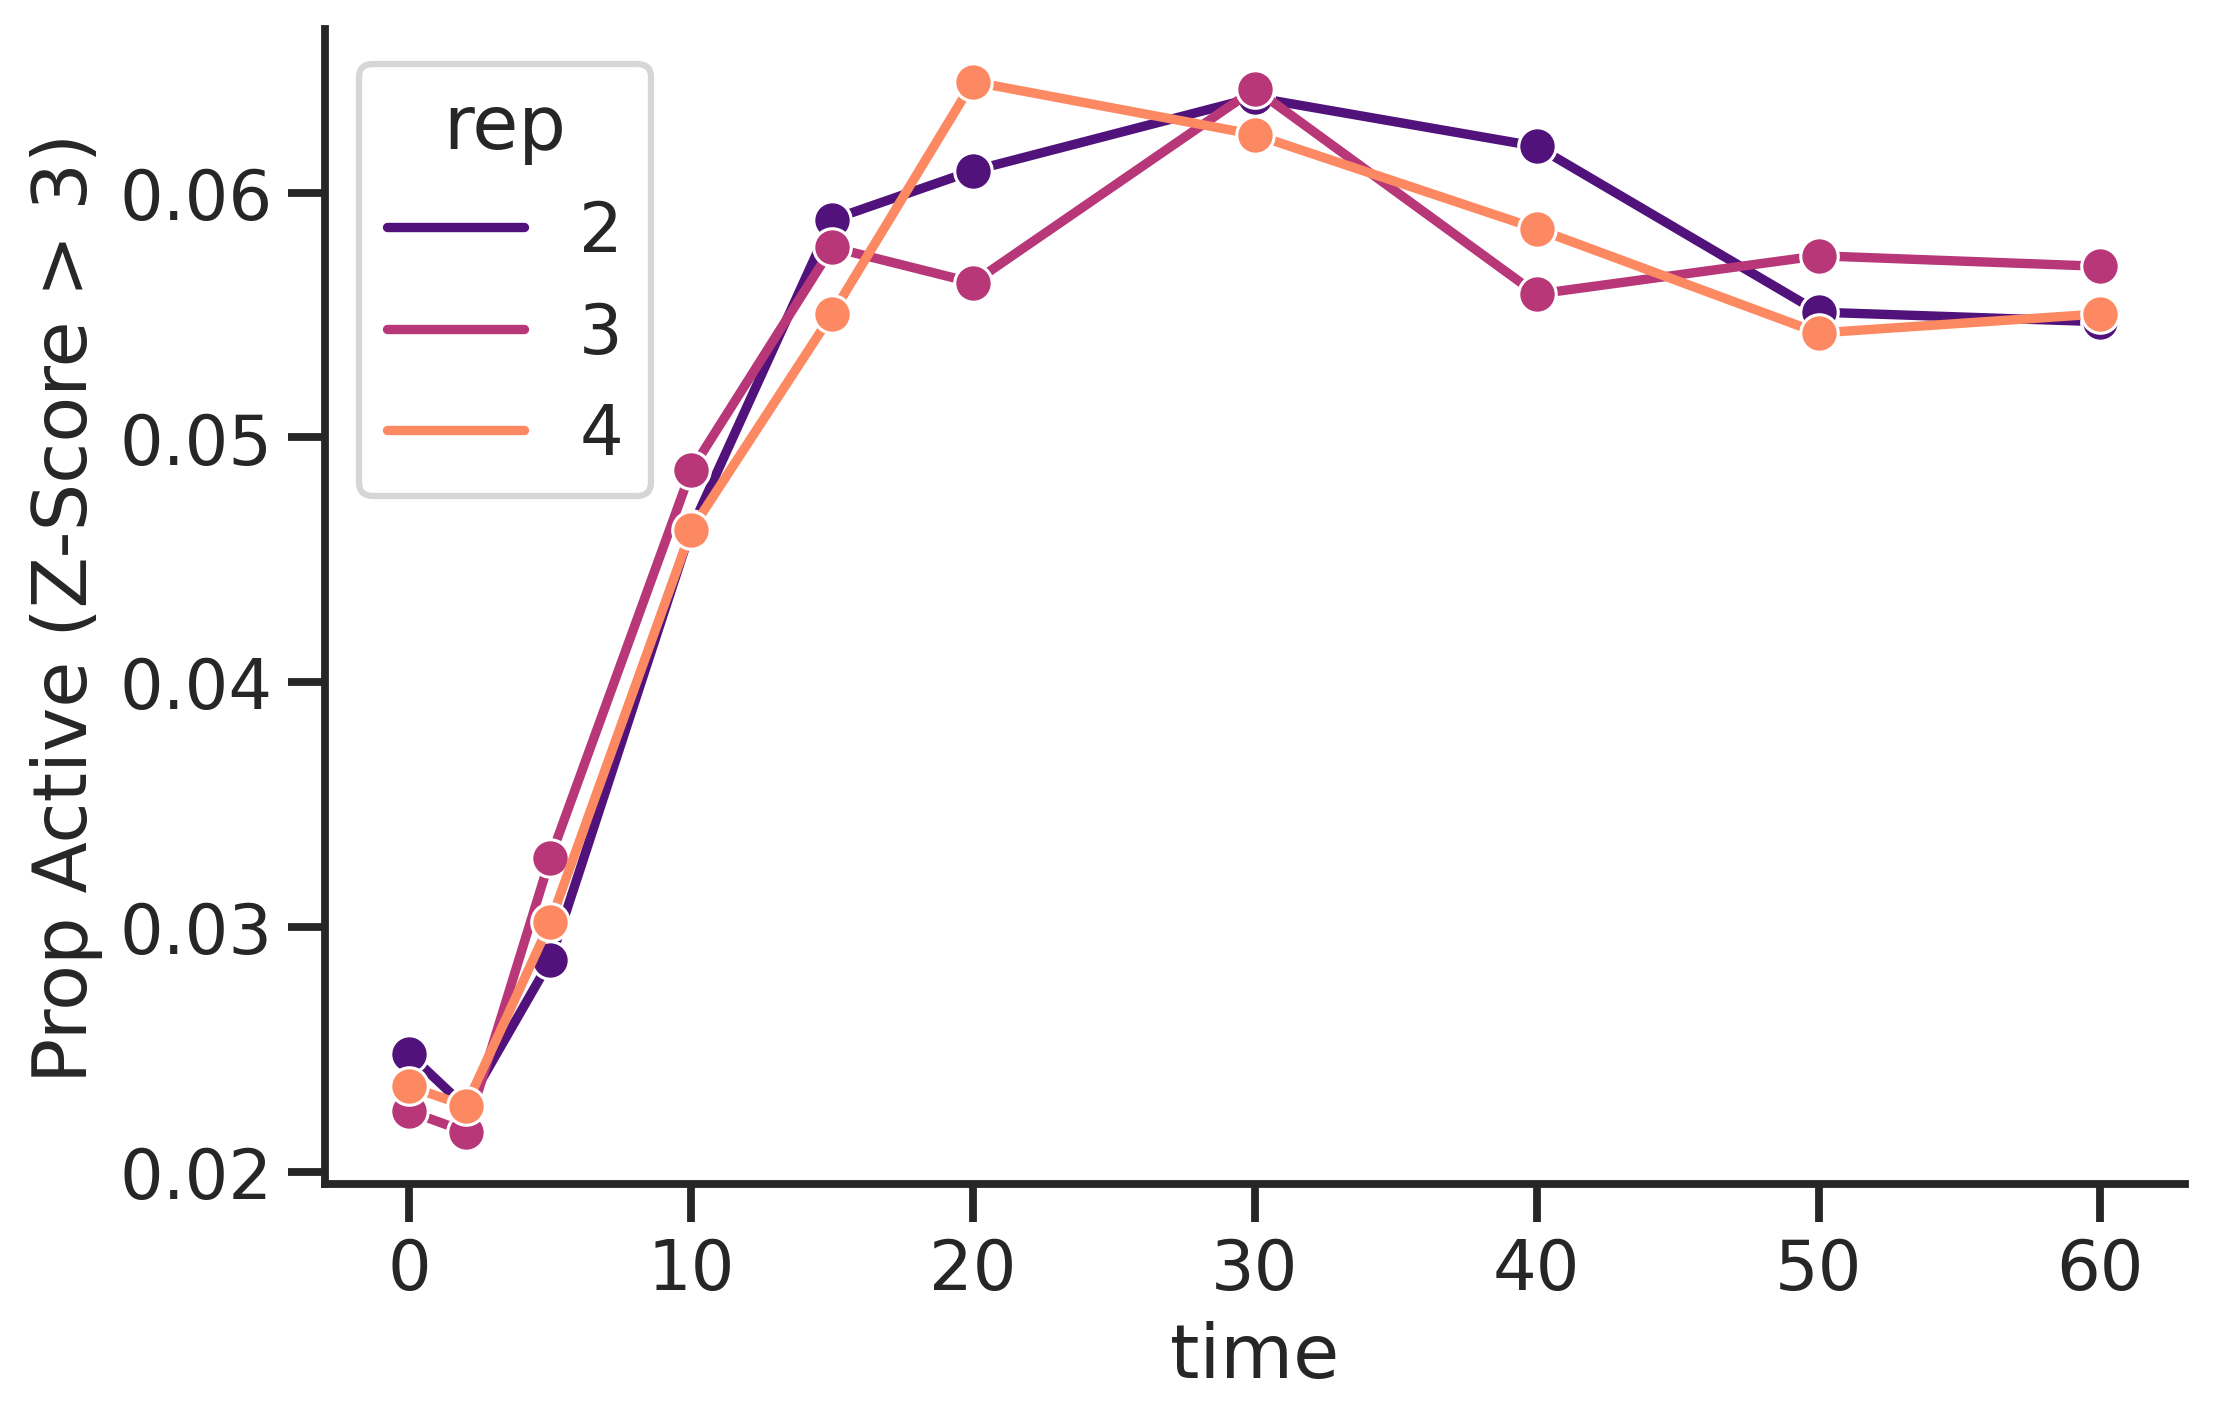

In [167]:
# How does prop active change over time?
prop_active = pd.DataFrame(log_norm_activities_df.groupby(["time","rep"])["active"].agg(np.mean)).reset_index()
sns.set_context('talk')
plt.figure(dpi = 300, figsize = (8,5))
sns.lineplot(data=prop_active, x="time", y="active", hue=prop_active["rep"].astype(str), palette = 'magma', marker = "o")
plt.ylabel("Prop Active (Z-Score > 3)")
sns.despine()

In [158]:
log_norm_activities_df_per_AD

,seq,rep,time,raw_mean,raw_std,norm_mean,norm_std
0,AAAAAAASNSYAIPENELLDEDTMNFISSLKNDLSNISNS,2,15,0.602060,NaN,4.391495,NaN
1,AAAAAAASNSYAIPENELLDEDTMNFISSLKNDLSNISNS,3,30,0.000000,NaN,2.051382,NaN
2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,0,-0.899670,0.077177,0.635362,0.265981
3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,2,-0.738533,0.244102,0.930274,0.829555
4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,5,-0.542113,0.321389,1.549286,1.029220
...,...,...,...,...,...,...,...
472407,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,4,20,-0.954243,NaN,-0.349395,NaN
472408,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,4,30,-1.141674,NaN,-1.069139,NaN
472409,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,4,40,-1.083682,NaN,-1.037561,NaN
472410,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,4,50,-1.063387,NaN,-0.980670,NaN


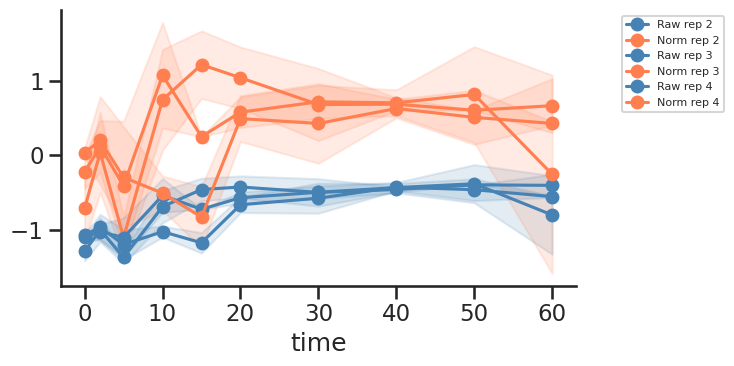

In [159]:
linestyles = ['-', '--', '-.', ':']
raw_color = "steelblue"
norm_color = "coral"

fig, ax = plt.subplots(figsize=(8, 4))

one_AD_normalized = log_norm_activities_df_per_AD[log_norm_activities_df_per_AD["seq"] == "KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ"].copy()
one_AD_normalized["time"] = one_AD_normalized["time"].astype(int)

for rep, group in one_AD_normalized.groupby("rep"):
    group = group.sort_values("time")
    ls = linestyles[rep % len(linestyles)]

    ax.plot(group["time"], group["raw_mean"], marker='o', color=raw_color, label=f"Raw rep {rep}")
    ax.fill_between(group["time"],
                    group["raw_mean"] - group["raw_std"],
                    group["raw_mean"] + group["raw_std"],
                    alpha=0.15, color=raw_color)

    ax.plot(group["time"], group["norm_mean"], marker='o', color=norm_color, label=f"Norm rep {rep}")
    ax.fill_between(group["time"],
                    group["norm_mean"] - group["norm_std"],
                    group["norm_mean"] + group["norm_std"],
                    alpha=0.15, color=norm_color)

ax.set_xlabel("time")
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1), fontsize=8)
sns.despine()
plt.tight_layout()
plt.show()

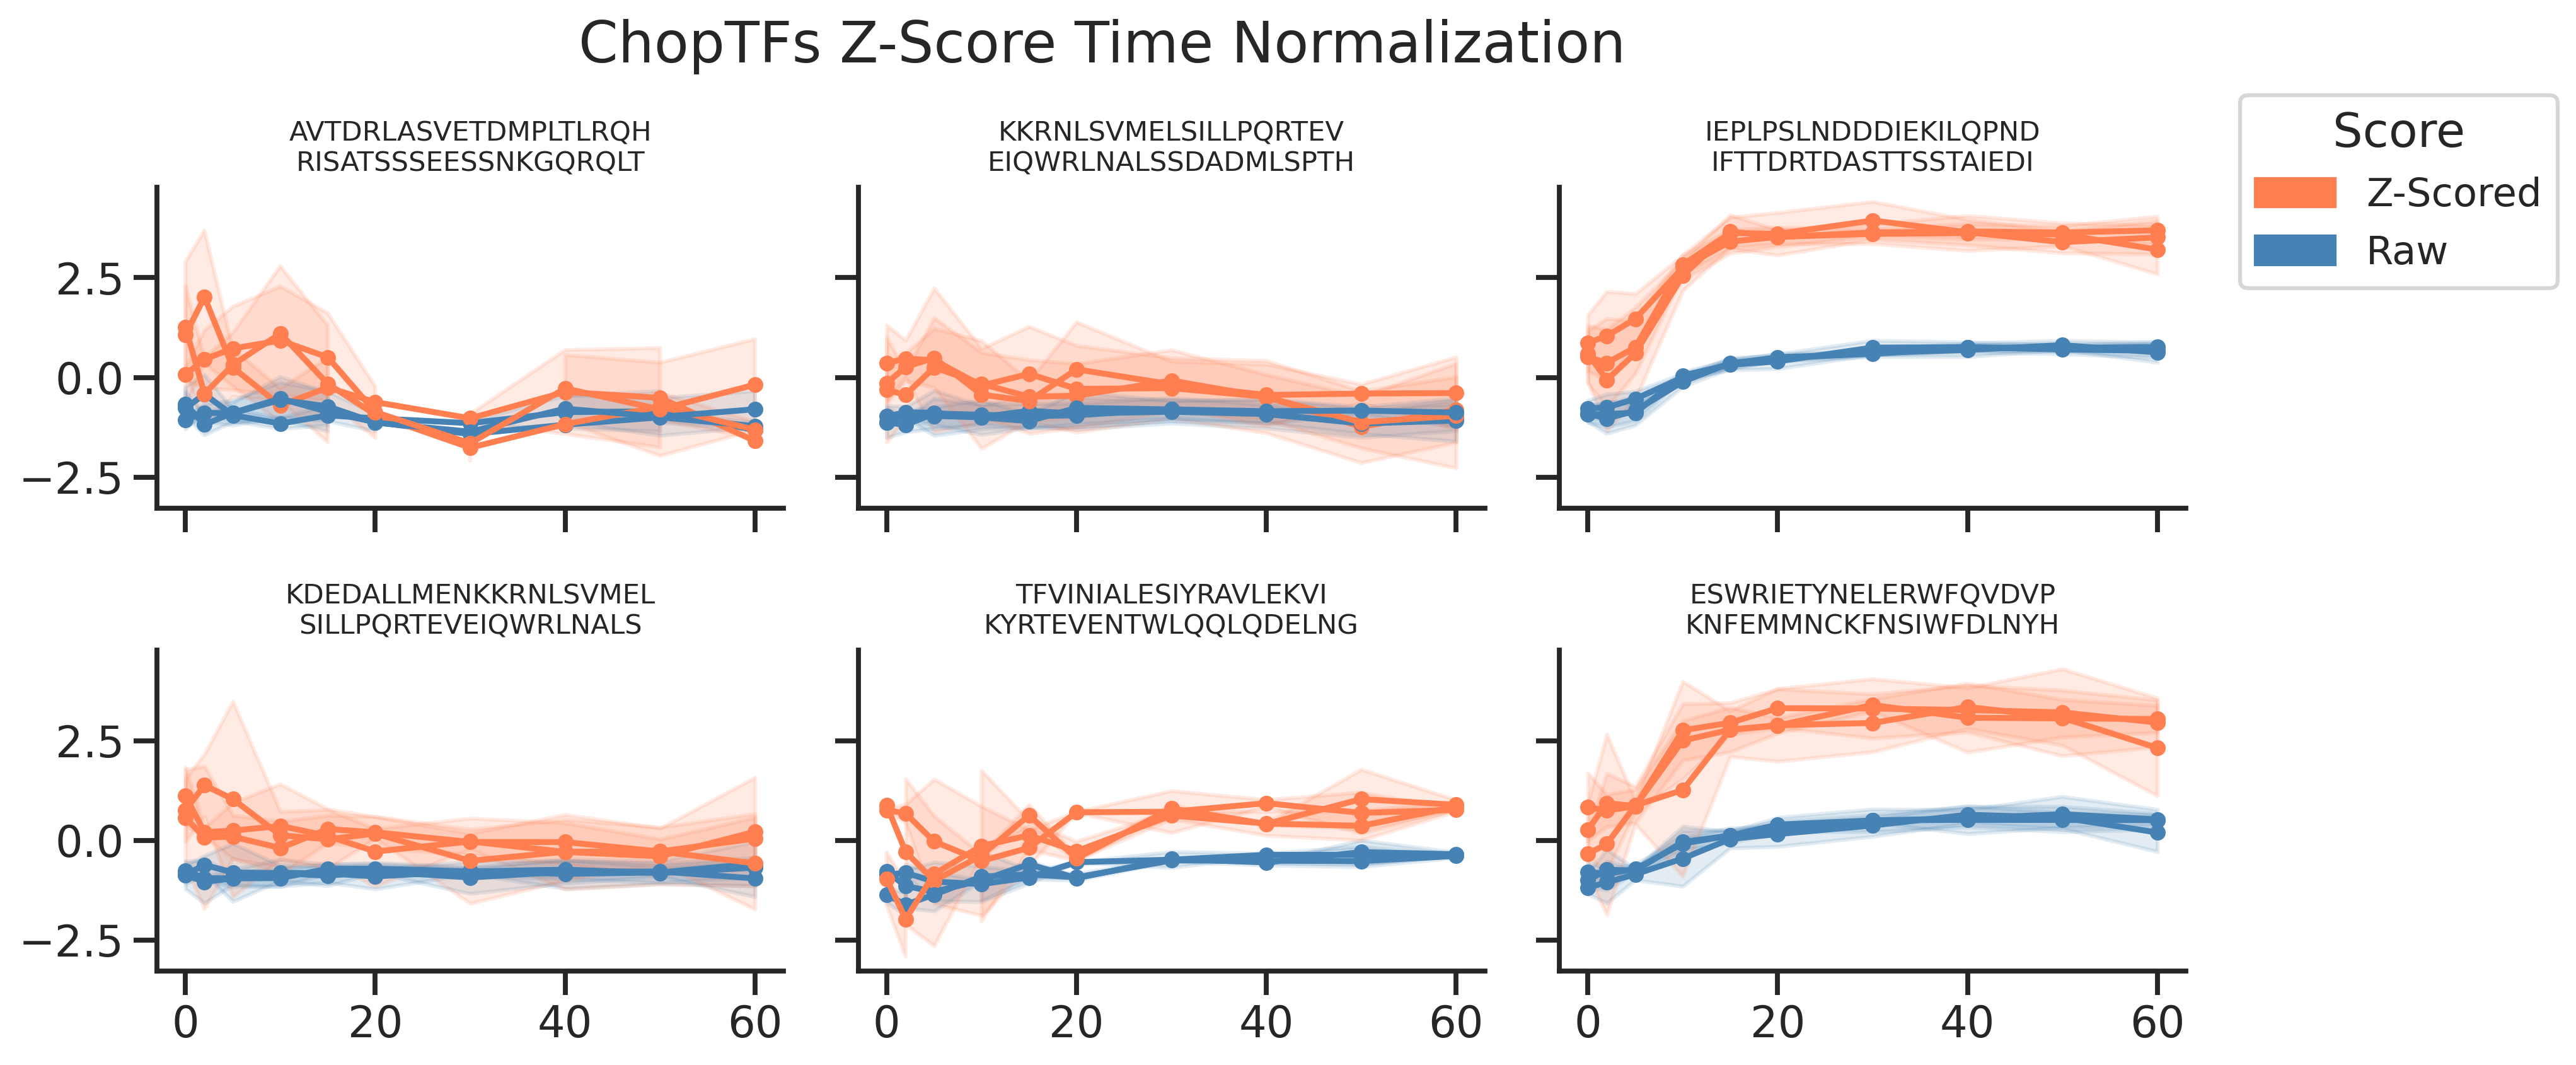

In [180]:
from matplotlib.patches import Patch

pythonlinestyles = ['-', '--', '-.', ':']
raw_color = "steelblue"
norm_color = "coral"

sampled_ADs = pd.Series(log_norm_activities_df_per_AD.dropna()["seq"].unique()).sample(6, random_state=7)
ncols = 3
nrows = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3),sharex = True, sharey = True, dpi = 300)
axes = axes.flatten()

for i, AD in enumerate(sampled_ADs):
    ax = axes[i]
    one_AD_normalized = log_norm_activities_df_per_AD[log_norm_activities_df_per_AD["seq"] == AD].copy()
    one_AD_normalized["time"] = one_AD_normalized["time"].astype(int)

    for rep, group in one_AD_normalized.groupby("rep"):
        group = group.sort_values("time")
        ls = linestyles[rep % len(linestyles)]

        ax.plot(group["time"], group["raw_mean"], marker='o', color=raw_color, markersize = 5)
        ax.fill_between(group["time"],
                        group["raw_mean"] - group["raw_std"],
                        group["raw_mean"] + group["raw_std"],
                        alpha=0.15, color=raw_color)

        ax.plot(group["time"], group["norm_mean"], marker='o', color=norm_color, markersize = 5)
        ax.fill_between(group["time"],
                        group["norm_mean"] - group["norm_std"],
                        group["norm_mean"] + group["norm_std"],
                        alpha=0.15, color=norm_color)

    ax.set_title(AD[:20] + "\n" + AD[20:], fontsize='xx-small')
    #ax.set_xlabel("time", fontsize=8)
    sns.despine(ax=ax)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

legend_handles = [
    Patch(color=norm_color, label="Z-Scored"),
    Patch(color=raw_color, label="Raw"),
]
fig.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(1.15, 0.9), fontsize='small', title = "Score")
fig.suptitle("ChopTFs Z-Score Time Normalization", y = 0.95)

plt.tight_layout()
plt.show()

In [26]:
log_norm_activities_df_per_AD

NameError: name 'log_norm_activities_df_per_AD' is not defined

# What about empty AD results?

In [14]:
empty_AD_trebl_results = pd.read_csv("../../../output/ChopTFs_pipeline_step1_empty_ADs/empty_AD_trebl_results.csv")
empty_AD_trebl_results

,Unnamed: 0,AD_BC,RPTR_BC,rep,time,count_directional_AD,count_directional_RT,activity
0,0,AAAAAATAATA,GAATAAGGAAAAAG,2,0,34,1,-3.526361
1,1,AAAAAATAATA,GAATAAGGAAAAAG,2,15,33,1,-3.496508
2,2,AAAAAATAATA,GAATAAGGAAAAAG,2,20,44,6,-1.992430
3,3,AAAAAATAATA,GAATAAGGAAAAAG,2,30,51,2,-3.238678
4,4,AAAAAATAATA,GAATAAGGAAAAAG,2,40,29,7,-1.421386
...,...,...,...,...,...,...,...,...
12211,12211,TTTTGGATCTT,ATAAGGGTGTCGCC,3,20,1,37,3.610918
12212,12212,TTTTGGATCTT,ATAAGGGTGTCGCC,3,50,1,22,3.091042
12213,12213,TTTTGGATCTT,ATAAGGGTGTCGCC,4,5,1,6,1.791759
12214,12214,TTTTTGTCCGT,ATGCACGGAGTGAA,4,0,1,1,0.000000


100%|██████████| 10/10 [00:01<00:00,  6.14it/s]


Text(0.5, 0.9, 'Chop TFs Rep 2')

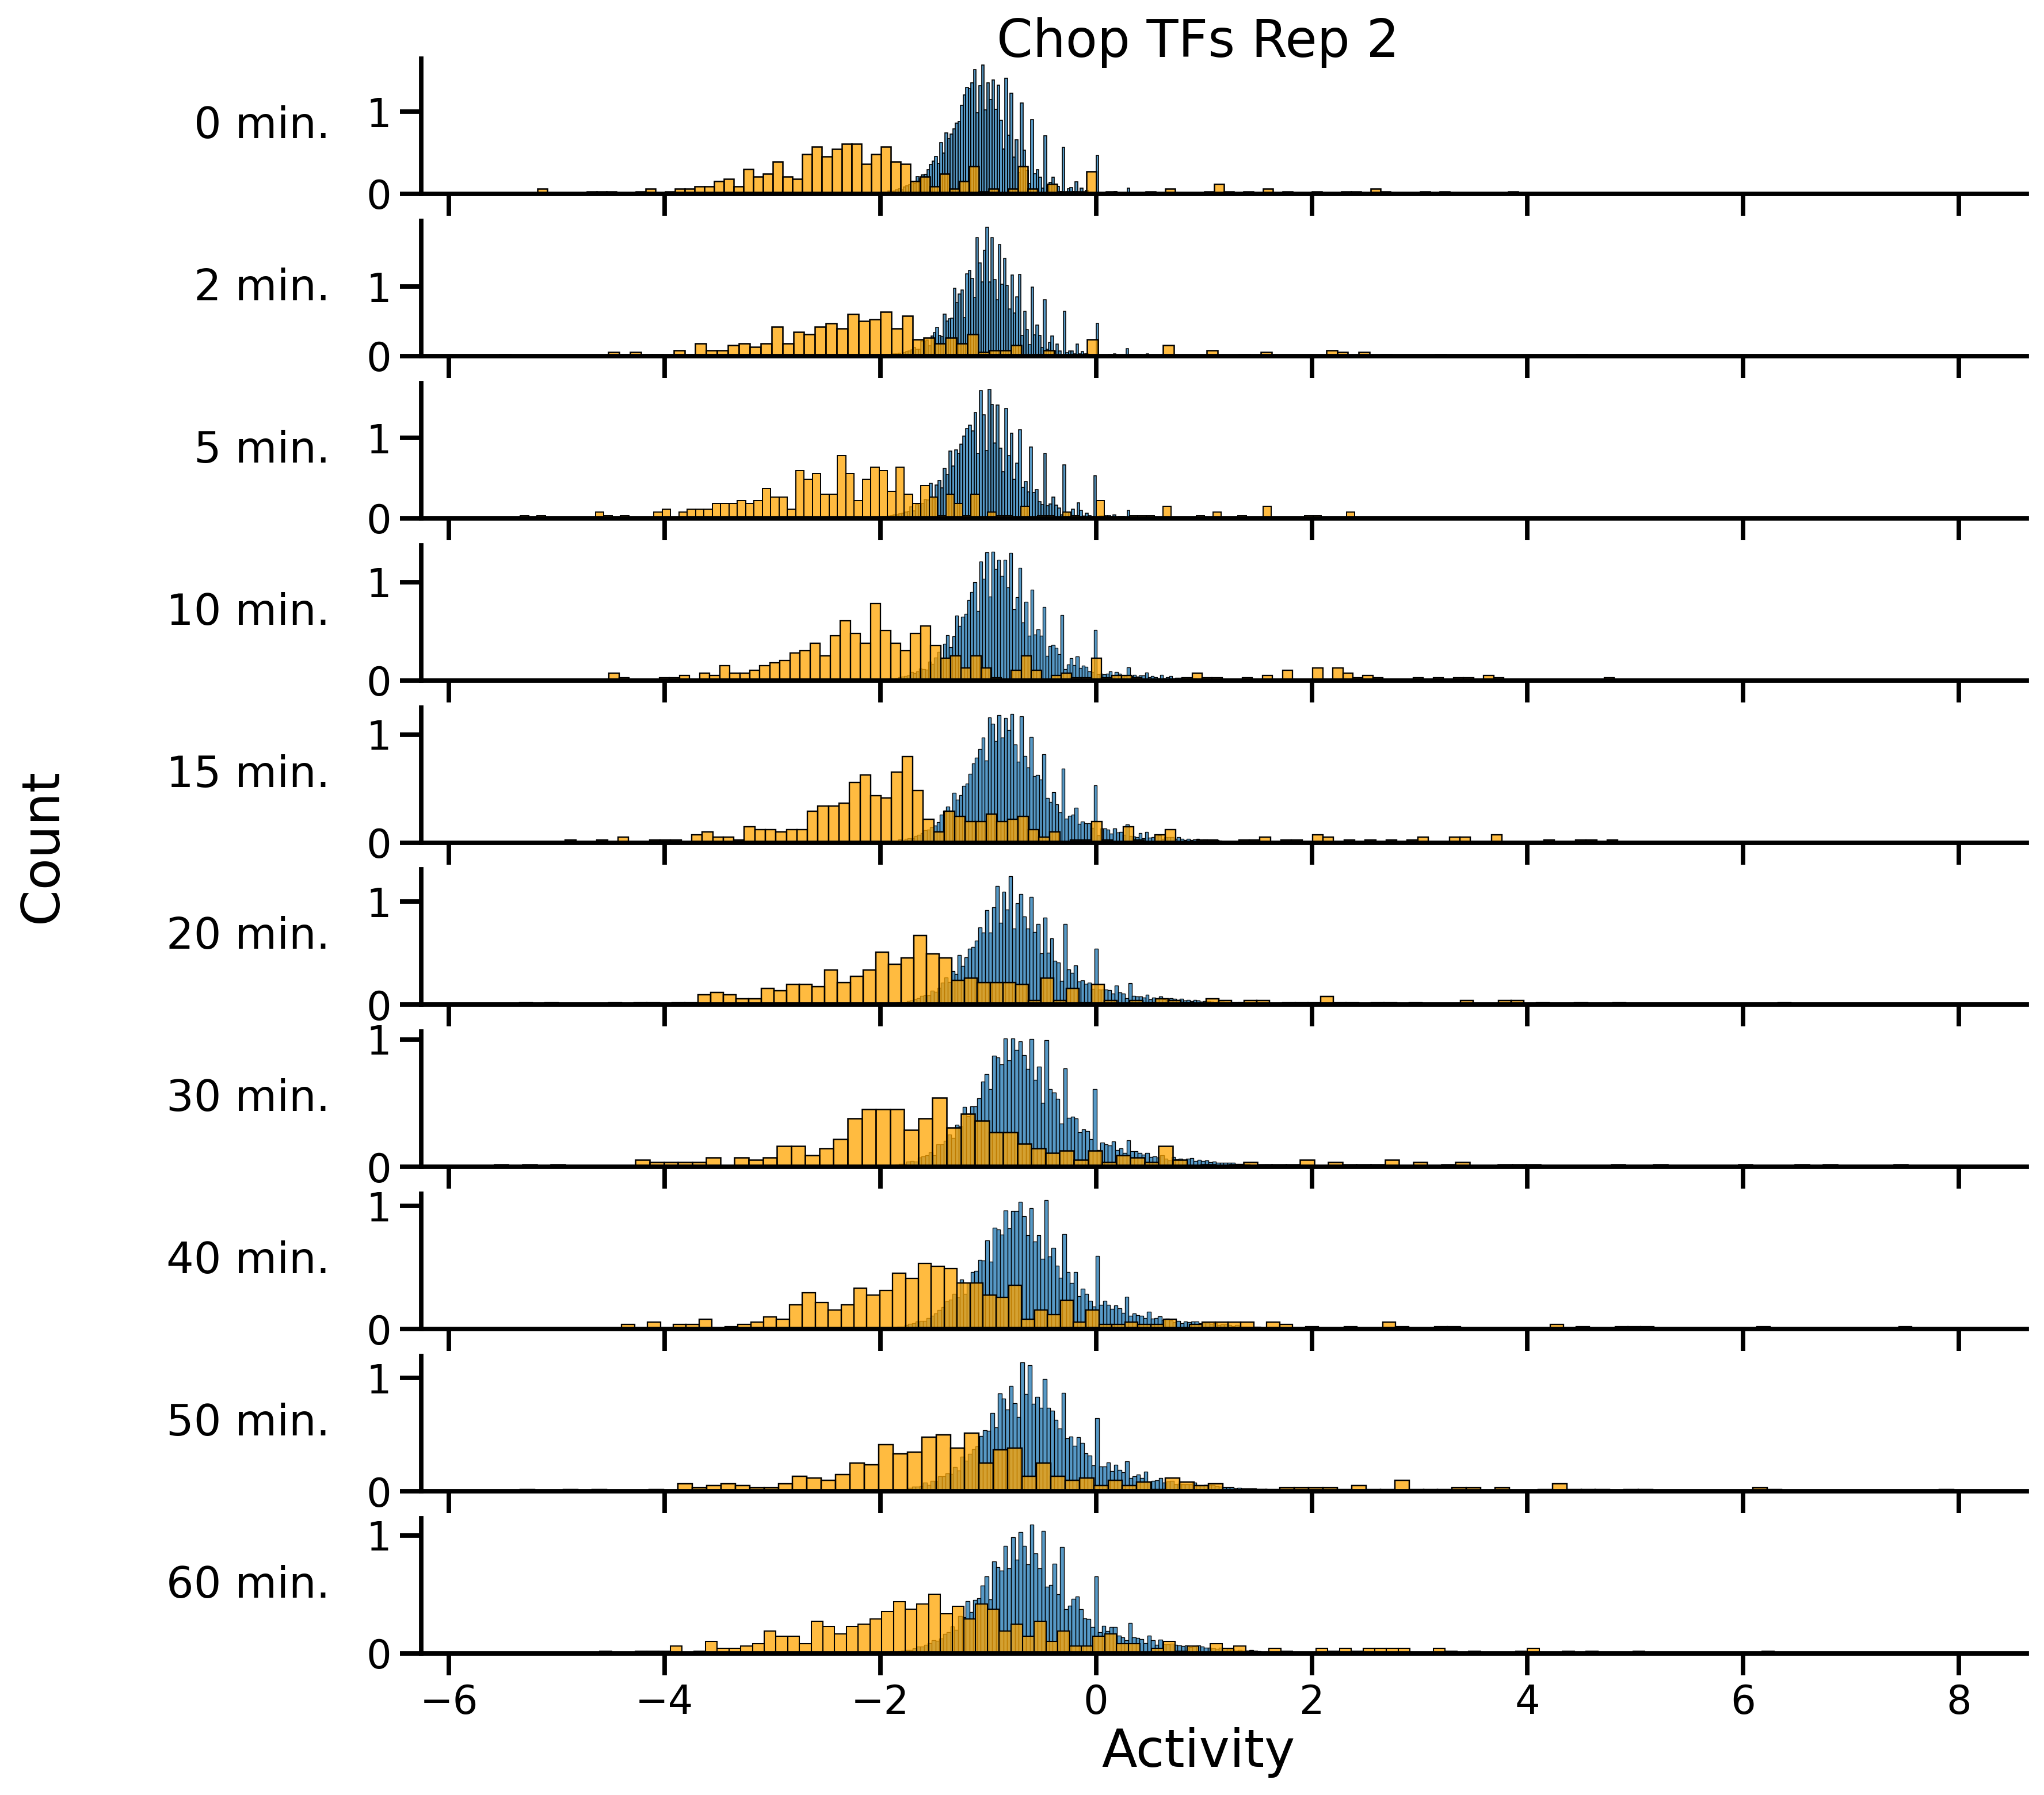

In [17]:
fig,axs = plot_hists_over_time(activities_rep2)

times = np.array(empty_AD_trebl_results["time"].drop_duplicates().sort_values())
    
for i in tqdm.tqdm(range(len(times))):
    sns.histplot(data = empty_AD_trebl_results[(empty_AD_trebl_results["rep"] == 2) & (empty_AD_trebl_results["time"] == times[i])], 
                 x = "activity", 
                 ax = axs[i],
                stat = 'density', color = 'orange', bins = 100, label = "Empty ADs")
    axs[i].set_xlabel("")
    
fig.suptitle("Chop TFs Rep 2", y = 0.9)

100%|██████████| 10/10 [00:00<00:00, 11.59it/s]


Text(0.5, 0.9, 'Chop TFs Rep 3')

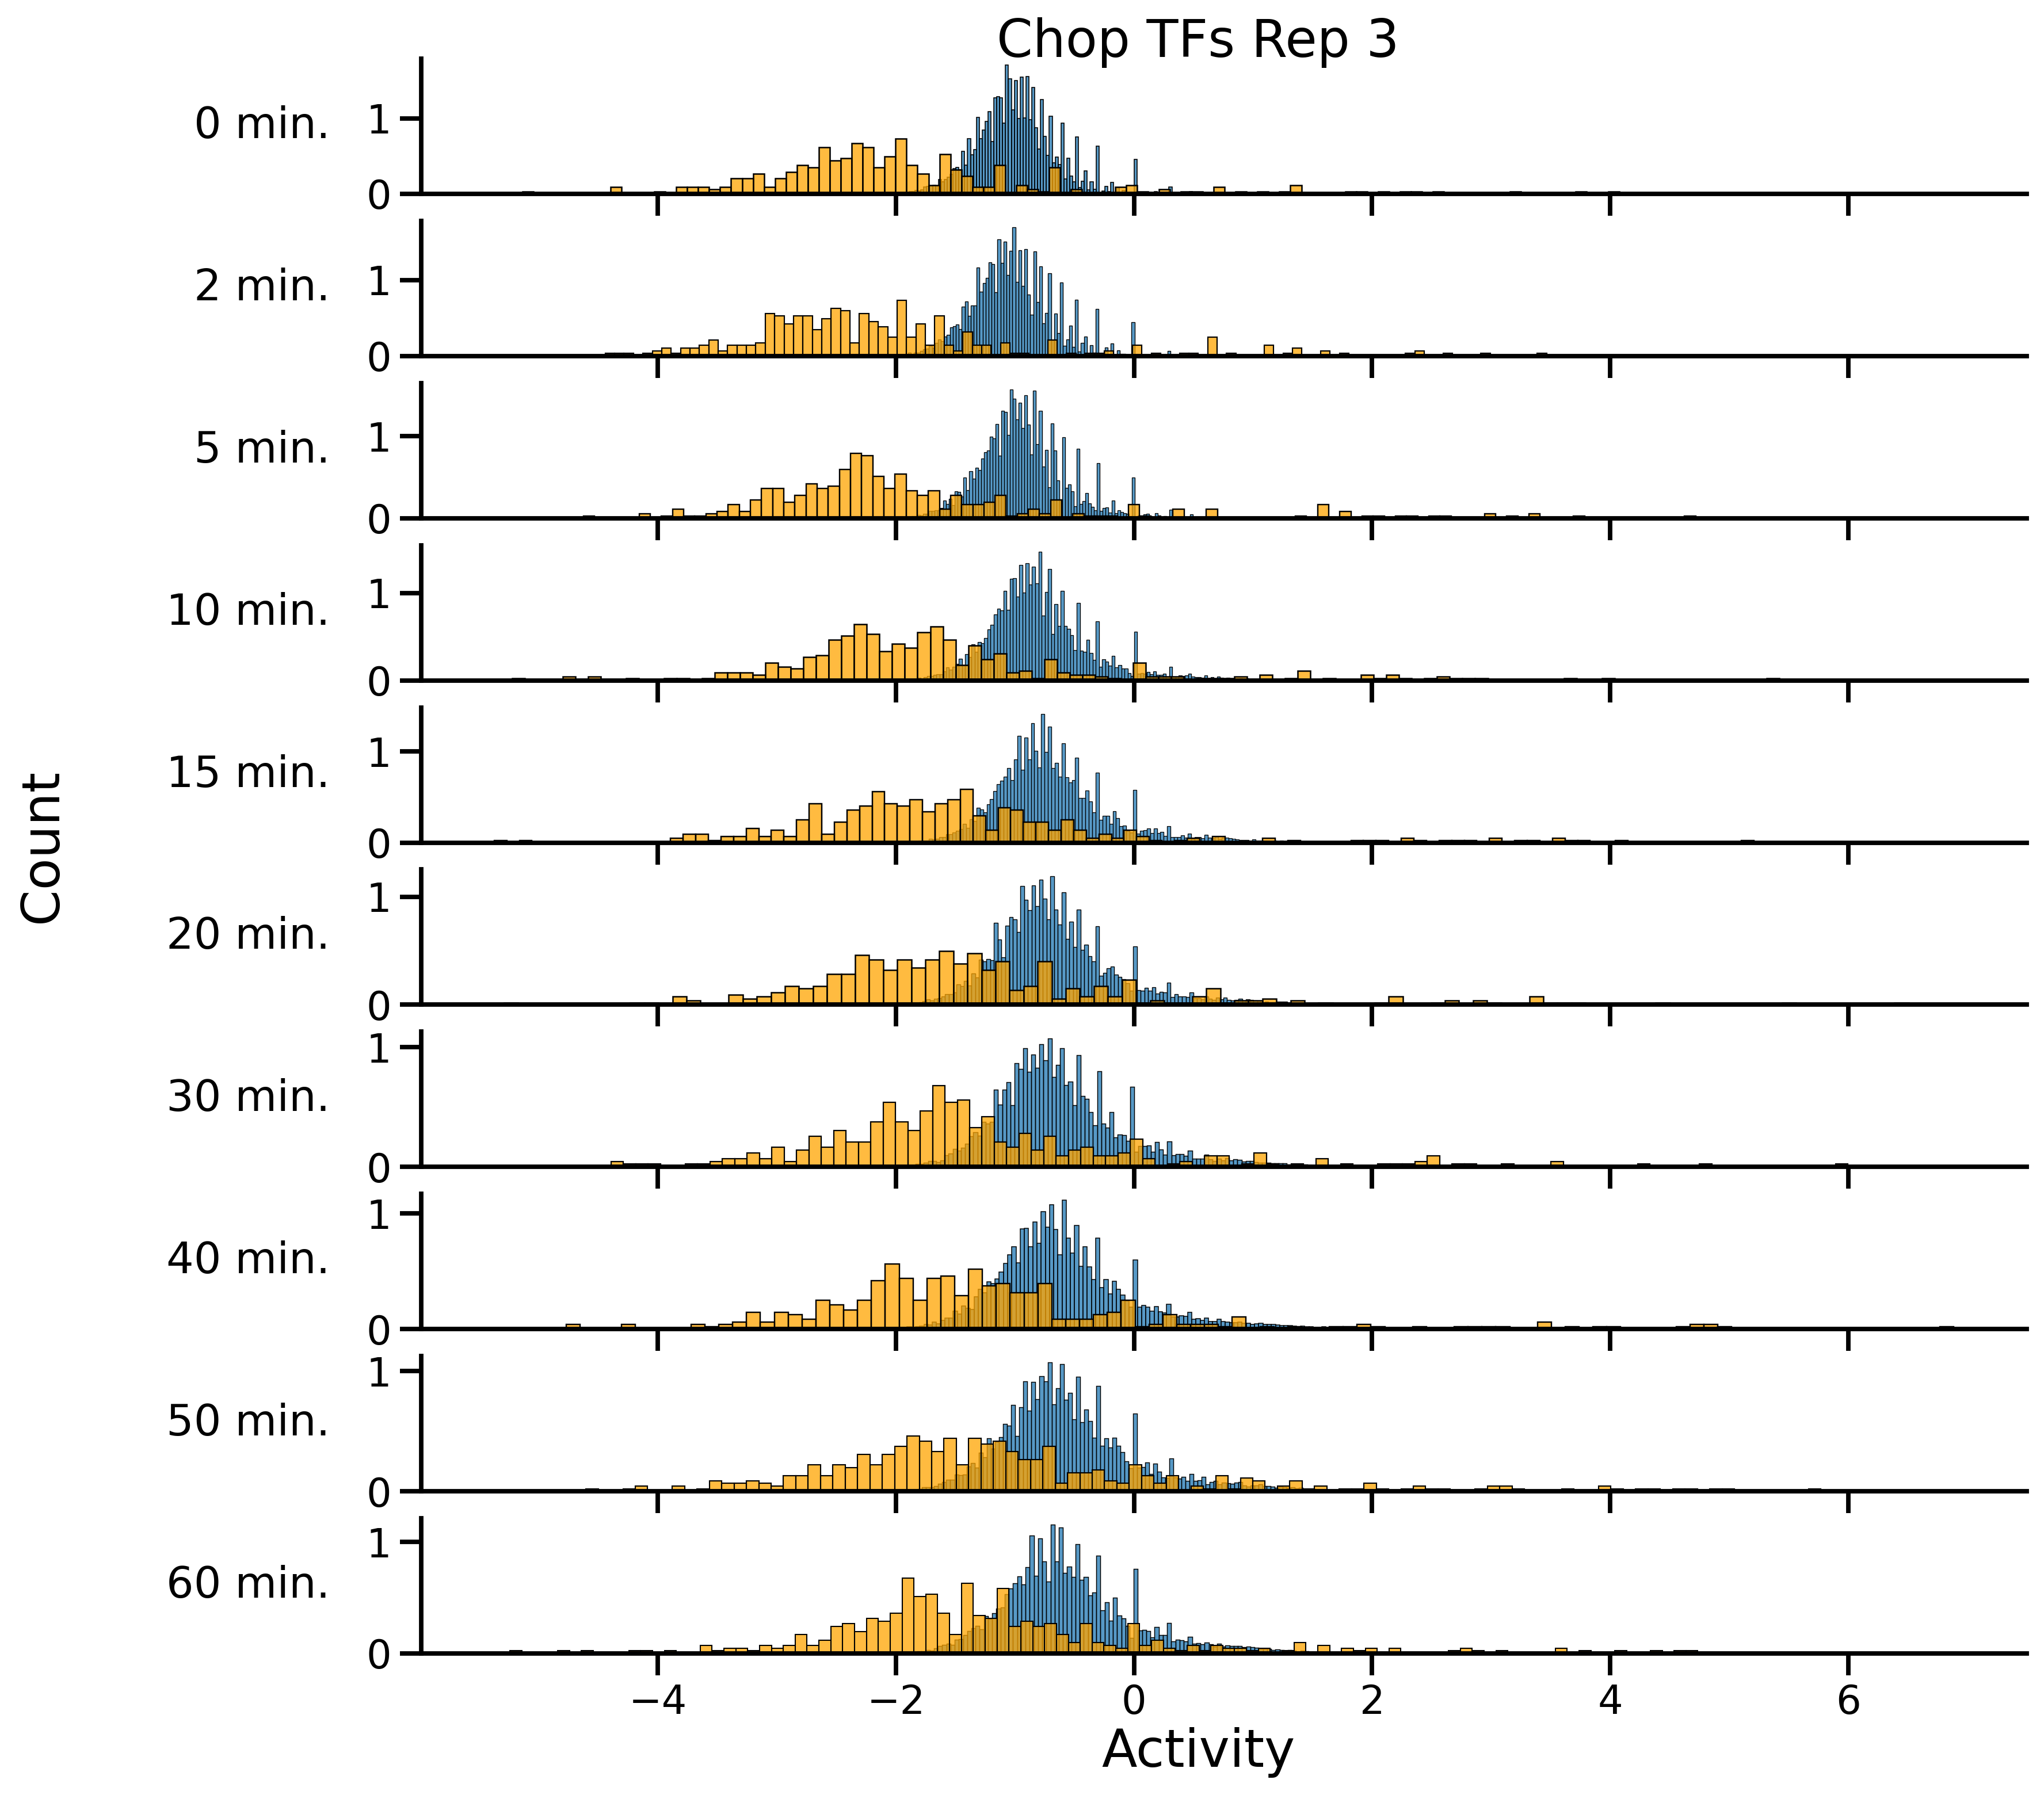

In [19]:
fig,axs = plot_hists_over_time(activities_rep3)

times = np.array(empty_AD_trebl_results["time"].drop_duplicates().sort_values())
    
for i in tqdm.tqdm(range(len(times))):
    sns.histplot(data = empty_AD_trebl_results[(empty_AD_trebl_results["rep"] == 3) & (empty_AD_trebl_results["time"] == times[i])], 
                 x = "activity", 
                 ax = axs[i],
                stat = 'density', color = 'orange', bins = 100, label = "Empty ADs")
    axs[i].set_xlabel("")
    
fig.suptitle("Chop TFs Rep 3", y = 0.9)

100%|██████████| 10/10 [00:00<00:00, 11.60it/s]


Text(0.5, 0.9, 'Chop TFs Rep 4')

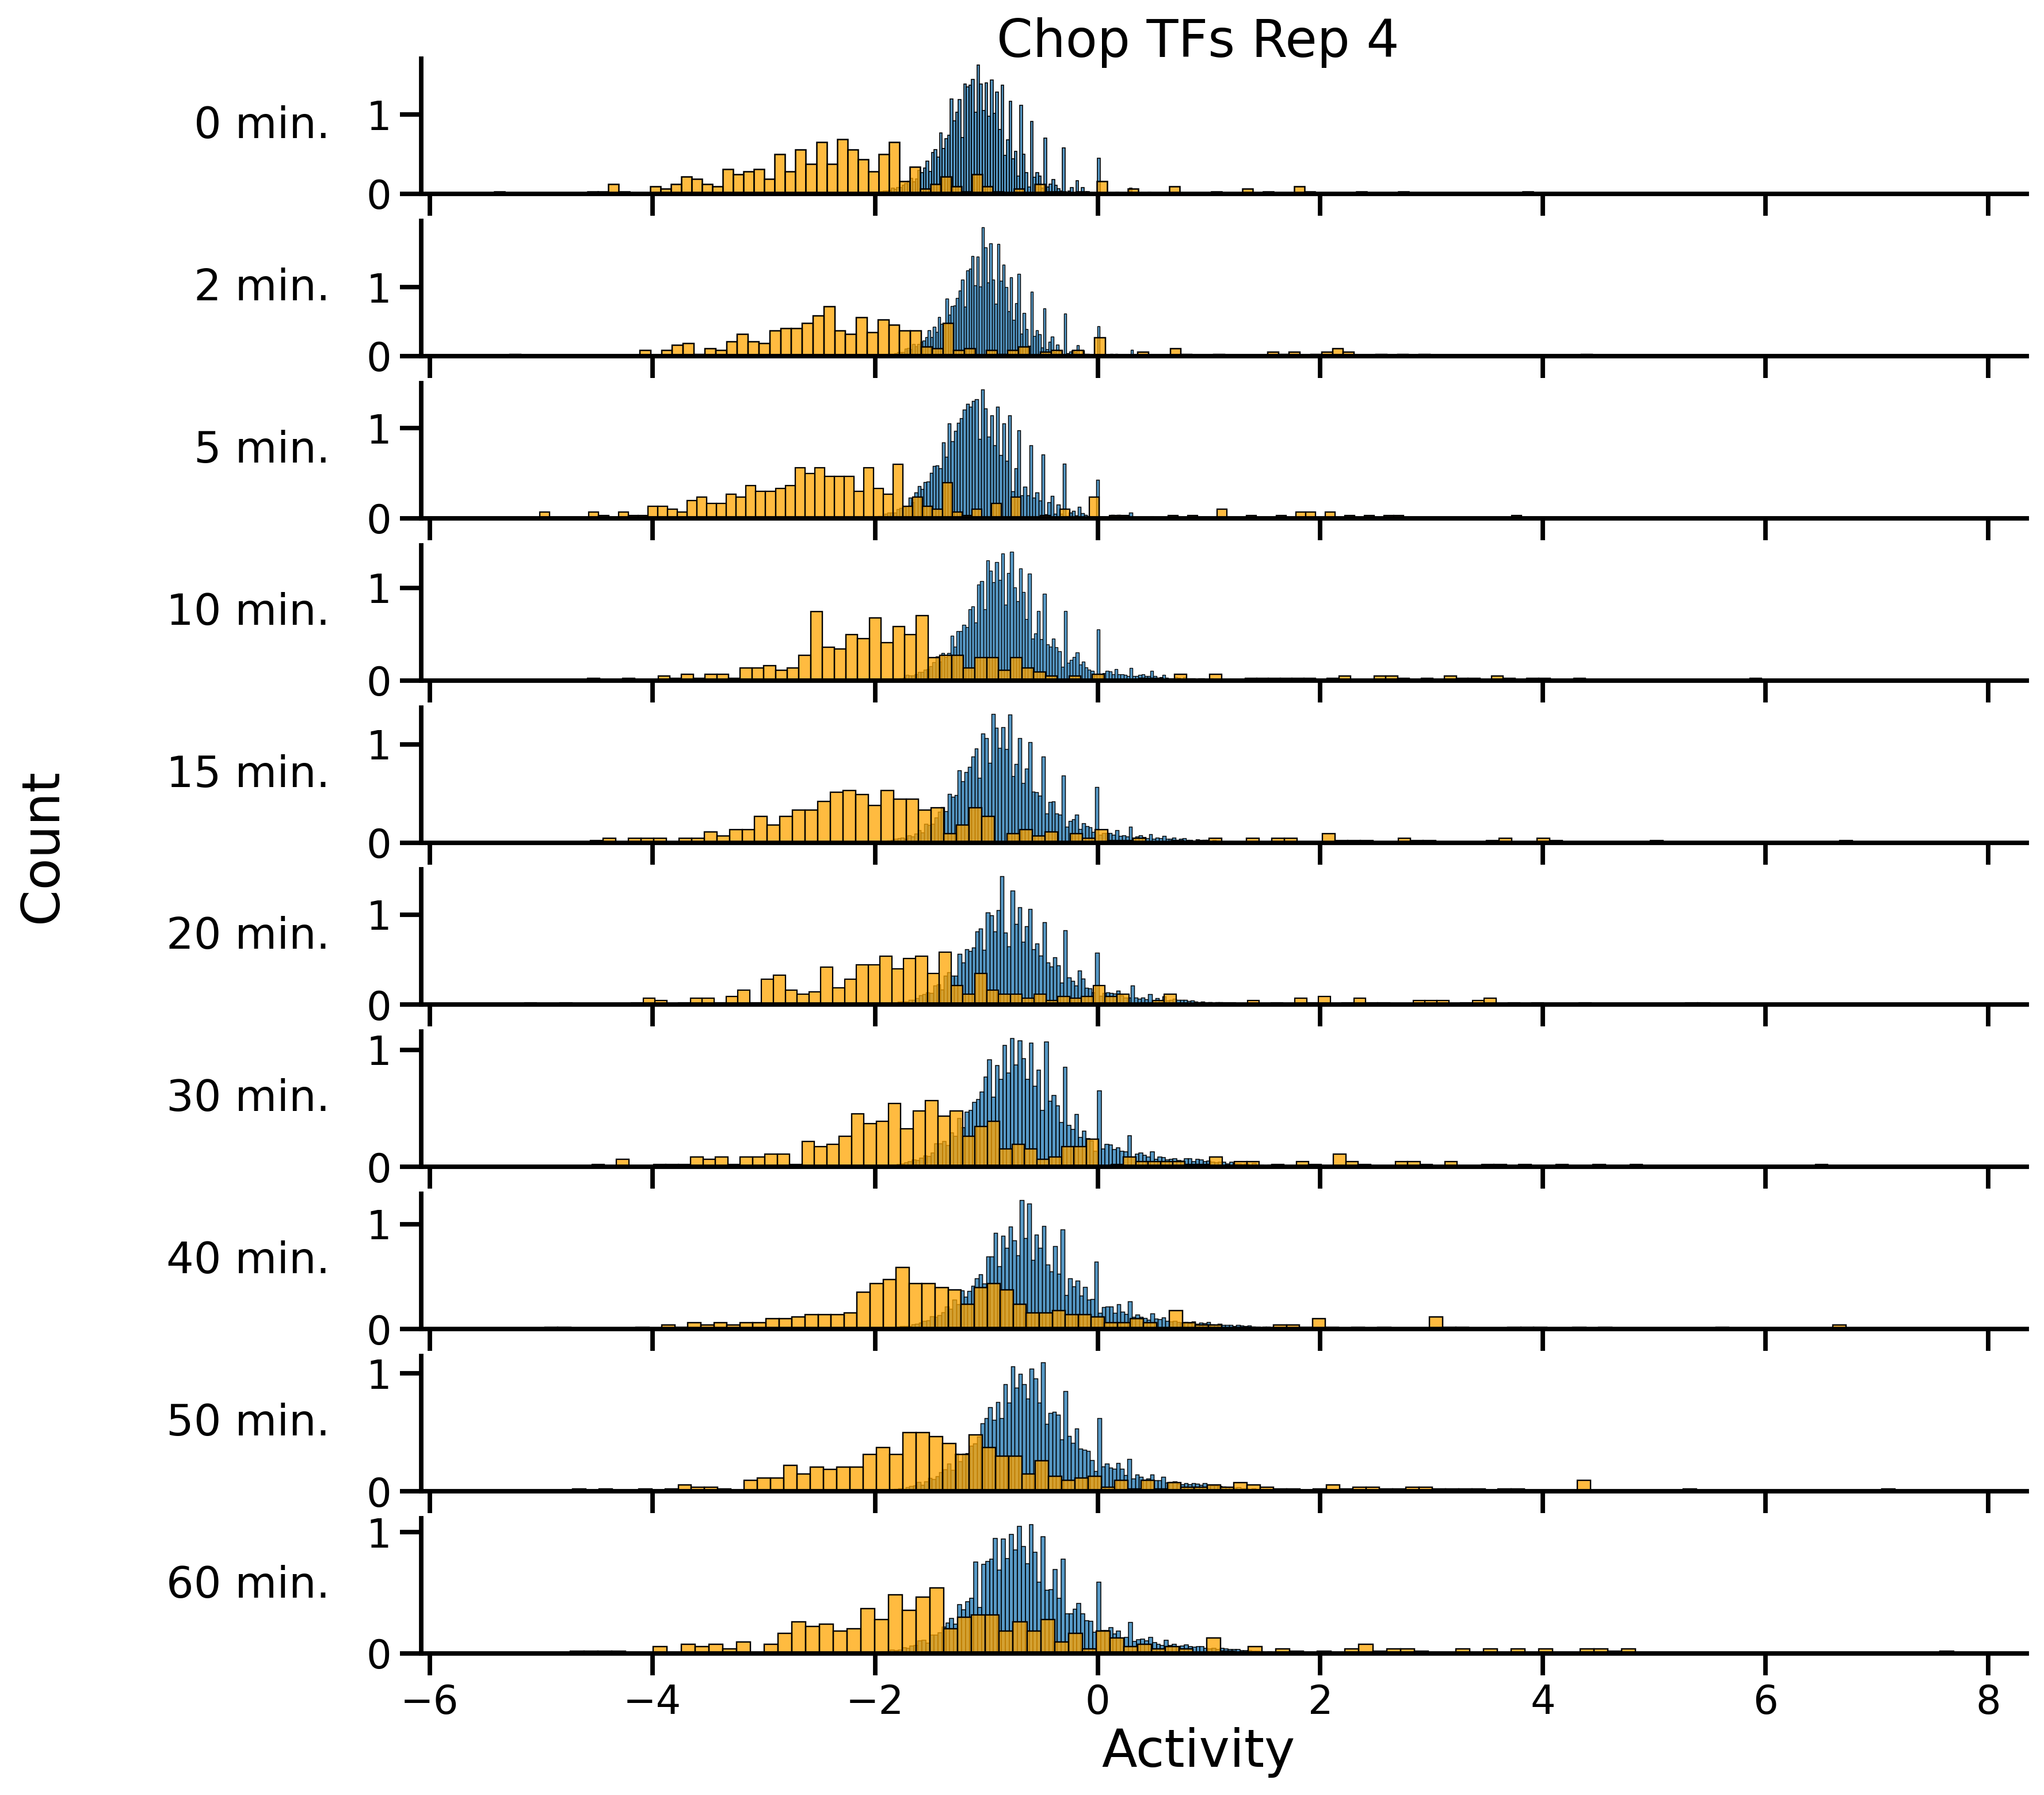

In [20]:
fig,axs = plot_hists_over_time(activities_rep4)

times = np.array(empty_AD_trebl_results["time"].drop_duplicates().sort_values())
    
for i in tqdm.tqdm(range(len(times))):
    sns.histplot(data = empty_AD_trebl_results[(empty_AD_trebl_results["rep"] == 4) & (empty_AD_trebl_results["time"] == times[i])], 
                 x = "activity", 
                 ax = axs[i],
                stat = 'density', color = 'orange', bins = 100, label = "Empty ADs")
    axs[i].set_xlabel("")
    
fig.suptitle("Chop TFs Rep 4", y = 0.9)